# Smart-Kage Circadian Metrics and Bout Structure Analysis

This notebook combines the movement-analysis CSV outputs across all 5 cohorts and plots:

- Circadian metrics
- Active bout statistics
- Quiescent bout statistics
- Individual bout structure
- Optional daily bout structure

All figures are separated by **age cohort** and **genotype**.

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Plotting style
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "ytick.left": True,
    "ytick.direction": "in",
    "xtick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

def format_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in", width=1.2, length=4)
    return ax

def sem(x):
    x = pd.Series(x).dropna()
    if len(x) <= 1:
        return np.nan
    return x.sem()

# THESIS FIGURE STYLE — sized to remain readable after multi-panel assembly
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})



## 2. Paths, cohort information, and constants

Update `ROOT_BASE` if your drive path is different.

In [2]:
ROOT_BASE = Path("/Volumes/Aimi_SmrtKg")

COHORTS = {
    "2024-05-may-jul_NLGF6m": "6m",
    "2026-01-Jan-Mar_NLGF6m_Coh2": "6m",
    "2024-07-jul-sep_NLGF12m": "12m",
    "2025-04-Apr-May_NLGF24m_Coh1": "24m",
    "2025-05-May-June_NLGF24m-Coh2": "24m",
}

AGE_ORDER = ["6m", "12m", "24m"]
GENO_ORDER = ["WT", "NLGF"]

GENO_COLORS = {
    "WT": "#34C6D3",          # teal
    "NLGF": "#F062B8",        # pink
    "APP1-em1BDS": "#FF8C00", # orange
    "NLF": "#9B5DE5",         # purple
}

FIG_W = 6
FIG_H = 5
WIDE_W = 18
WIDE_H = 5

MASTER_OUTPUT = ROOT_BASE / "MOVEMENT_MASTER"
FIG_OUTPUT = MASTER_OUTPUT / "figures"
MASTER_OUTPUT.mkdir(exist_ok=True)
FIG_OUTPUT.mkdir(exist_ok=True)

## 3. Helper functions

These functions standardise column names, add cohort metadata, and plot one metric at a time.

In [3]:
def clean_genotype(x):
    """Standardise genotype labels."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()

    replacements = {
        "APP1-em1BDeS": "APP1-em1BDS",
        "APP1-em1BDS": "APP1-em1BDS",
        "APP": "APP1-em1BDS",
        "LM": "APP1-em1BDS",
        "WT": "WT",
        "wt": "WT",
        "NLGF": "NLGF",
        "nlgf": "NLGF",
        "Unknown": "APP1-em1BDS",
    }
    return replacements.get(x, x)


def standardise_id_columns(df):
    """Rename individual/kage/genotype columns into a consistent format."""
    df = df.copy()

    rename_map = {
        "individual": "KageID",
        "individuals": "KageID",
        "kage": "KageID",
        "Kage": "KageID",
        "genotype": "Genotype",
        "geno": "Genotype",
    }

    existing_rename = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=existing_rename)

    if "KageID" in df.columns:
        df["KageID"] = df["KageID"].astype(str)

    if "Genotype" in df.columns:
        df["Genotype"] = df["Genotype"].apply(clean_genotype)

    return df


def add_metadata(df, cohort_name, age):
    df = df.copy()
    df["Cohort"] = cohort_name
    df["Age"] = age

    if "KageID" in df.columns:
        df["MouseSessionID"] = df["Cohort"].astype(str) + "_" + df["KageID"].astype(str)

    return df


def load_cohort_csv(filename):
    """Load the same movement-analysis CSV from all cohorts."""
    all_frames = []

    for cohort_name, age in COHORTS.items():
        csv_path = ROOT_BASE / cohort_name / "movement_analysis" / "bodycenter_best_week" / filename

        if not csv_path.exists():
            print(f"Missing: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        df = standardise_id_columns(df)
        df = add_metadata(df, cohort_name, age)
        df["SourceFile"] = str(csv_path)
        all_frames.append(df)

        print(f"Loaded {filename}: {cohort_name} | rows={len(df)}")

    if not all_frames:
        raise FileNotFoundError(f"No files found for {filename}")

    master = pd.concat(all_frames, ignore_index=True)
    return master


def make_numeric(df, exclude_cols=None):
    """Convert all non-ID columns to numeric where possible."""
    df = df.copy()
    if exclude_cols is None:
        exclude_cols = ["KageID", "Genotype", "Cohort", "Age", "MouseSessionID", "SourceFile", "bout_type", "day"]

    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors="ignore")
    return df

## 4. Load master movement tables

This section loads all 5 cohorts into master tables.

In [4]:
circadian_master = load_cohort_csv("circadian_metrics.csv")
active_master = load_cohort_csv("bout_stats_active.csv")
quiescent_master = load_cohort_csv("bout_stats_quiescent.csv")
individual_bouts_master = load_cohort_csv("bout_stats_individual.csv")

# Daily CSV may not contain genotype in some outputs, so load it separately and merge genotype back in.
daily_master = load_cohort_csv("bout_stats_daily.csv")

# If daily_master has no Genotype column, merge genotype from individual_bouts_master.
if "Genotype" not in daily_master.columns:
    geno_lookup = individual_bouts_master[["MouseSessionID", "Genotype"]].drop_duplicates()
    daily_master = daily_master.merge(geno_lookup, on="MouseSessionID", how="left")

# Make numeric columns numeric where possible
circadian_master = make_numeric(circadian_master)
active_master = make_numeric(active_master)
quiescent_master = make_numeric(quiescent_master)
individual_bouts_master = make_numeric(individual_bouts_master)
daily_master = make_numeric(daily_master)

print("\nCircadian columns:", circadian_master.columns.tolist())
print("Active columns:", active_master.columns.tolist())
print("Quiescent columns:", quiescent_master.columns.tolist())
print("Individual bout columns:", individual_bouts_master.columns.tolist())
print("Daily bout columns:", daily_master.columns.tolist())

Loaded circadian_metrics.csv: 2024-05-may-jul_NLGF6m | rows=31
Loaded circadian_metrics.csv: 2026-01-Jan-Mar_NLGF6m_Coh2 | rows=12
Loaded circadian_metrics.csv: 2024-07-jul-sep_NLGF12m | rows=29
Loaded circadian_metrics.csv: 2025-04-Apr-May_NLGF24m_Coh1 | rows=25
Loaded circadian_metrics.csv: 2025-05-May-June_NLGF24m-Coh2 | rows=18
Loaded bout_stats_active.csv: 2024-05-may-jul_NLGF6m | rows=31
Loaded bout_stats_active.csv: 2026-01-Jan-Mar_NLGF6m_Coh2 | rows=12
Loaded bout_stats_active.csv: 2024-07-jul-sep_NLGF12m | rows=29
Loaded bout_stats_active.csv: 2025-04-Apr-May_NLGF24m_Coh1 | rows=25
Loaded bout_stats_active.csv: 2025-05-May-June_NLGF24m-Coh2 | rows=18
Loaded bout_stats_quiescent.csv: 2024-05-may-jul_NLGF6m | rows=31
Loaded bout_stats_quiescent.csv: 2026-01-Jan-Mar_NLGF6m_Coh2 | rows=12
Loaded bout_stats_quiescent.csv: 2024-07-jul-sep_NLGF12m | rows=29
Loaded bout_stats_quiescent.csv: 2025-04-Apr-May_NLGF24m_Coh1 | rows=25
Loaded bout_stats_quiescent.csv: 2025-05-May-June_NLGF24

/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_68001/718707110.py:91: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


## 5. Save master CSVs

In [5]:
circadian_master.to_csv(MASTER_OUTPUT / "movement_master_circadian_metrics.csv", index=False)
active_master.to_csv(MASTER_OUTPUT / "movement_master_bout_stats_active.csv", index=False)
quiescent_master.to_csv(MASTER_OUTPUT / "movement_master_bout_stats_quiescent.csv", index=False)
individual_bouts_master.to_csv(MASTER_OUTPUT / "movement_master_bout_stats_individual.csv", index=False)
daily_master.to_csv(MASTER_OUTPUT / "movement_master_bout_stats_daily.csv", index=False)

print("Saved master CSVs to:", MASTER_OUTPUT)

Saved master CSVs to: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER


## 6. Generic dot-plot function

Each figure is split into three panels:

- 6 months
- 12 months
- 24 months

Within each age, genotypes are compared using individual mouse points plus mean ± 95% CI.

In [6]:

# ---------------------------------------------------------------------
# Statistics helpers
# ---------------------------------------------------------------------

STATS_RESULTS = []


def p_to_stars(p):
    """Convert p-value to GraphPad-style stars."""
    if pd.isna(p):
        return ""
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def holm_correction(pvals):
    """Holm correction for a list/array of p-values."""
    pvals = np.asarray(pvals, dtype=float)
    adjusted = np.full_like(pvals, np.nan, dtype=float)

    valid = ~np.isnan(pvals)
    if valid.sum() == 0:
        return adjusted

    valid_idx = np.where(valid)[0]
    p_valid = pvals[valid]

    order = np.argsort(p_valid)
    sorted_p = p_valid[order]
    m = len(sorted_p)

    sorted_adj = np.empty(m, dtype=float)

    running_max = 0
    for i, p in enumerate(sorted_p):
        adj = (m - i) * p
        running_max = max(running_max, adj)
        sorted_adj[i] = min(running_max, 1.0)

    adjusted_valid = np.empty(m, dtype=float)
    adjusted_valid[order] = sorted_adj
    adjusted[valid_idx] = adjusted_valid

    return adjusted


def pairwise_genotype_stats(data, metric, metric_label=None):
    """RAW unadjusted WT-vs-NLGF comparison within each age."""
    df=data.copy()
    df[metric]=pd.to_numeric(df[metric],errors="coerce")
    df=df.dropna(subset=[metric,"Age","Genotype"])
    df=df[df["Genotype"].isin(GENO_ORDER)].copy()
    rows=[]
    for age in AGE_ORDER:
        sub=df[df["Age"]==age]
        x=sub[sub["Genotype"]=="WT"][metric].dropna()
        y=sub[sub["Genotype"]=="NLGF"][metric].dropna()
        if len(x)>=2 and len(y)>=2:
            px=stats.shapiro(x).pvalue if len(x)>=3 else 0
            py=stats.shapiro(y).pvalue if len(y)>=3 else 0
            if px>0.05 and py>0.05:
                res=stats.ttest_ind(x,y,equal_var=False,nan_policy="omit")
                test_name="Welch t-test"
            else:
                res=stats.mannwhitneyu(x,y,alternative="two-sided")
                test_name="Mann-Whitney U"
            p_raw=res.pvalue; statistic=res.statistic
        else:
            p_raw=np.nan; statistic=np.nan; test_name="Not tested"
        rows.append({
            "Metric": metric_label if metric_label is not None else metric,
            "Age":age,"Group 1":"WT","Group 2":"NLGF",
            "n1":len(x),"n2":len(y),"mean1":x.mean() if len(x) else np.nan,
            "mean2":y.mean() if len(y) else np.nan,"statistic":statistic,
            "p_raw":p_raw,"p_holm":p_raw,  # compatibility only: this is RAW p
            "stars":p_to_stars(p_raw),"test":test_name,
        })
    return pd.DataFrame(rows)


def add_sig_bars(ax, stats_df, age, y_values, only_significant=True):
    """Add significance bars to an age-specific genotype plot."""
    if stats_df is None or stats_df.empty:
        return

    sub_stats = stats_df[stats_df["Age"] == age].copy()

    if only_significant:
        sub_stats = sub_stats[sub_stats["p_holm"] < 0.05].copy()

    if sub_stats.empty:
        return

    y_values = pd.to_numeric(pd.Series(y_values), errors="coerce").dropna()

    if len(y_values) == 0:
        return

    ymin = float(y_values.min())
    ymax = float(y_values.max())
    yrange = ymax - ymin

    if yrange == 0:
        yrange = abs(ymax) if ymax != 0 else 1

    current_y = ymax + yrange * 0.15
    step = yrange * 0.13

    for _, row in sub_stats.iterrows():

        g1 = row["Group 1"]
        g2 = row["Group 2"]

        if g1 not in GENO_ORDER or g2 not in GENO_ORDER:
            continue

        x1 = GENO_ORDER.index(g1)
        x2 = GENO_ORDER.index(g2)

        if x1 == x2:
            continue

        star = row["stars"]

        if star == "" or (only_significant and star == "ns"):
            continue

        h = step * 0.25

        ax.plot(
            [x1, x1, x2, x2],
            [current_y, current_y + h, current_y + h, current_y],
            color="black",
            linewidth=1.2,
            clip_on=False,
        )

        ax.text(
            (x1 + x2) / 2,
            current_y + h,
            star,
            ha="center",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            color="black",
            clip_on=False,
        )

        current_y += step

    # Extend y-axis so stars are visible
    low, high = ax.get_ylim()
    ax.set_ylim(low, max(high, current_y + step * 0.4))


def plot_metric_by_age(
    data,
    metric,
    ylabel=None,
    title=None,
    save_name=None,
    y_lim=None,
    show_points=True,
    ci_multiplier=1.96,
    add_stats=True,
    only_significant=True,
    show_stats_table=True,
):
    """
    Plot one metric as individual dots with mean ± 95% CI for each age and genotype.

    Statistics:
    - Pairwise Welch t-tests are run between genotypes within each age.
    - Raw p-values are used without multiple-comparison adjustment.
    - Significant comparisons are added to the figure as stars.
    - Full stats table is displayed below the figure.
    """
    df = data.copy()

    if metric not in df.columns:
        print(f"Metric '{metric}' not found. Available columns:")
        print(df.columns.tolist())
        return None

    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric, "Age", "Genotype"])
    df = df[df["Genotype"].isin(GENO_ORDER)].copy()

    if ylabel is None:
        ylabel = metric
    if title is None:
        title = metric

    stats_df = None
    if add_stats:
        stats_df = pairwise_genotype_stats(
            df,
            metric=metric,
            metric_label=title,
        )

        if stats_df is not None and not stats_df.empty:
            STATS_RESULTS.append(stats_df.copy())

    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(22, 7.5),
        sharey=True
    )

    if len(AGE_ORDER) == 1:
        axes = [axes]

    for ax, age in zip(axes, AGE_ORDER):
        sub = df[df["Age"] == age].copy()

        if show_points:
            sns.stripplot(
                data=sub,
                x="Genotype",
                y=metric,
                order=GENO_ORDER,
                hue="Genotype",
                hue_order=GENO_ORDER,
                palette=GENO_COLORS,
                dodge=False,
                jitter=0.18,
                size=8,
                alpha=0.75,
                legend=False,
                ax=ax,
            )

        # Manual mean ± 95% CI error bars
        summary = (
            sub
            .groupby("Genotype", as_index=False)
            .agg(
                mean_value=(metric, "mean"),
                sem_value=(metric, lambda x: x.sem()),
                n=(metric, "count"),
            )
        )

        for i, genotype in enumerate(GENO_ORDER):
            row = summary[summary["Genotype"] == genotype]
            if row.empty:
                continue

            mean_value = row["mean_value"].iloc[0]
            sem_value = row["sem_value"].iloc[0]
            n = int(row["n"].iloc[0])

            if pd.isna(sem_value):
                ci_value = 0
            else:
                ci_value = ci_multiplier * sem_value

            ax.errorbar(
                i,
                mean_value,
                yerr=ci_value,
                fmt="_",
                markersize=18,
                markeredgewidth=2,
                color=GENO_COLORS.get(genotype, "black"),
                elinewidth=2,
                capsize=8,
                capthick=2,
                zorder=10,
            )

            # Add n label above the mean/CI
            if n > 0:
                ax.text(
                    i,
                    mean_value + ci_value,
                    f"n={n}",
                    ha="center",
                    va="bottom",
                    fontsize=15,
                    color=GENO_COLORS.get(genotype, "black"),
                )

        if add_stats:
            add_sig_bars(
                ax=ax,
                stats_df=stats_df,
                age=age,
                y_values=sub[metric],
                only_significant=only_significant,
            )

        format_axes(ax)
        ax.set_title(age)
        ax.set_xlabel("Genotype")
        ax.tick_params(axis="x", rotation=30)
        ax.set_ylabel(ylabel if age == AGE_ORDER[0] else "")

        if y_lim is not None:
            ax.set_ylim(*y_lim)

    # Legend showing genotype colours and mean ± CI line
    handles = [
        mpl.lines.Line2D(
            [], [],
            color=GENO_COLORS[g],
            marker="o",
            linestyle="None",
            markersize=7,
            label=g,
        )
        for g in GENO_ORDER
    ]
    handles.append(
        mpl.lines.Line2D(
            [], [],
            color="black",
            marker="_",
            linestyle="-",
            markersize=14,
            label="mean ± 95% CI",
        )
    )

    fig.legend(
        handles=handles,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
    )

    fig.suptitle(title, y=1.03)
    plt.tight_layout(rect=[0, 0, 0.92, 1])

    if save_name:
        out_path = FIG_OUTPUT / save_name
        fig.savefig(out_path, dpi=300)
        print("Saved:", out_path)

    plt.show()

    if show_stats_table and stats_df is not None and not stats_df.empty:
        display(
            stats_df[
                [
                    "Metric", "Age", "Group 1", "Group 2",
                    "n1", "n2", "mean1", "mean2",
                    "statistic", "p_raw", "p_holm", "stars", "test"
                ]
            ]
        )

    return stats_df


## 7. Circadian metrics

Metrics:

- `DI`: Diurnality Index
- `IV`: Intraday variability
- `IS`: Interday stability
- `RA`: Relative amplitude
- `M10`: Mean activity during most active 10 hours
- `L5`: Mean activity during least active 5 hours

Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_DI.png


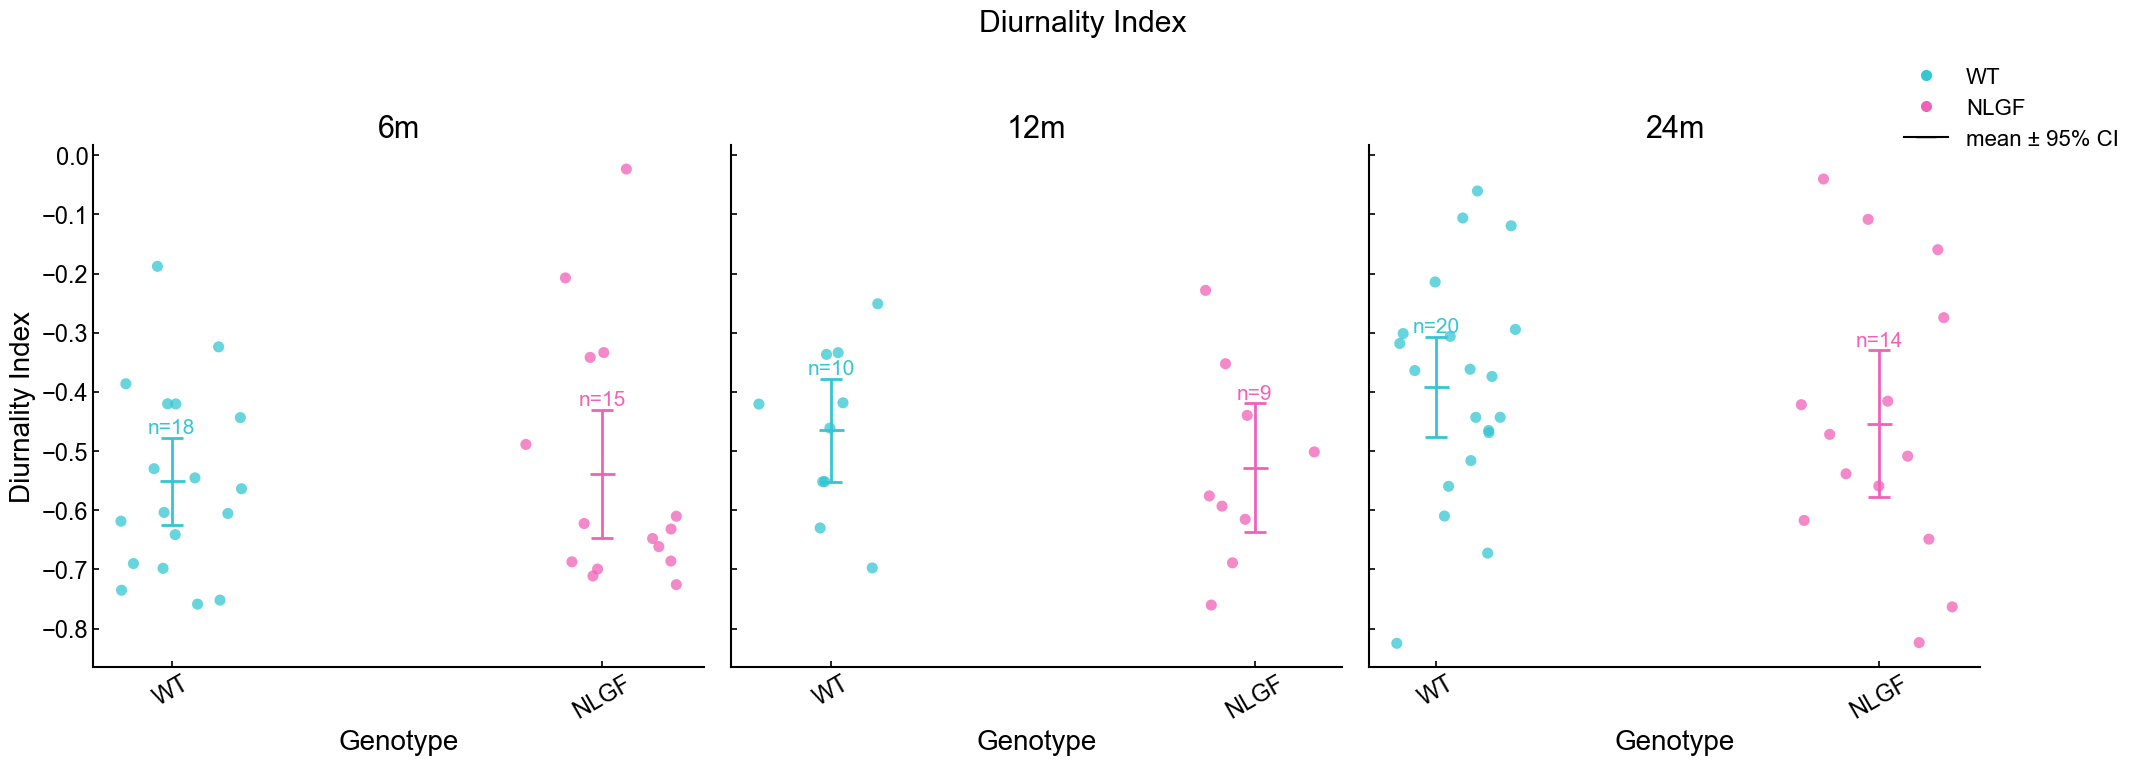

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Diurnality Index,6m,WT,NLGF,18,15,-0.551389,-0.538580,143.000000,0.786266,0.786266,ns,Mann-Whitney U
1,Diurnality Index,12m,WT,NLGF,10,9,-0.465302,-0.528445,0.884341,0.389767,0.389767,ns,Welch t-test
2,Diurnality Index,24m,WT,NLGF,20,14,-0.391192,-0.453689,0.815952,0.422476,0.422476,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_IV.png


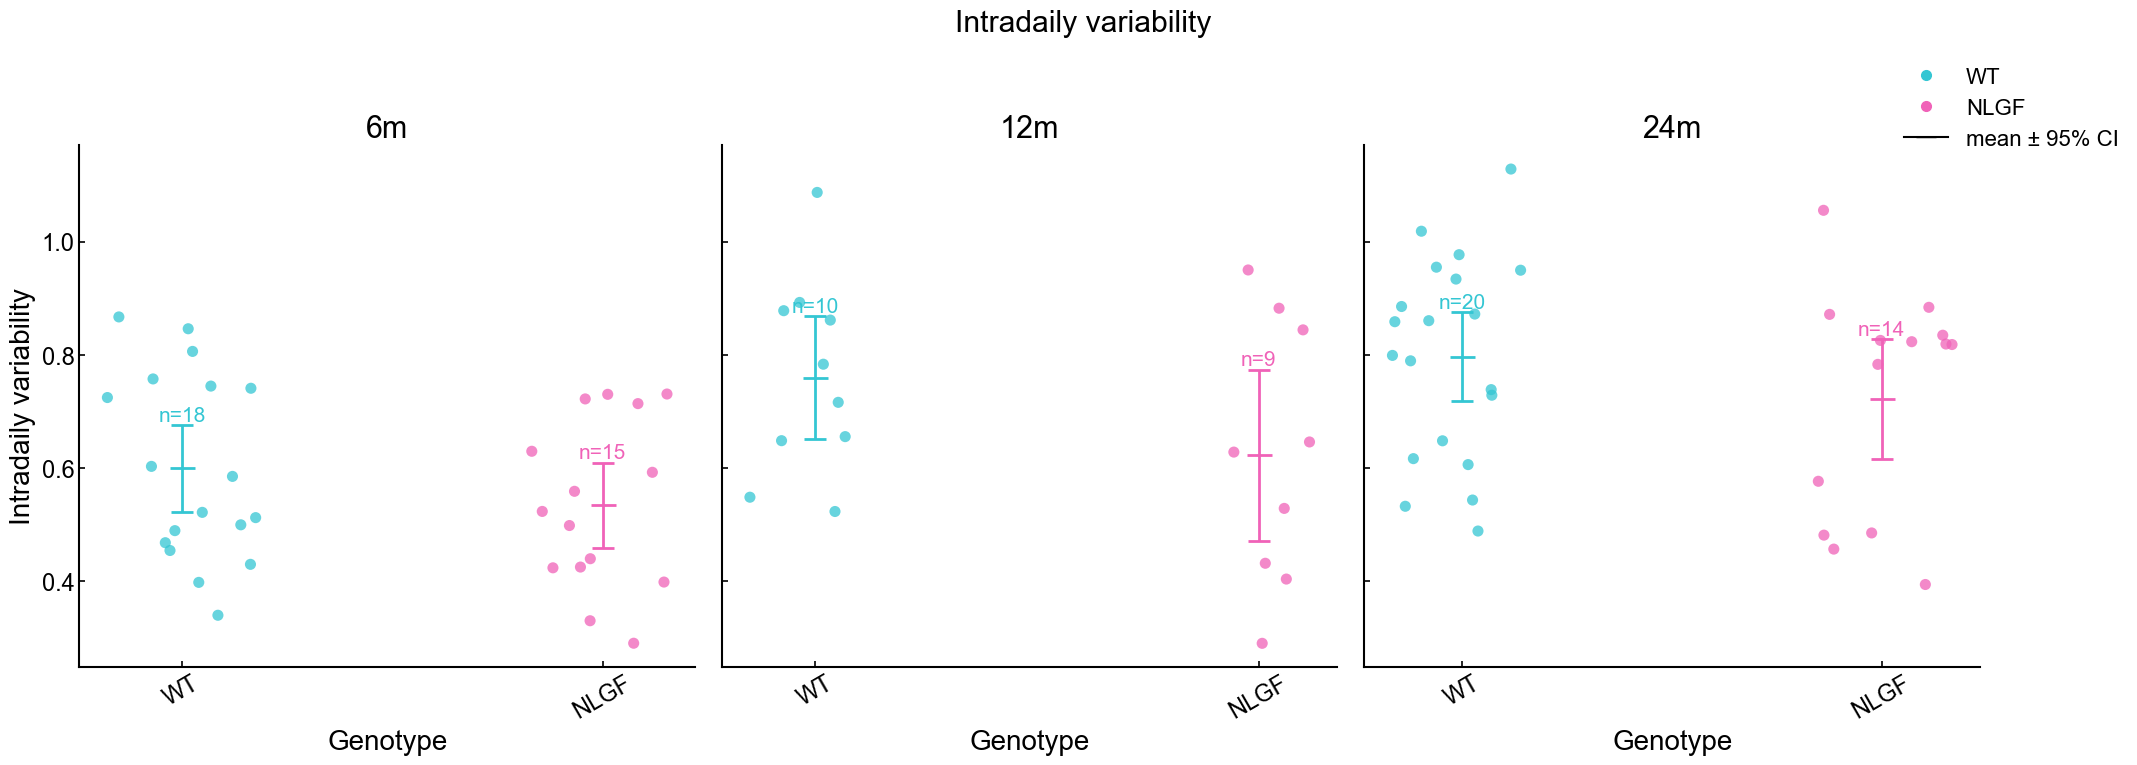

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Intradaily variability,6m,WT,NLGF,18,15,0.599590,0.534048,1.193720,0.241704,0.241704,ns,Welch t-test
1,Intradaily variability,12m,WT,NLGF,10,9,0.759691,0.623052,1.439698,0.170689,0.170689,ns,Welch t-test
2,Intradaily variability,24m,WT,NLGF,20,14,0.796767,0.722353,1.108448,0.277859,0.277859,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_IS.png


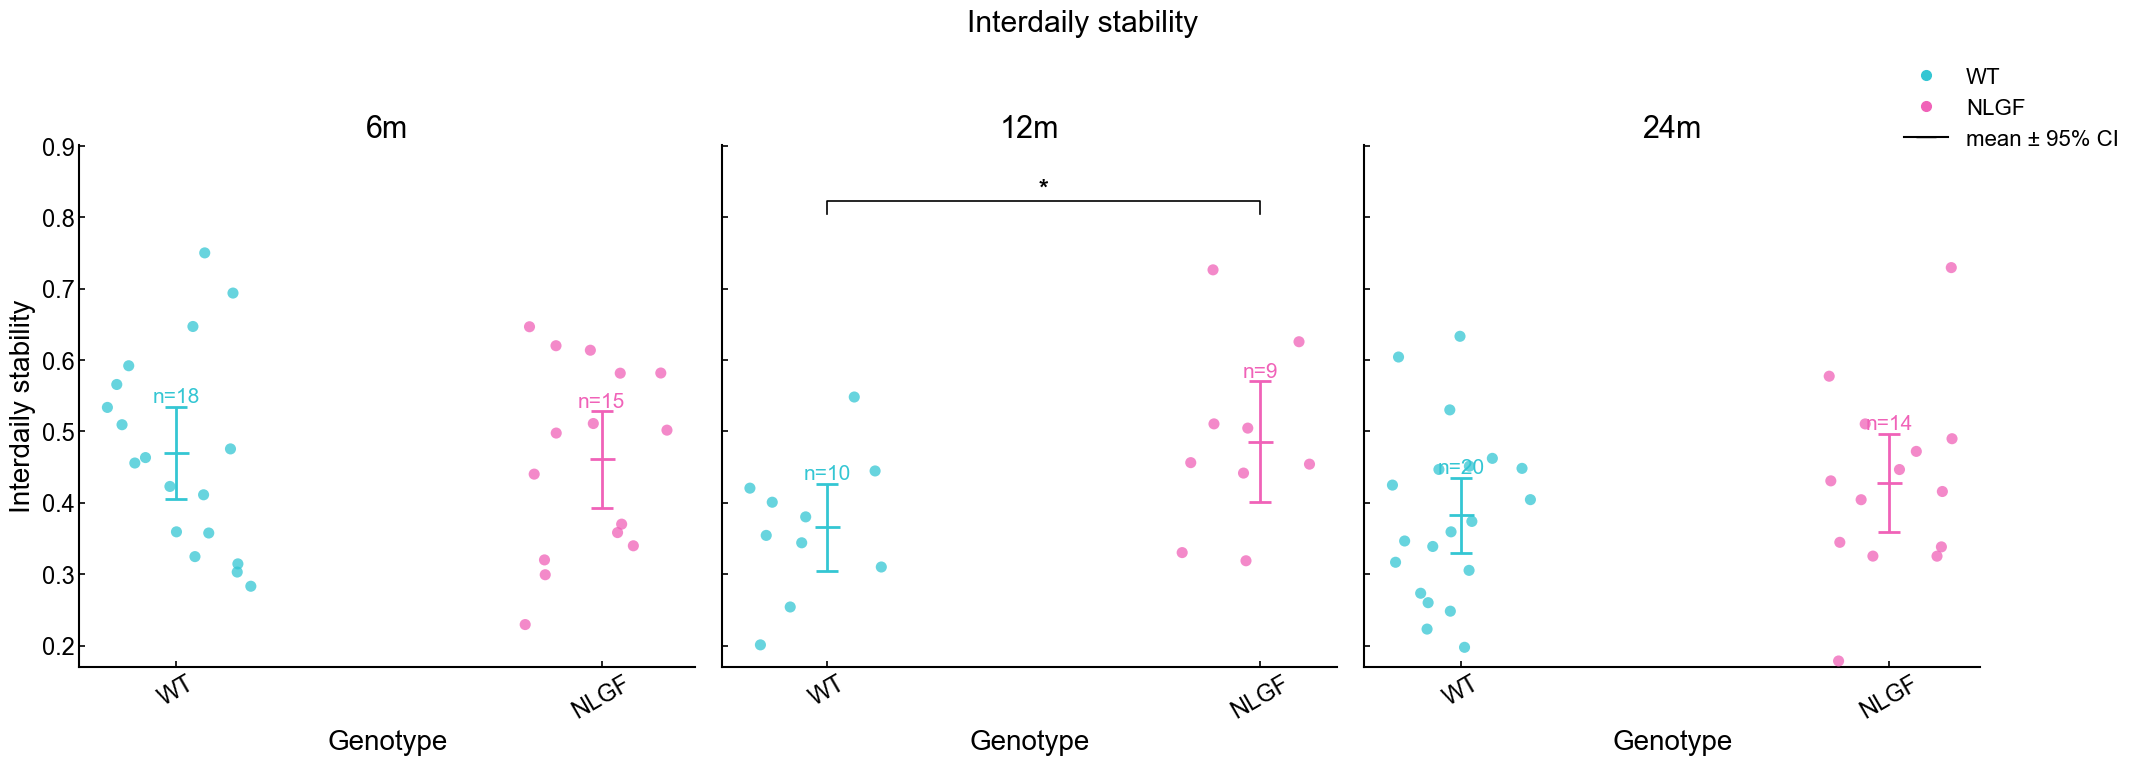

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Interdaily stability,6m,WT,NLGF,18,15,0.470227,0.460838,0.196970,0.845166,0.845166,ns,Welch t-test
1,Interdaily stability,12m,WT,NLGF,10,9,0.365833,0.485450,-2.245827,0.040318,0.040318,*,Welch t-test
2,Interdaily stability,24m,WT,NLGF,20,14,0.382466,0.427815,-1.024145,0.315048,0.315048,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_RA.png


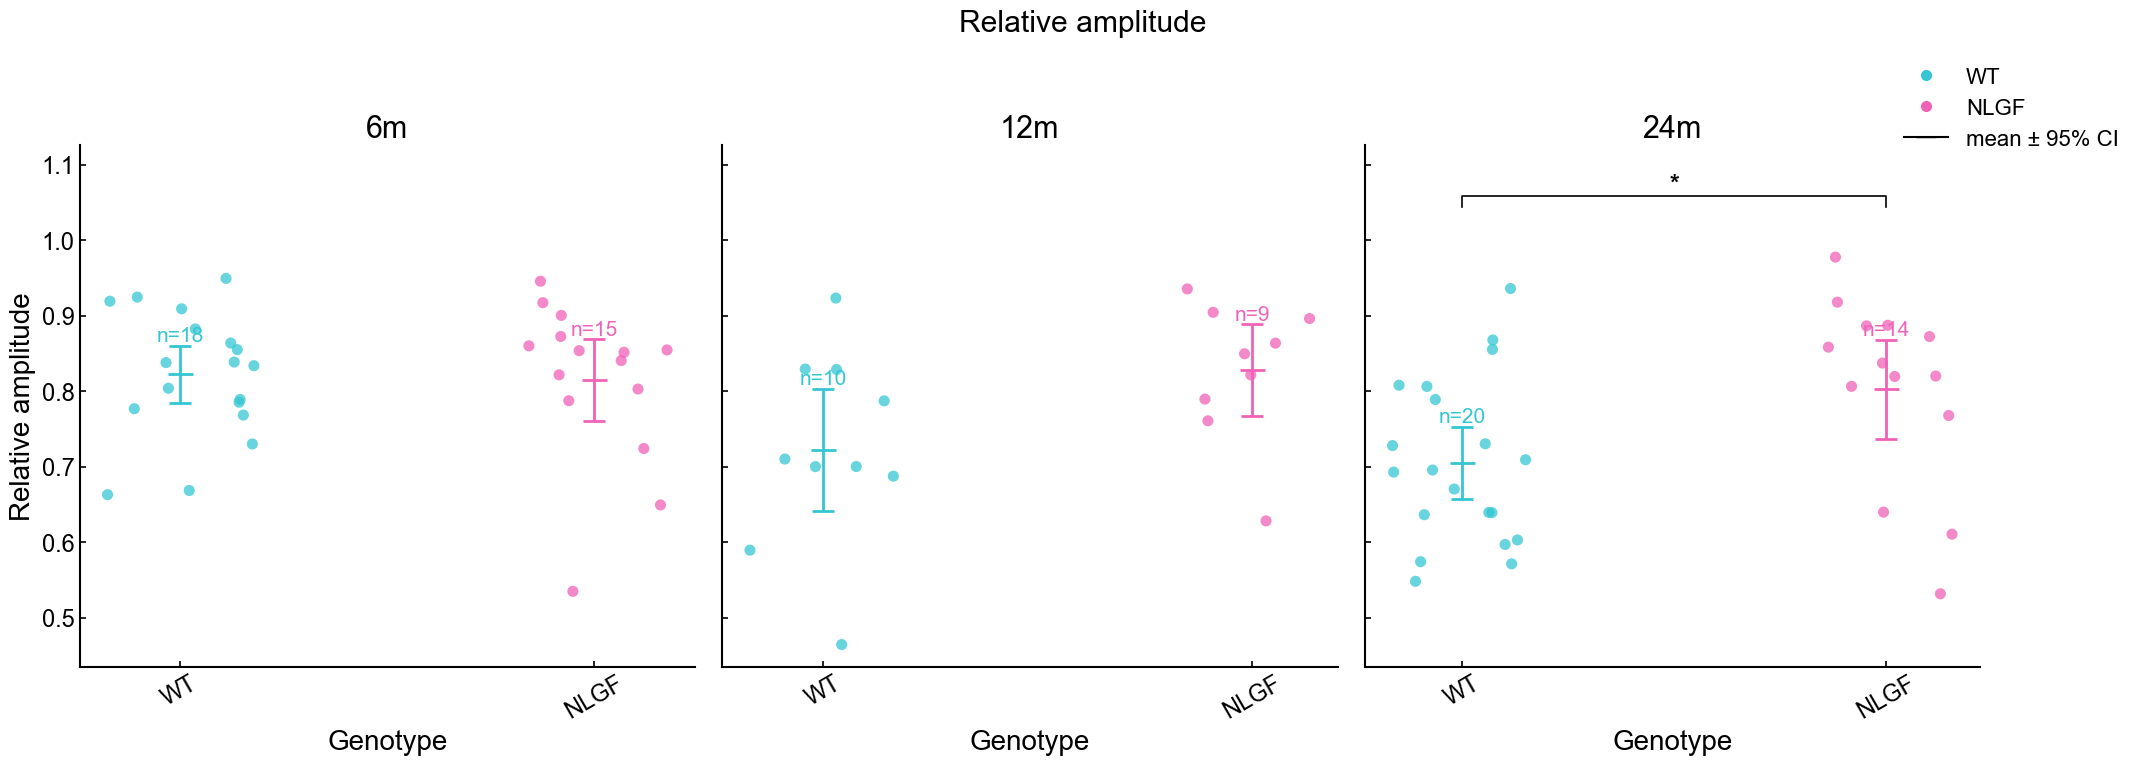

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Relative amplitude,6m,WT,NLGF,18,15,0.822382,0.814651,132.000000,0.927979,0.927979,ns,Mann-Whitney U
1,Relative amplitude,12m,WT,NLGF,10,9,0.722228,0.827956,-2.042281,0.057724,0.057724,ns,Welch t-test
2,Relative amplitude,24m,WT,NLGF,20,14,0.705070,0.802586,-2.343335,0.027187,0.027187,*,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_M10.png


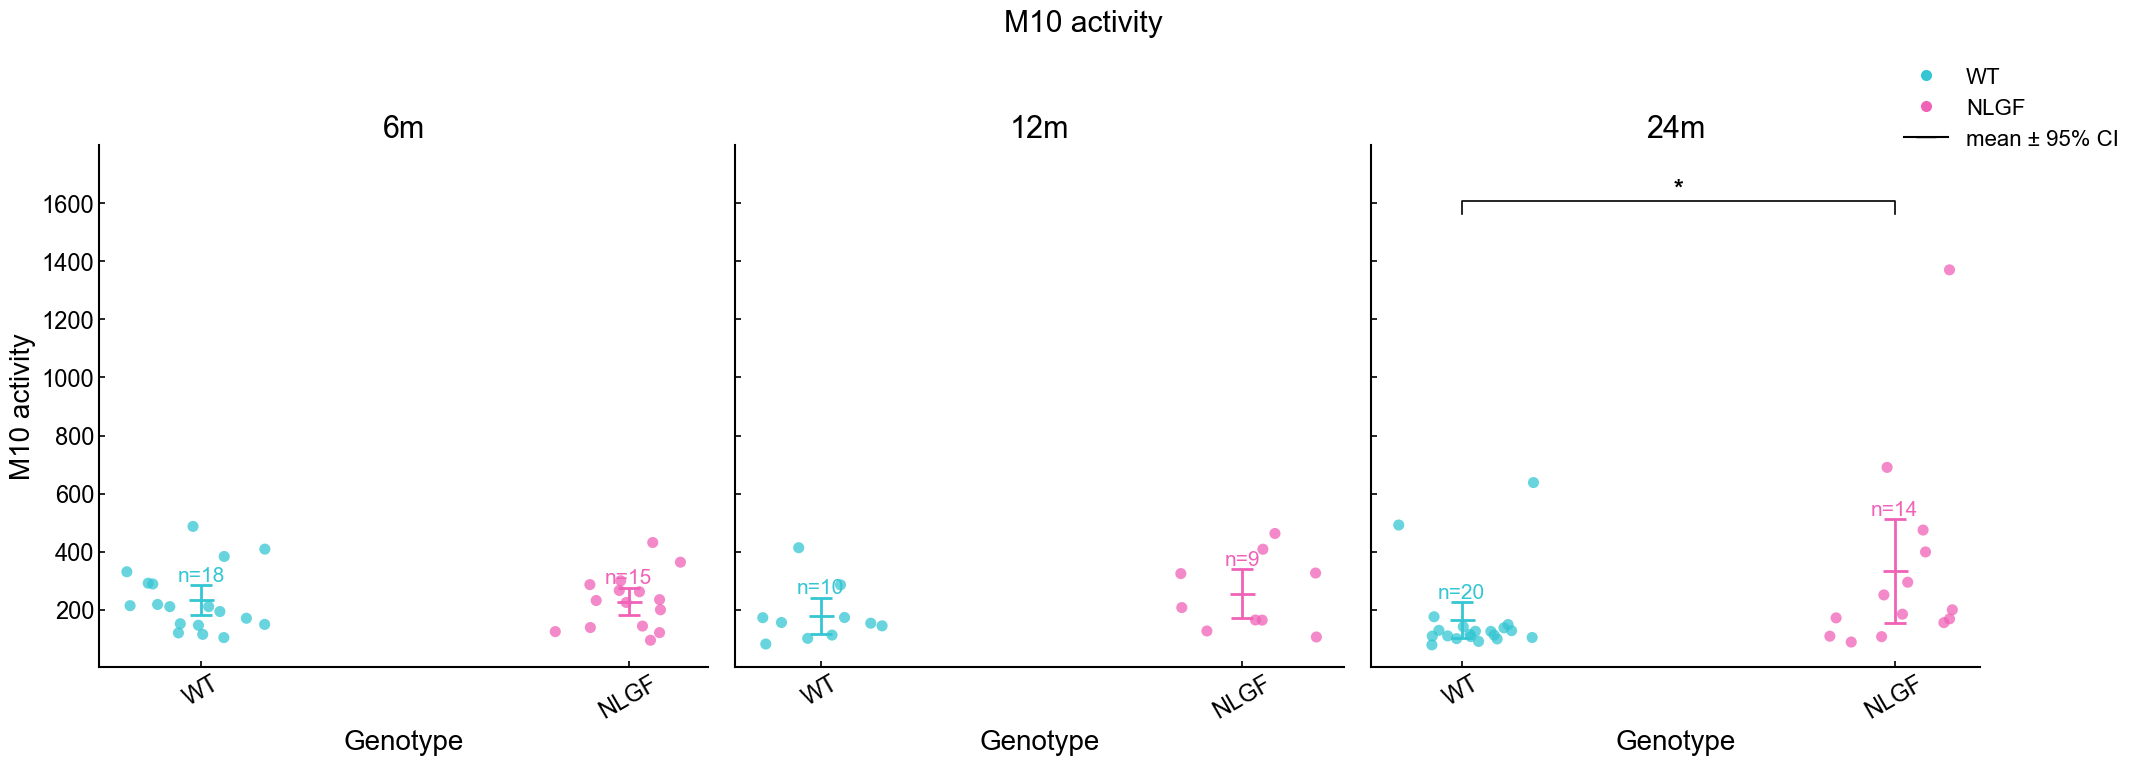

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,M10 activity,6m,WT,NLGF,18,15,233.650066,228.886358,0.133537,0.894634,0.894634,ns,Welch t-test
1,M10 activity,12m,WT,NLGF,10,9,180.162723,255.110385,28.000000,0.177910,0.177910,ns,Mann-Whitney U
2,M10 activity,24m,WT,NLGF,20,14,164.157826,333.723322,69.000000,0.013626,0.013626,*,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_L5.png


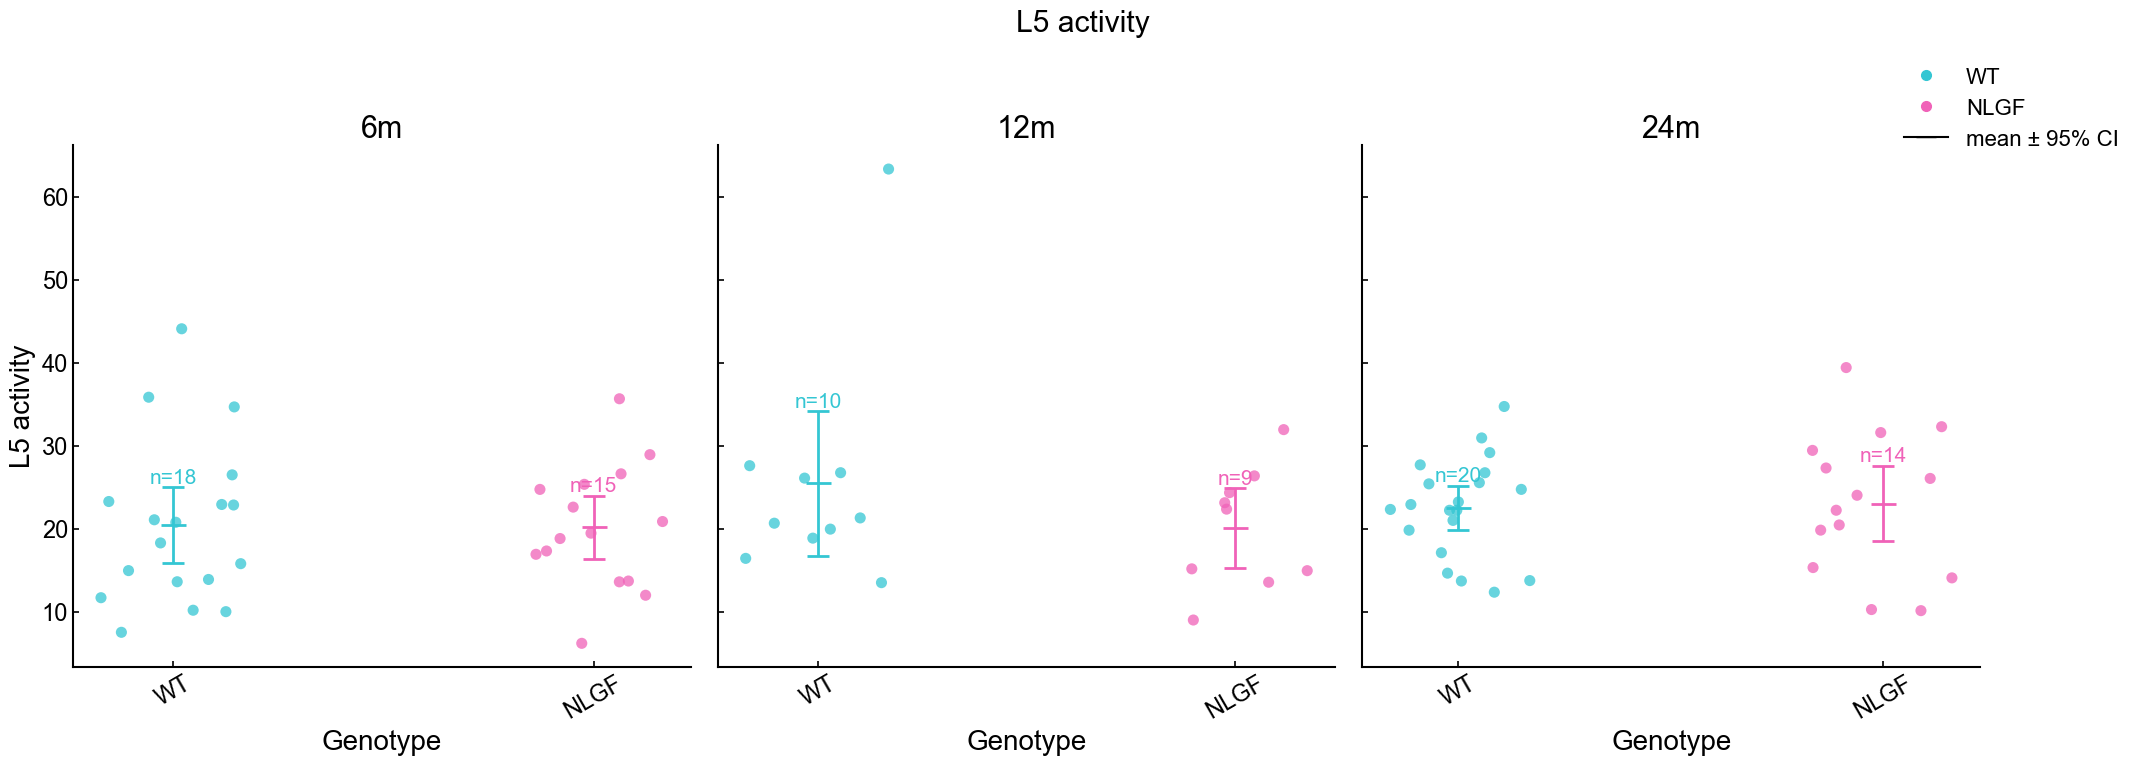

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,L5 activity,6m,WT,NLGF,18,15,20.464021,20.206083,0.085311,0.932567,0.932567,ns,Welch t-test
1,L5 activity,12m,WT,NLGF,10,9,25.471612,20.112601,53.000000,0.540291,0.540291,ns,Mann-Whitney U
2,L5 activity,24m,WT,NLGF,20,14,22.535857,23.053880,-0.192752,0.848958,0.848958,ns,Welch t-test


In [7]:
CIRCADIAN_METRICS = {
    "DI": "Diurnality Index",
    "IV": "Intradaily variability",
    "IS": "Interdaily stability",
    "RA": "Relative amplitude",
    "M10": "M10 activity",
    "L5": "L5 activity",
}

for metric, label in CIRCADIAN_METRICS.items():
    plot_metric_by_age(
        circadian_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"circadian_{metric}.png",
    )

## 8. Active bout statistics

Main active-bout measures:

- `count`: number of active bouts
- `total`: total active bout duration
- `mean`: mean active bout duration
- `median`: median active bout duration

Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_count.png


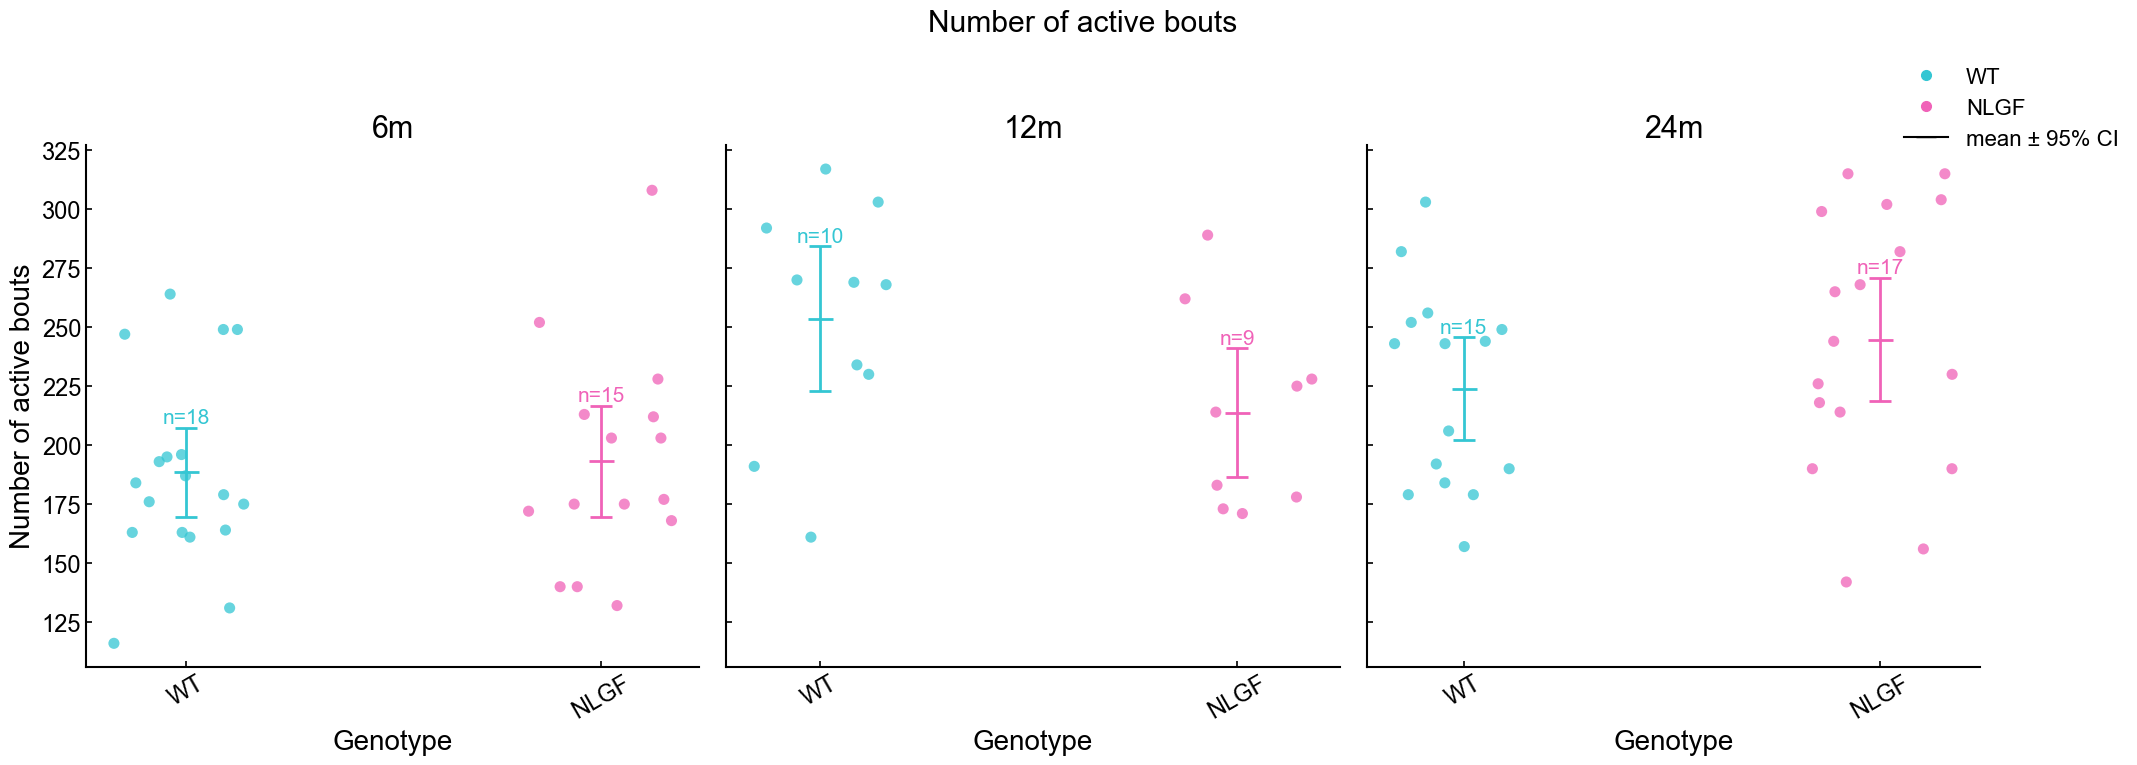

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Number of active bouts,6m,WT,NLGF,18,15,188.444444,193.200000,-0.309512,0.759210,0.759210,ns,Welch t-test
1,Number of active bouts,12m,WT,NLGF,10,9,253.500000,213.666667,1.898440,0.074803,0.074803,ns,Welch t-test
2,Number of active bouts,24m,WT,NLGF,15,17,223.933333,244.705882,-1.196226,0.241108,0.241108,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_total.png


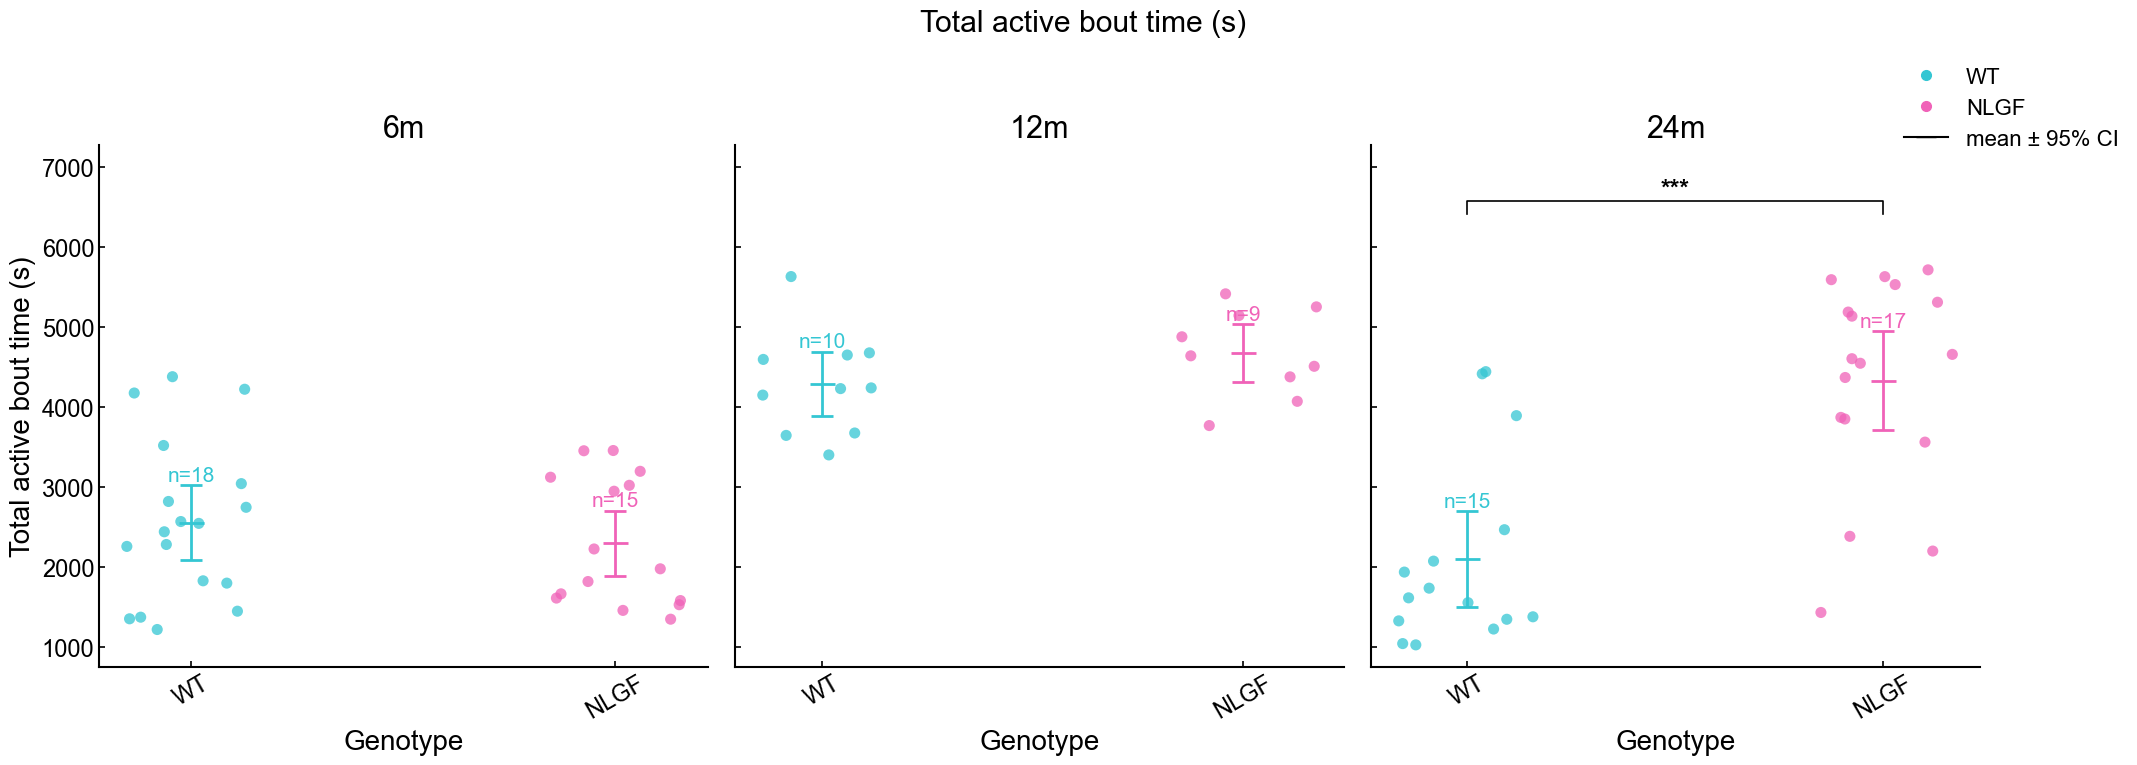

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Total active bout time (s),6m,WT,NLGF,18,15,2557.944444,2295.466667,150.000000,0.600106,0.600106,ns,Mann-Whitney U
1,Total active bout time (s),12m,WT,NLGF,10,9,4291.200000,4674.666667,-1.391011,0.182201,0.182201,ns,Welch t-test
2,Total active bout time (s),24m,WT,NLGF,15,17,2099.866667,4329.823529,28.000000,0.000185,0.000185,***,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_mean.png


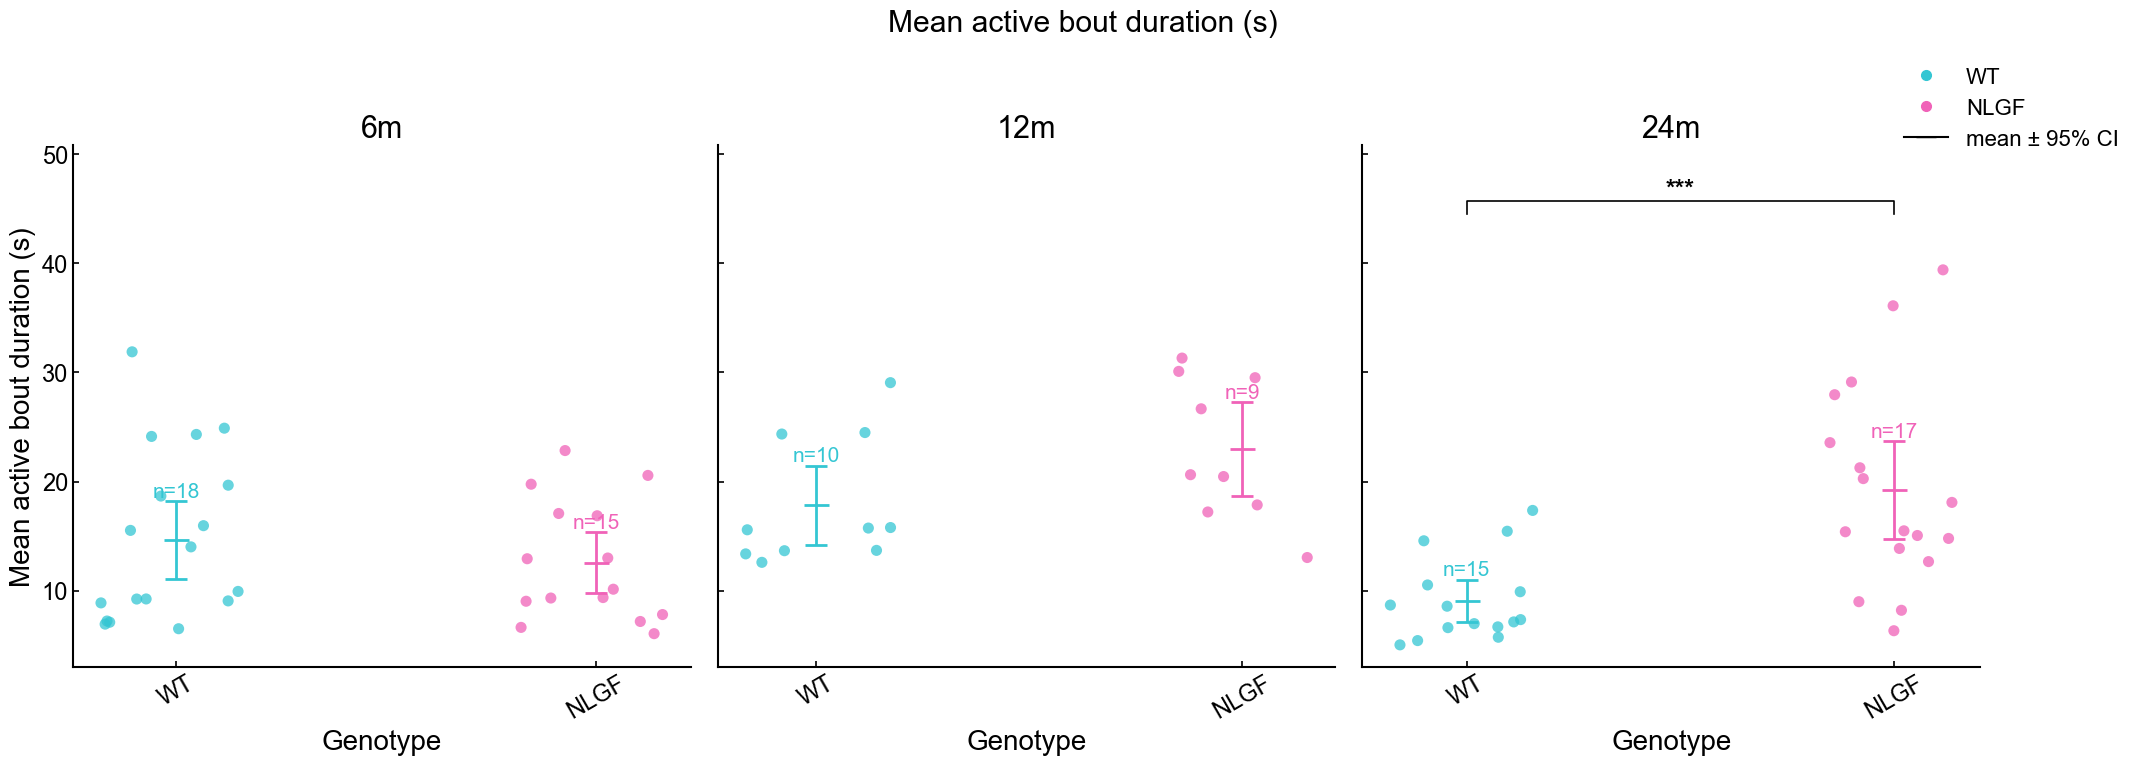

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Mean active bout duration (s),6m,WT,NLGF,18,15,14.627958,12.578271,148.0,0.651313,0.651313,ns,Mann-Whitney U
1,Mean active bout duration (s),12m,WT,NLGF,10,9,17.838017,22.978837,22.0,0.066193,0.066193,ns,Mann-Whitney U
2,Mean active bout duration (s),24m,WT,NLGF,15,17,9.076732,19.213575,37.0,0.000677,0.000677,***,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_median.png


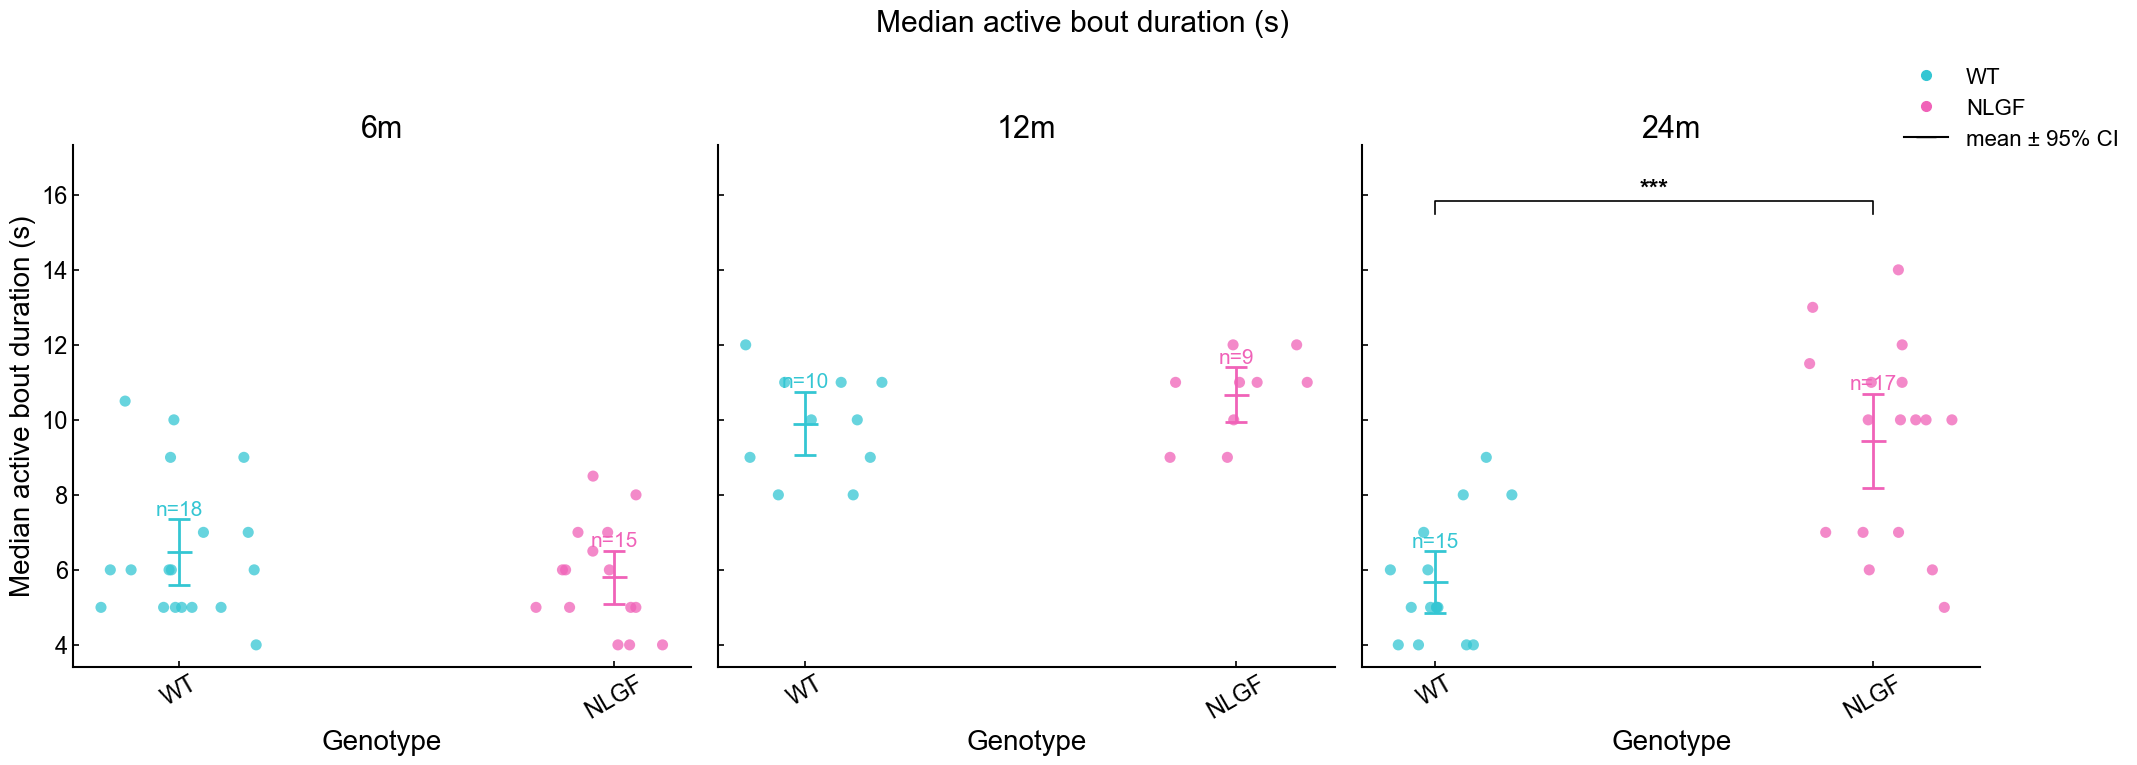

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Median active bout duration (s),6m,WT,NLGF,18,15,6.472222,5.800000,158.000000,0.405134,0.405134,ns,Mann-Whitney U
1,Median active bout duration (s),12m,WT,NLGF,10,9,9.900000,10.666667,-1.341387,0.197585,0.197585,ns,Welch t-test
2,Median active bout duration (s),24m,WT,NLGF,15,17,5.666667,9.441176,29.000000,0.000191,0.000191,***,Mann-Whitney U


In [8]:
ACTIVE_BOUT_METRICS = {
    "count": "Number of active bouts",
    "total": "Total active bout time (s)",
    "mean": "Mean active bout duration (s)",
    "median": "Median active bout duration (s)",
}

for metric, label in ACTIVE_BOUT_METRICS.items():
    plot_metric_by_age(
        active_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"active_bouts_{metric}.png",
    )

## 9. Quiescent bout statistics

Main quiescent-bout measures:

- `count`: number of quiescent bouts
- `total`: total quiescent bout duration
- `mean`: mean quiescent bout duration
- `median`: median quiescent bout duration

Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_count.png


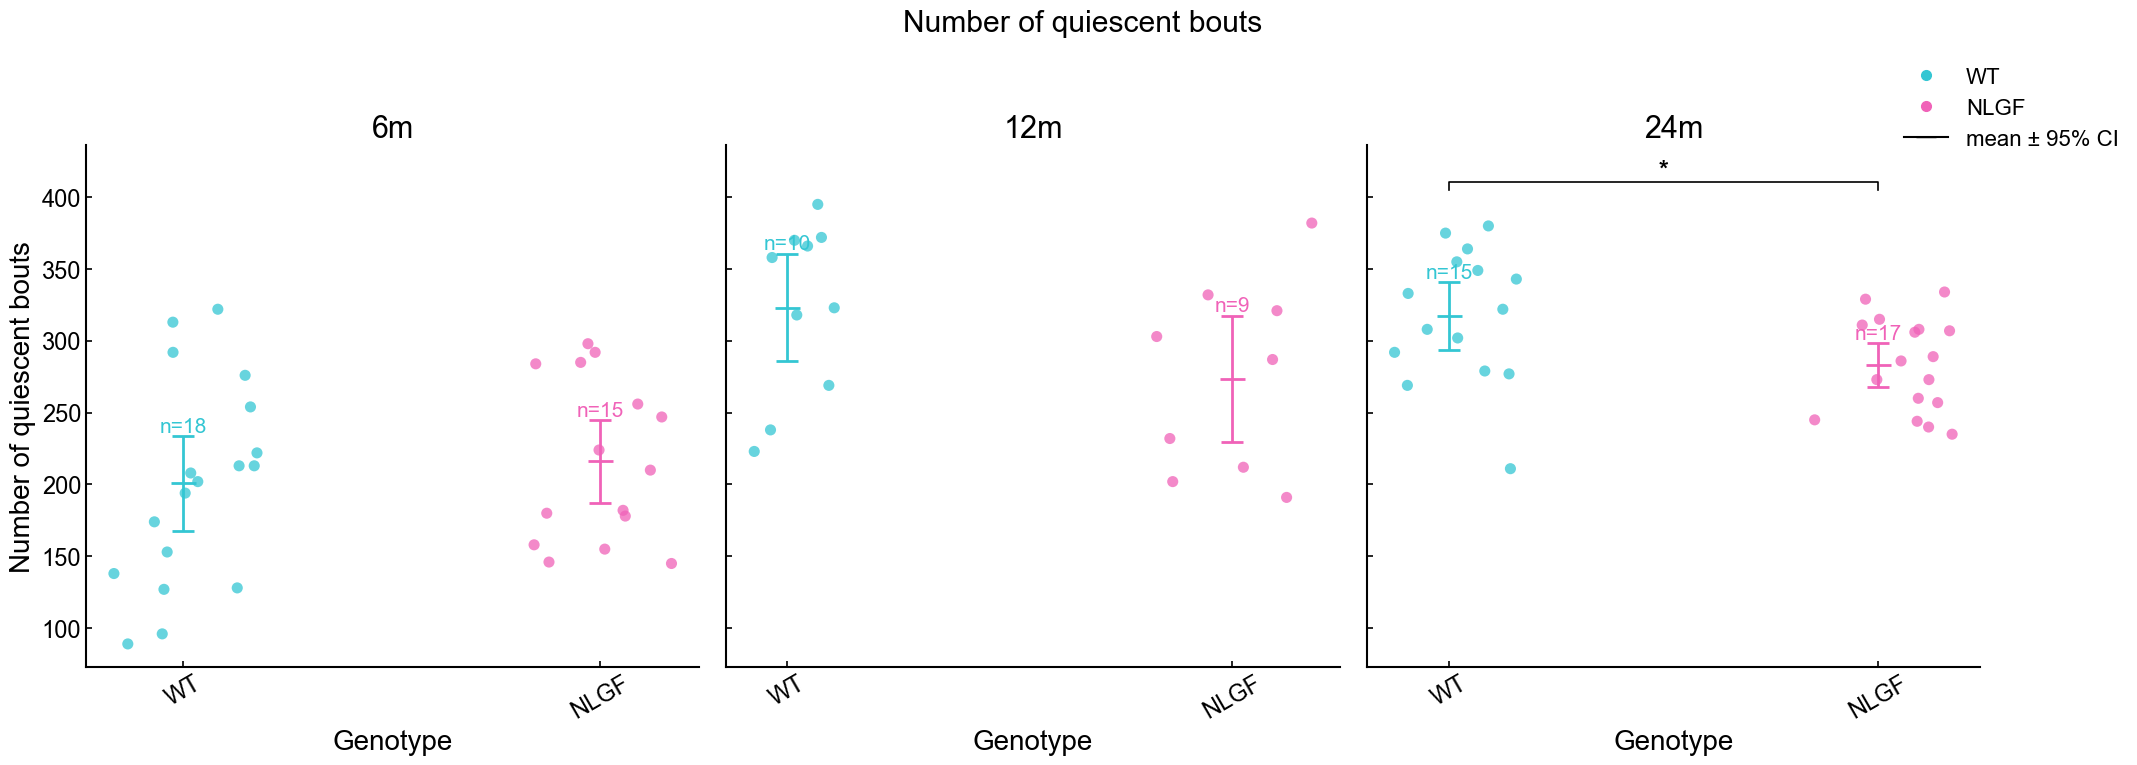

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Number of quiescent bouts,6m,WT,NLGF,18,15,200.777778,216.000000,-0.682195,0.500188,0.500188,ns,Welch t-test
1,Number of quiescent bouts,12m,WT,NLGF,10,9,323.200000,273.555556,1.686972,0.110682,0.110682,ns,Welch t-test
2,Number of quiescent bouts,24m,WT,NLGF,15,17,317.266667,283.058824,2.377630,0.025534,0.025534,*,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_total.png


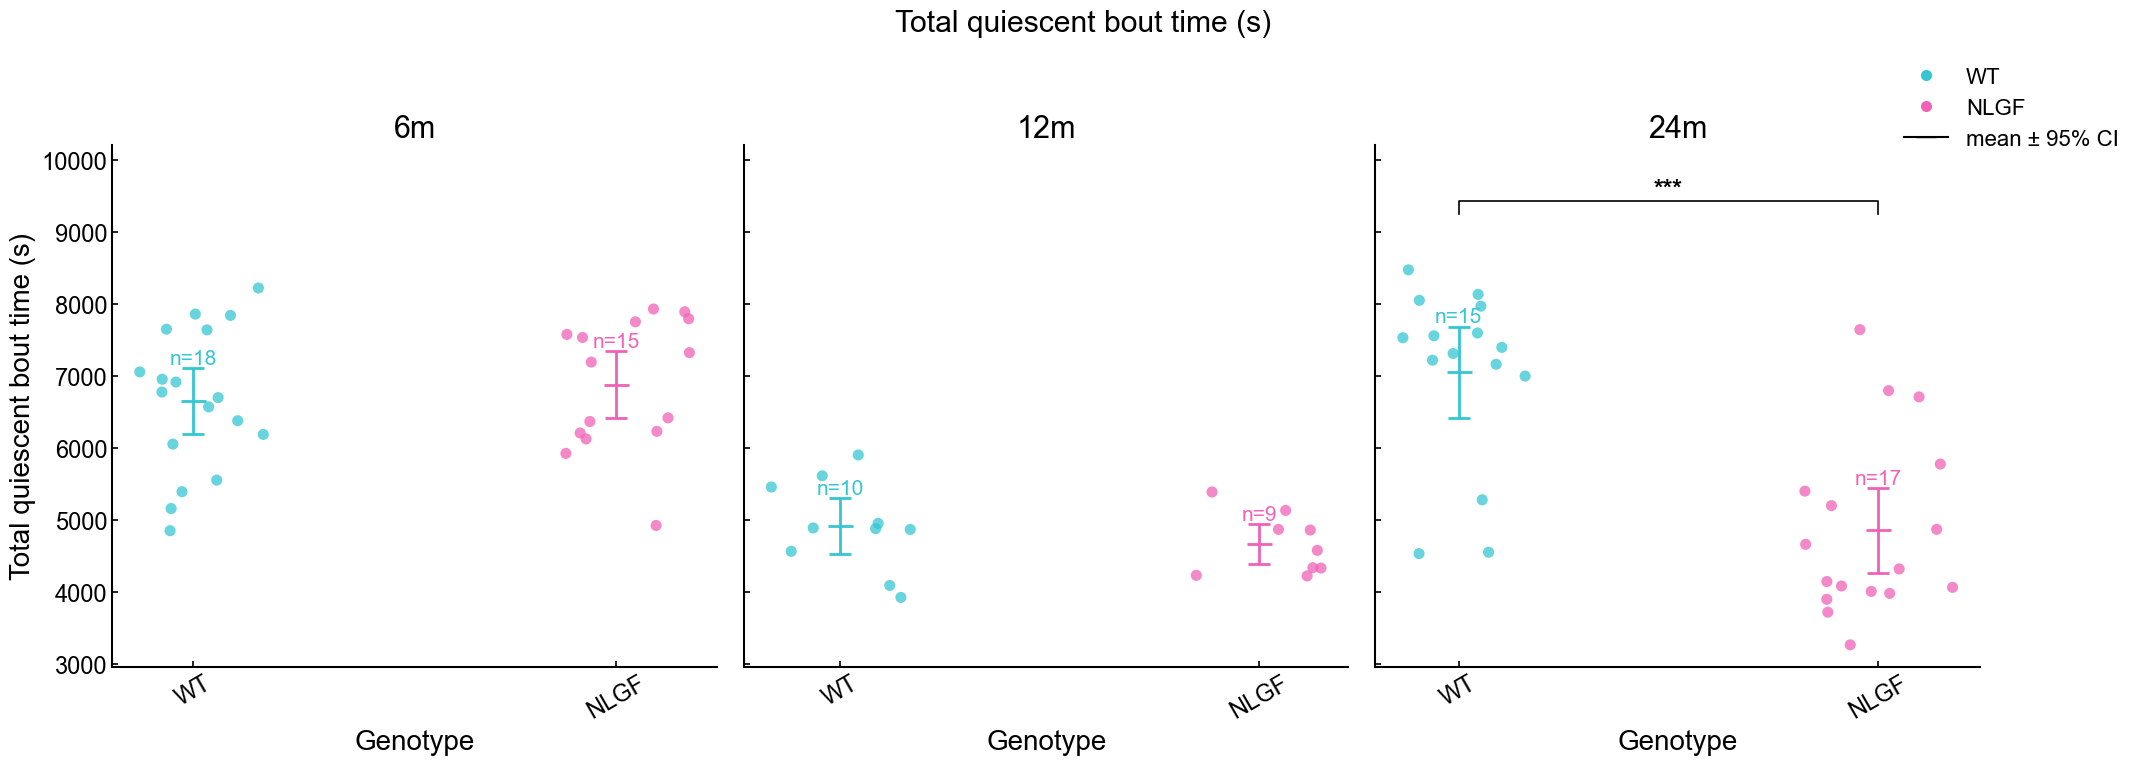

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Total quiescent bout time (s),6m,WT,NLGF,18,15,6659.055556,6885.266667,-0.683960,0.499139,0.499139,ns,Welch t-test
1,Total quiescent bout time (s),12m,WT,NLGF,10,9,4919.400000,4666.333333,1.038836,0.314484,0.314484,ns,Welch t-test
2,Total quiescent bout time (s),24m,WT,NLGF,15,17,7056.866667,4860.411765,226.000000,0.000215,0.000215,***,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_mean.png


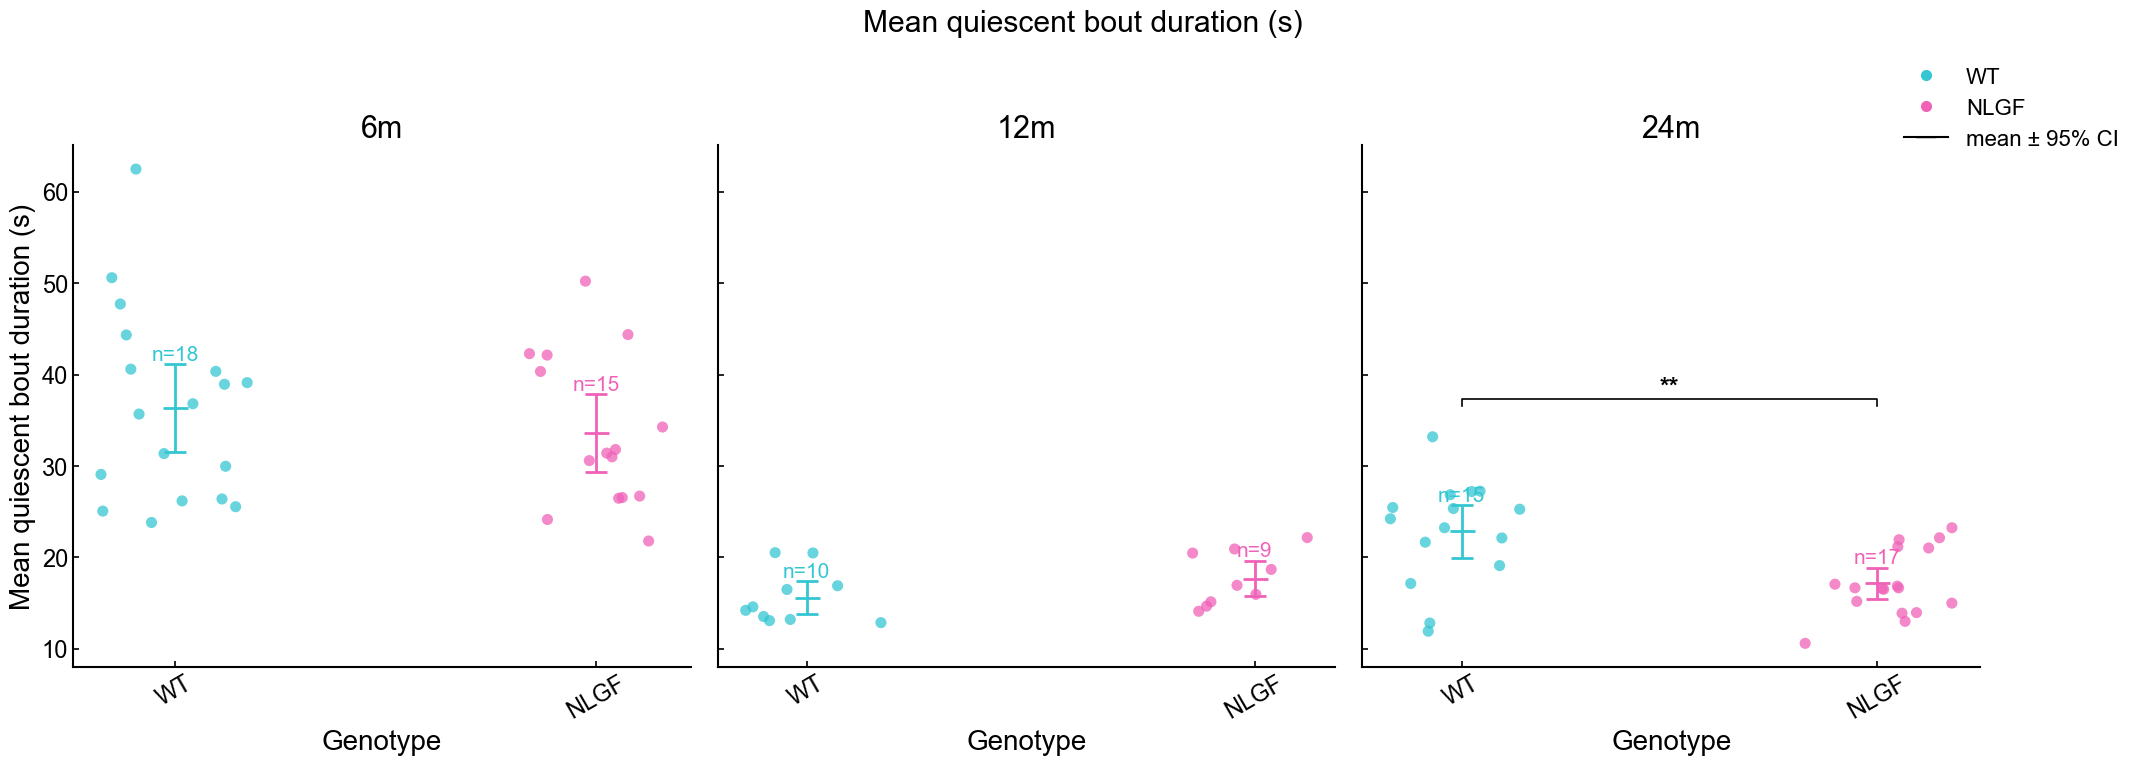

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Mean quiescent bout duration (s),6m,WT,NLGF,18,15,36.332400,33.604830,0.832628,0.411429,0.411429,ns,Welch t-test
1,Mean quiescent bout duration (s),12m,WT,NLGF,10,9,15.601615,17.685160,24.000000,0.094166,0.094166,ns,Mann-Whitney U
2,Mean quiescent bout duration (s),24m,WT,NLGF,15,17,22.863393,17.160416,3.347725,0.002774,0.002774,**,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_median.png


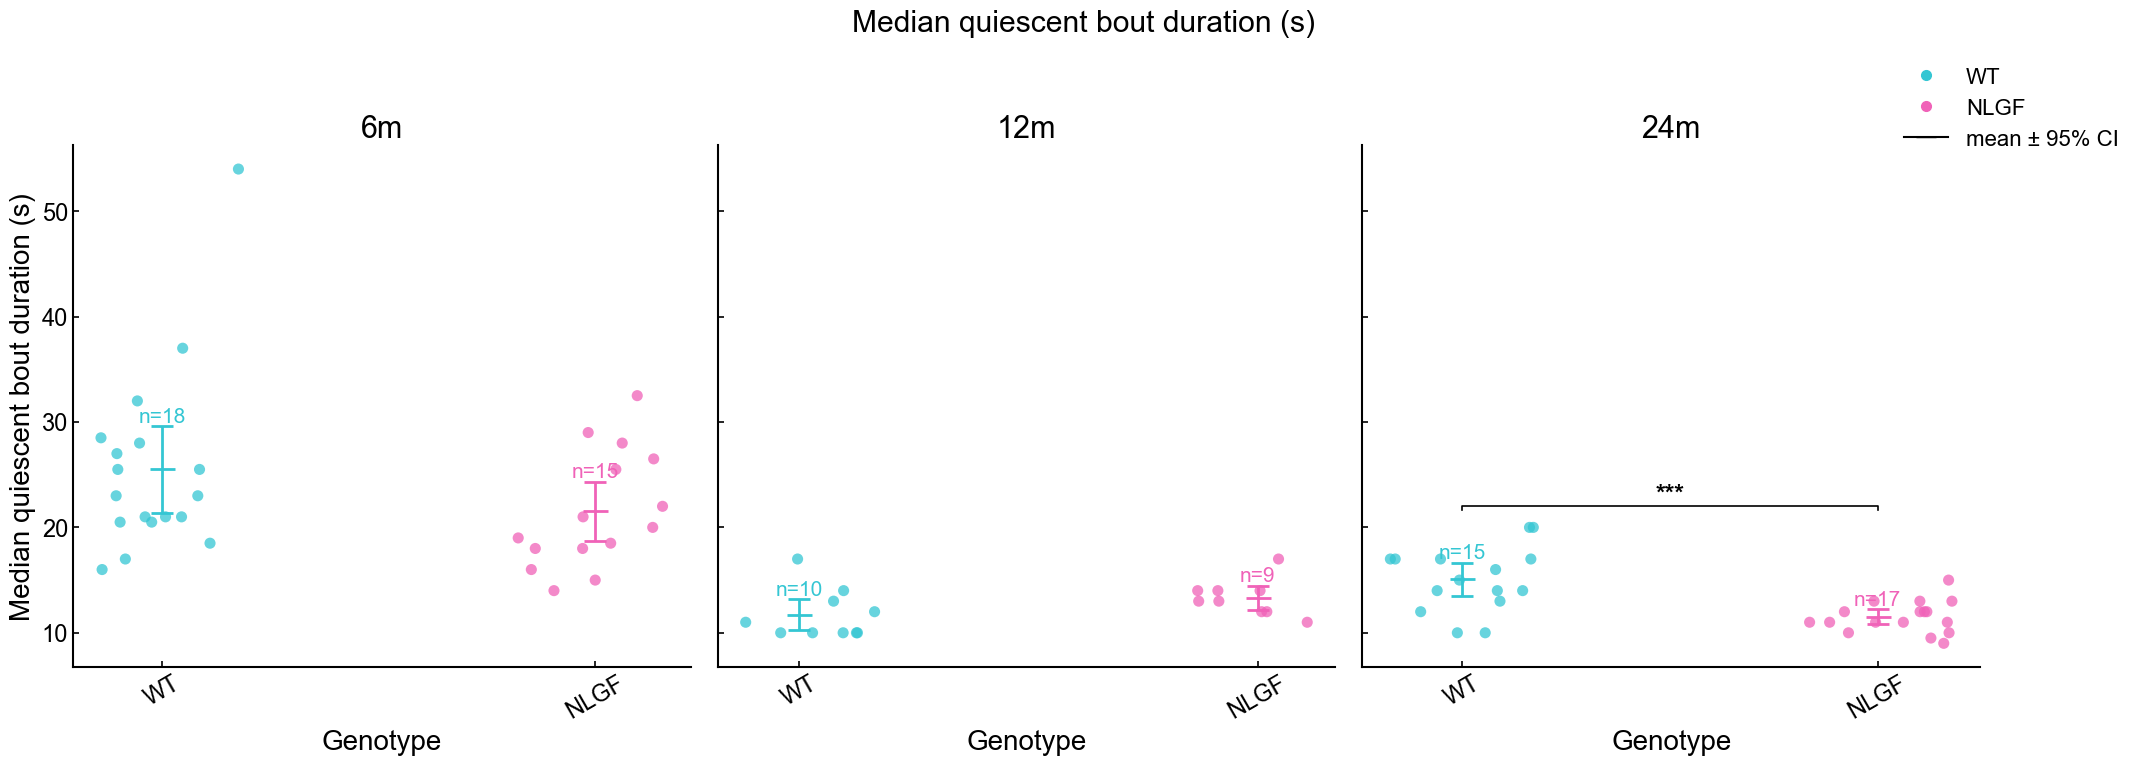

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Median quiescent bout duration (s),6m,WT,NLGF,18,15,25.500000,21.533333,175.000000,0.152568,0.152568,ns,Mann-Whitney U
1,Median quiescent bout duration (s),12m,WT,NLGF,10,9,11.700000,13.333333,21.500000,0.055904,0.055904,ns,Mann-Whitney U
2,Median quiescent bout duration (s),24m,WT,NLGF,15,17,15.066667,11.500000,4.076873,0.000603,0.000603,***,Welch t-test


In [9]:
QUIESCENT_BOUT_METRICS = {
    "count": "Number of quiescent bouts",
    "total": "Total quiescent bout time (s)",
    "mean": "Mean quiescent bout duration (s)",
    "median": "Median quiescent bout duration (s)",
}

for metric, label in QUIESCENT_BOUT_METRICS.items():
    plot_metric_by_age(
        quiescent_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"quiescent_bouts_{metric}.png",
    )

## 10. Individual bout table: active vs rest/quiescent in one table

This uses `bout_stats_individual.csv`, which contains both active and rest bout types. It can be useful if you want the same metrics plotted from one combined table.

In [10]:
individual_bouts_master["bout_type"] = individual_bouts_master["bout_type"].astype(str).str.strip()
individual_bouts_master["bout_type"].value_counts(dropna=False)

bout_type
rest      115
active    115
Name: count, dtype: int64

Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_rest_count.png


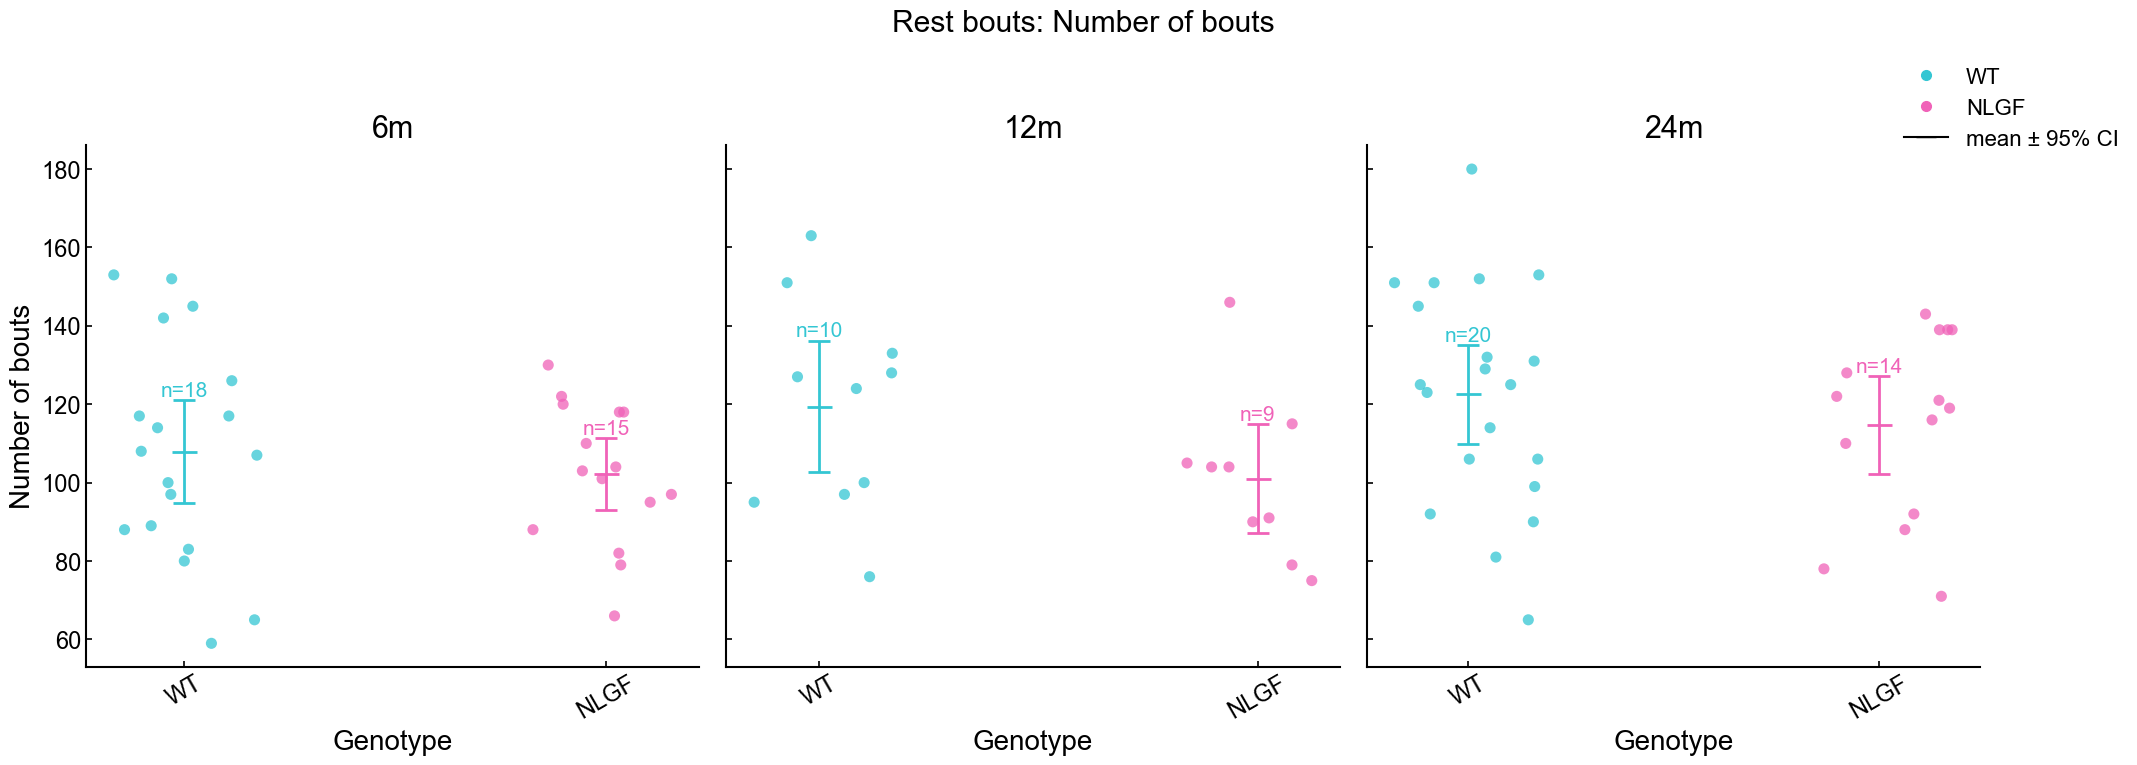

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Rest bouts: Number of bouts,6m,WT,NLGF,18,15,107.888889,102.200000,0.698563,0.490346,0.490346,ns,Welch t-test
1,Rest bouts: Number of bouts,12m,WT,NLGF,10,9,119.400000,101.000000,1.653896,0.116780,0.116780,ns,Welch t-test
2,Rest bouts: Number of bouts,24m,WT,NLGF,20,14,122.500000,114.642857,0.869558,0.391232,0.391232,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_active_count.png


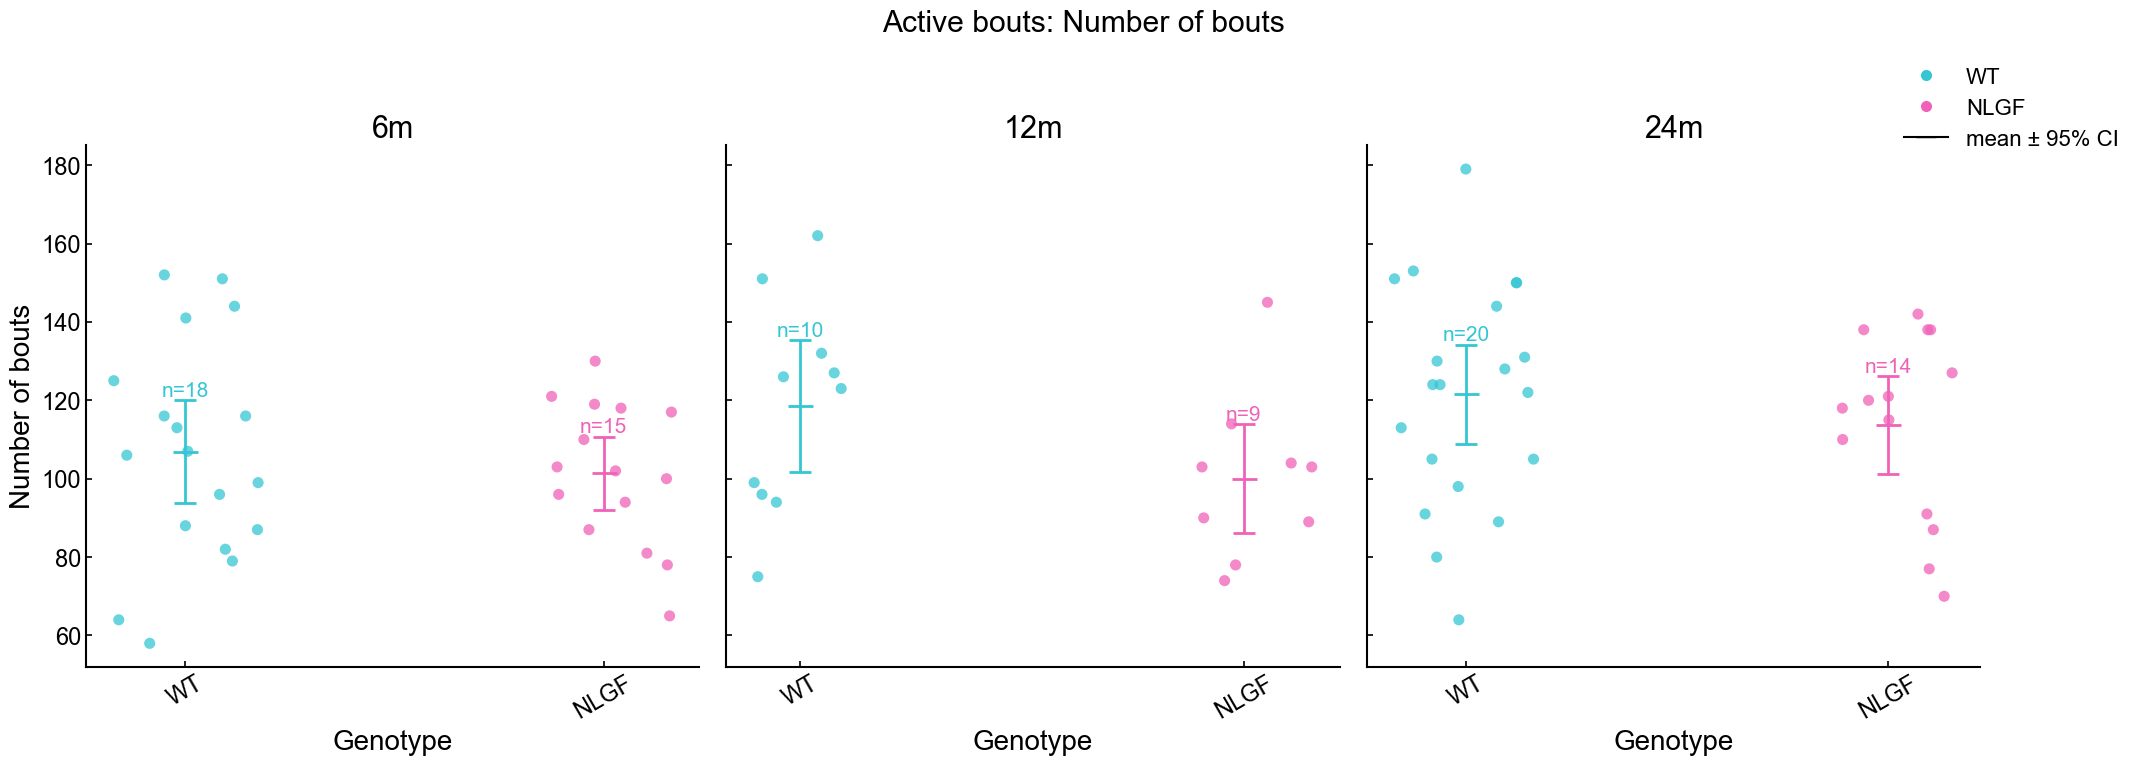

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Active bouts: Number of bouts,6m,WT,NLGF,18,15,106.888889,101.400000,0.671473,0.507168,0.507168,ns,Welch t-test
1,Active bouts: Number of bouts,12m,WT,NLGF,10,9,118.500000,100.000000,1.658121,0.115937,0.115937,ns,Welch t-test
2,Active bouts: Number of bouts,24m,WT,NLGF,20,14,121.550000,113.714286,0.866565,0.392839,0.392839,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_rest_duration_mean.png


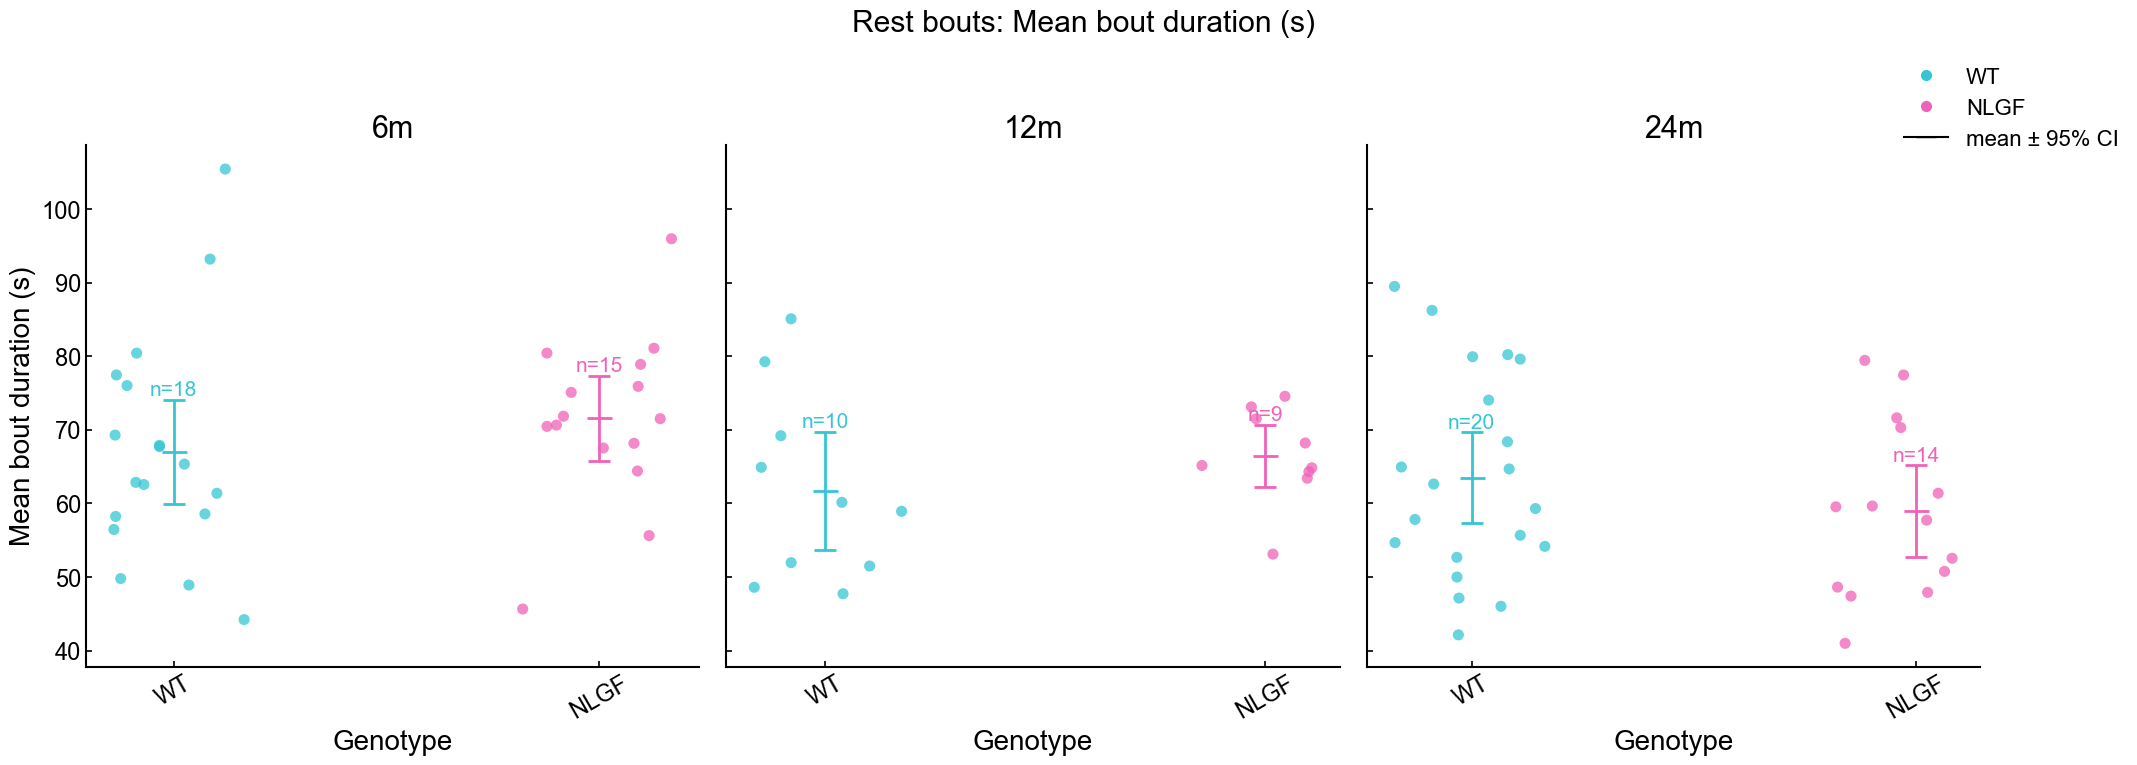

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Rest bouts: Mean bout duration (s),6m,WT,NLGF,18,15,66.997498,71.561620,-0.973677,0.337826,0.337826,ns,Welch t-test
1,Rest bouts: Mean bout duration (s),12m,WT,NLGF,10,9,61.739677,66.483340,-1.027654,0.322120,0.322120,ns,Welch t-test
2,Rest bouts: Mean bout duration (s),24m,WT,NLGF,20,14,63.497662,58.963394,1.012662,0.319141,0.319141,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_active_duration_mean.png


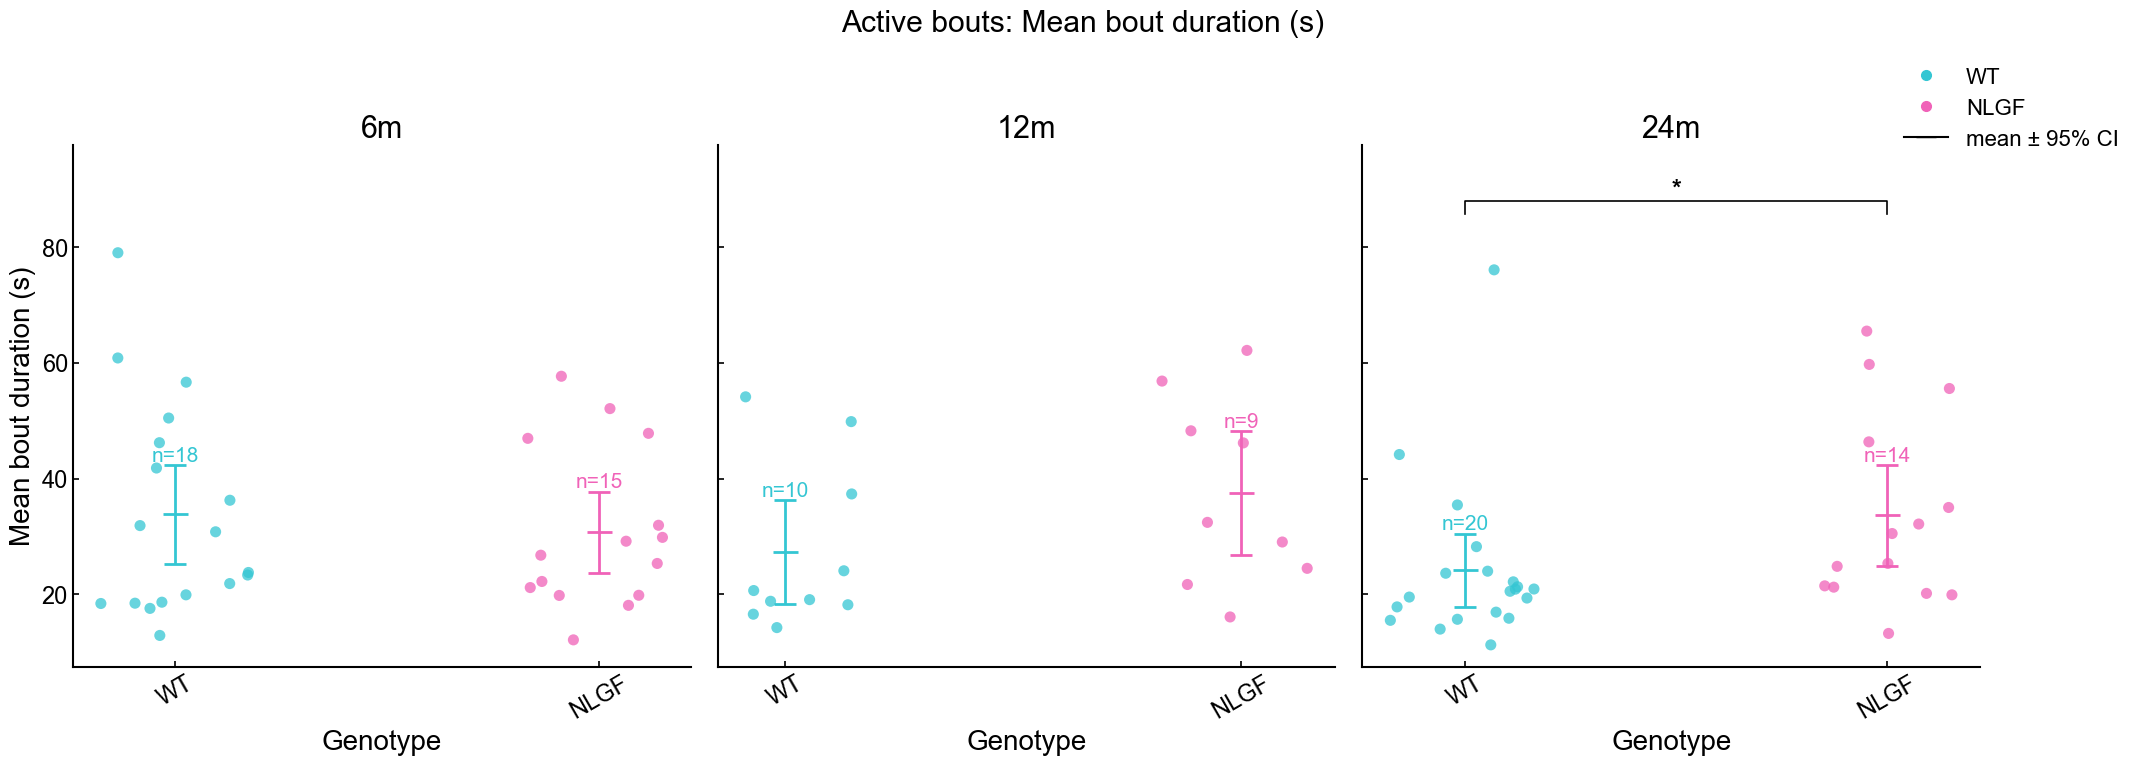

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Active bouts: Mean bout duration (s),6m,WT,NLGF,18,15,33.815725,30.713395,139.0,0.899302,0.899302,ns,Mann-Whitney U
1,Active bouts: Mean bout duration (s),12m,WT,NLGF,10,9,27.280414,37.458654,26.0,0.130911,0.130911,ns,Mann-Whitney U
2,Active bouts: Mean bout duration (s),24m,WT,NLGF,20,14,24.149939,33.633213,77.0,0.028739,0.028739,*,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_rest_duration_median.png


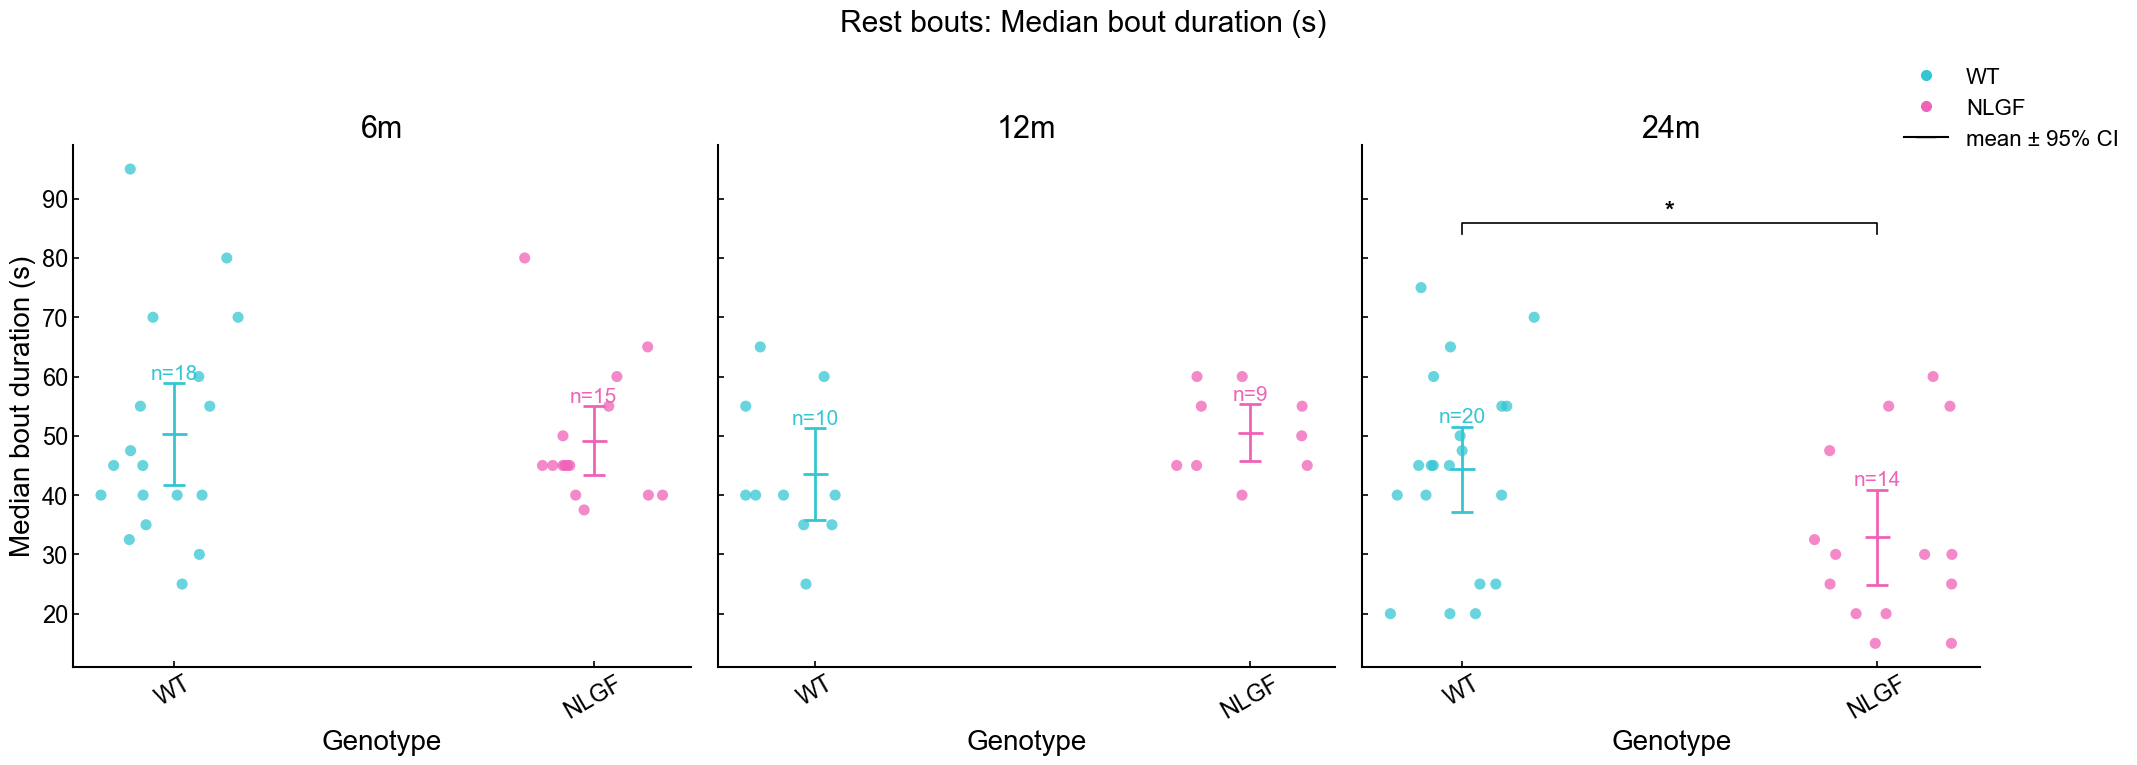

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Rest bouts: Median bout duration (s),6m,WT,NLGF,18,15,50.277778,49.166667,127.000000,0.783657,0.783657,ns,Mann-Whitney U
1,Rest bouts: Median bout duration (s),12m,WT,NLGF,10,9,43.500000,50.555556,-1.523500,0.148847,0.148847,ns,Welch t-test
2,Rest bouts: Median bout duration (s),24m,WT,NLGF,20,14,44.375000,32.857143,2.094808,0.044930,0.044930,*,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_active_duration_median.png


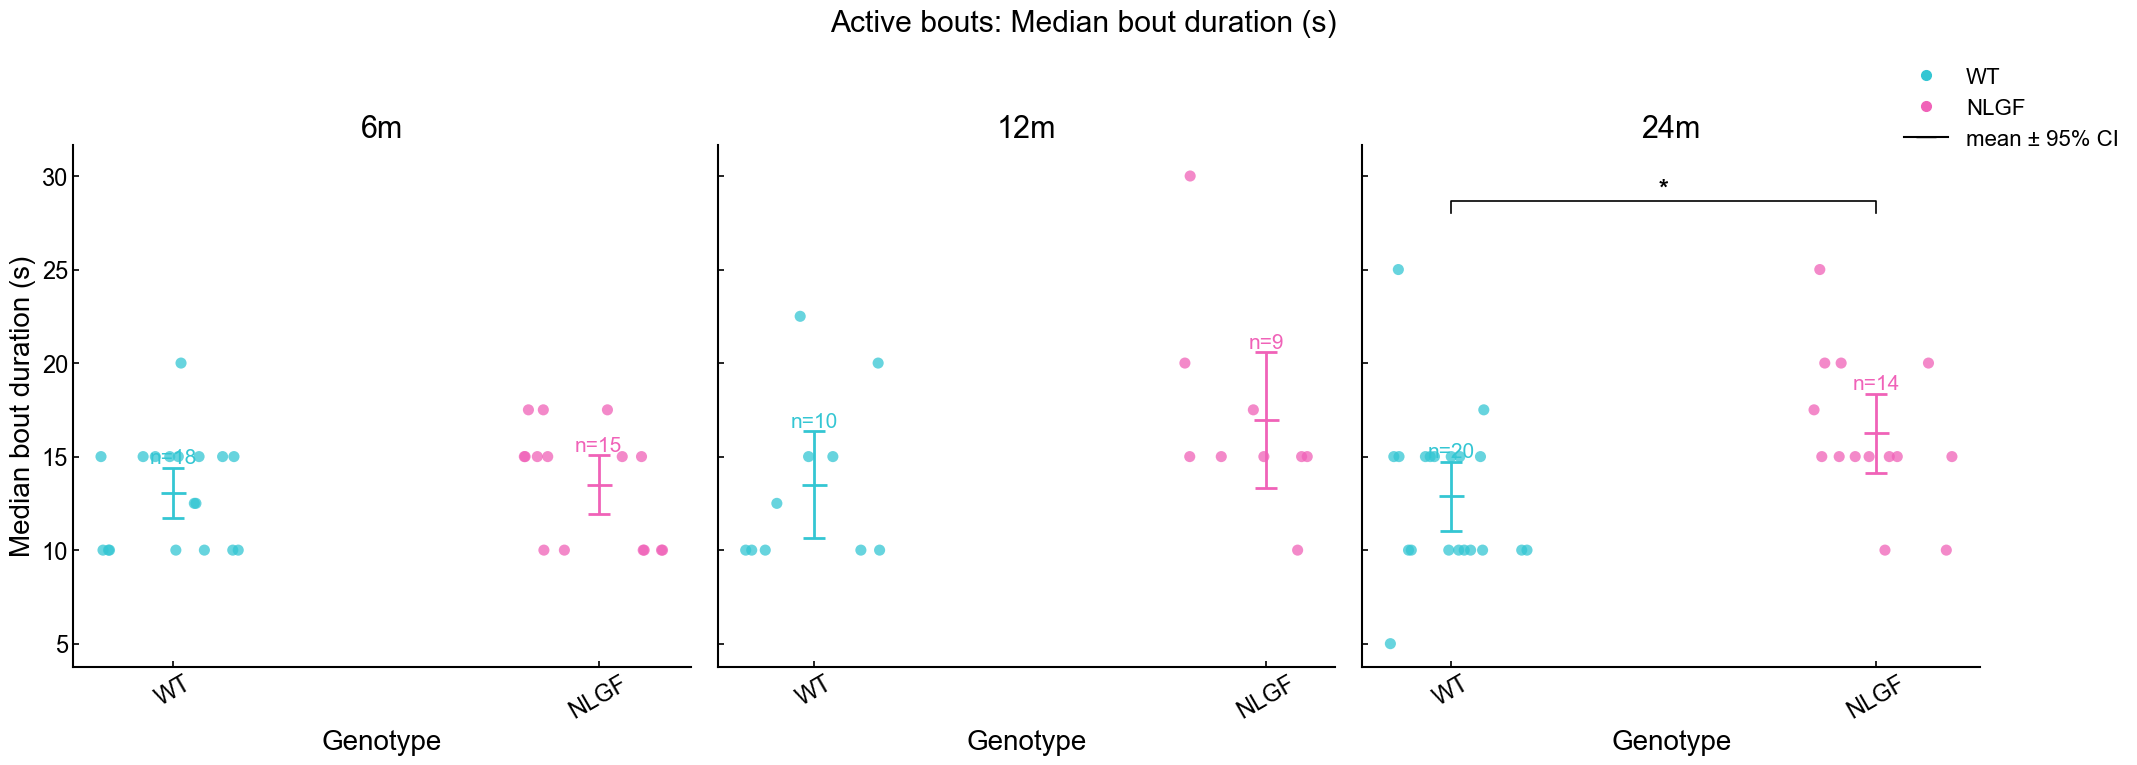

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Active bouts: Median bout duration (s),6m,WT,NLGF,18,15,13.055556,13.500000,120.0,0.572375,0.572375,ns,Mann-Whitney U
1,Active bouts: Median bout duration (s),12m,WT,NLGF,10,9,13.500000,16.944444,26.0,0.115158,0.115158,ns,Mann-Whitney U
2,Active bouts: Median bout duration (s),24m,WT,NLGF,20,14,12.875000,16.250000,76.0,0.017845,0.017845,*,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_rest_duration_std.png


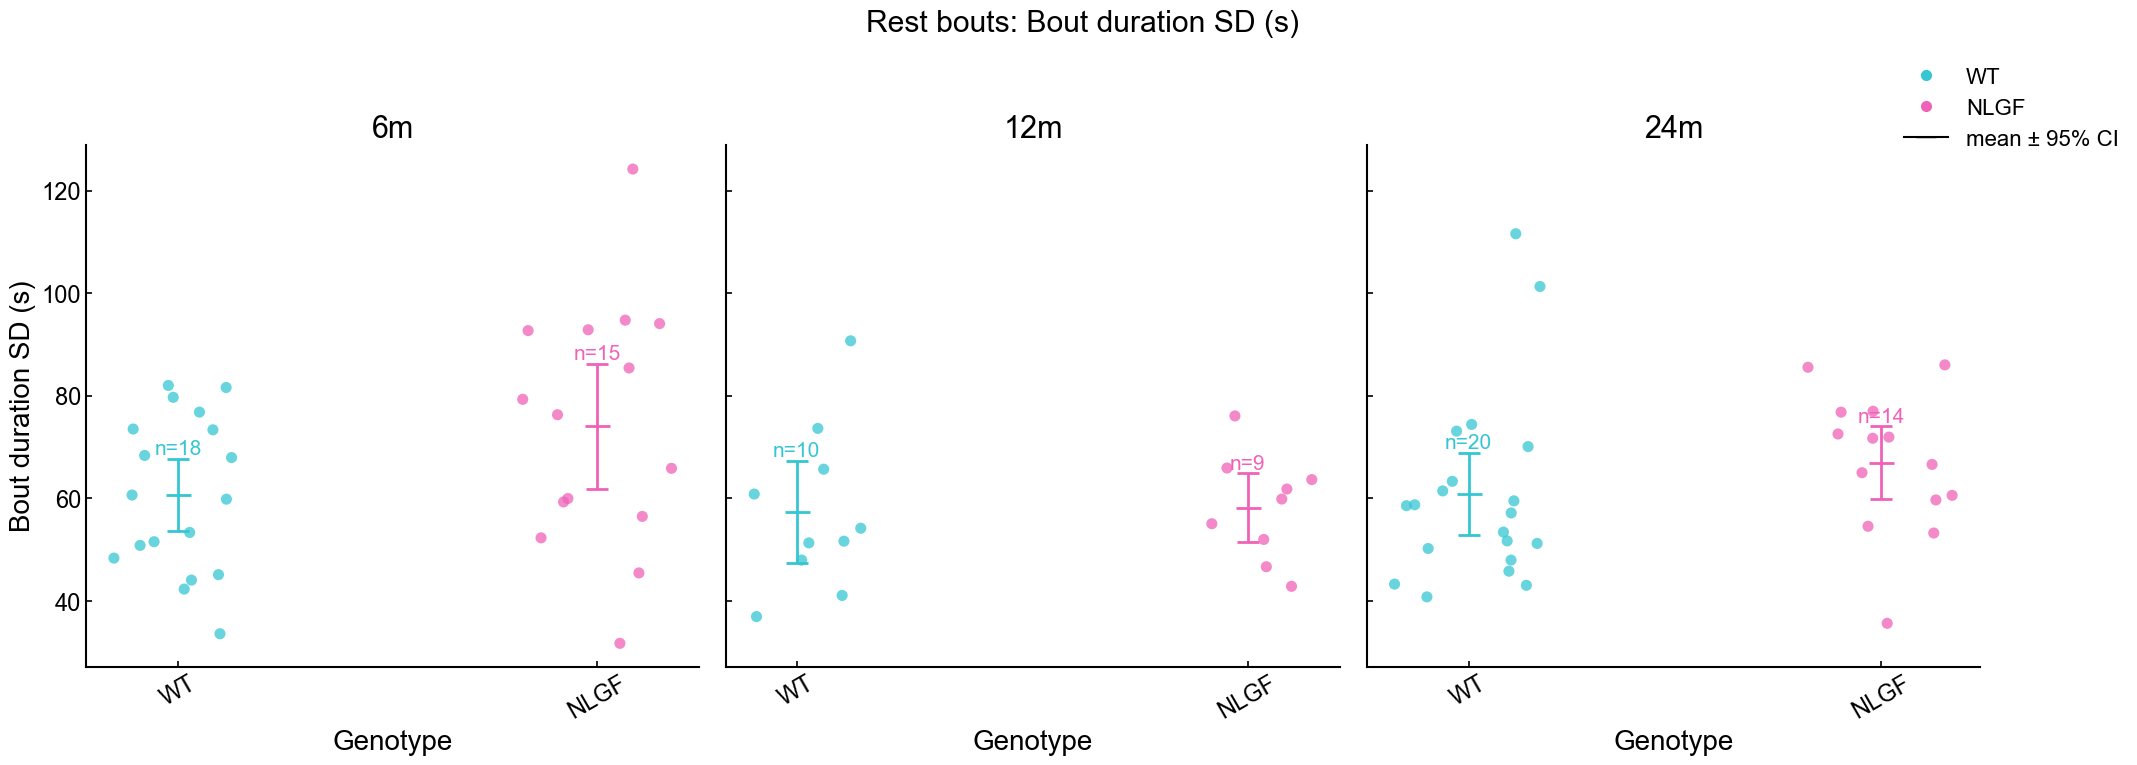

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Rest bouts: Bout duration SD (s),6m,WT,NLGF,18,15,60.745913,74.070277,-1.860067,0.075821,0.075821,ns,Welch t-test
1,Rest bouts: Bout duration SD (s),12m,WT,NLGF,10,9,57.423547,58.231434,-0.132209,0.896524,0.896524,ns,Welch t-test
2,Rest bouts: Bout duration SD (s),24m,WT,NLGF,20,14,60.858358,66.944253,87.000000,0.066193,0.066193,ns,Mann-Whitney U


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/individual_active_duration_std.png


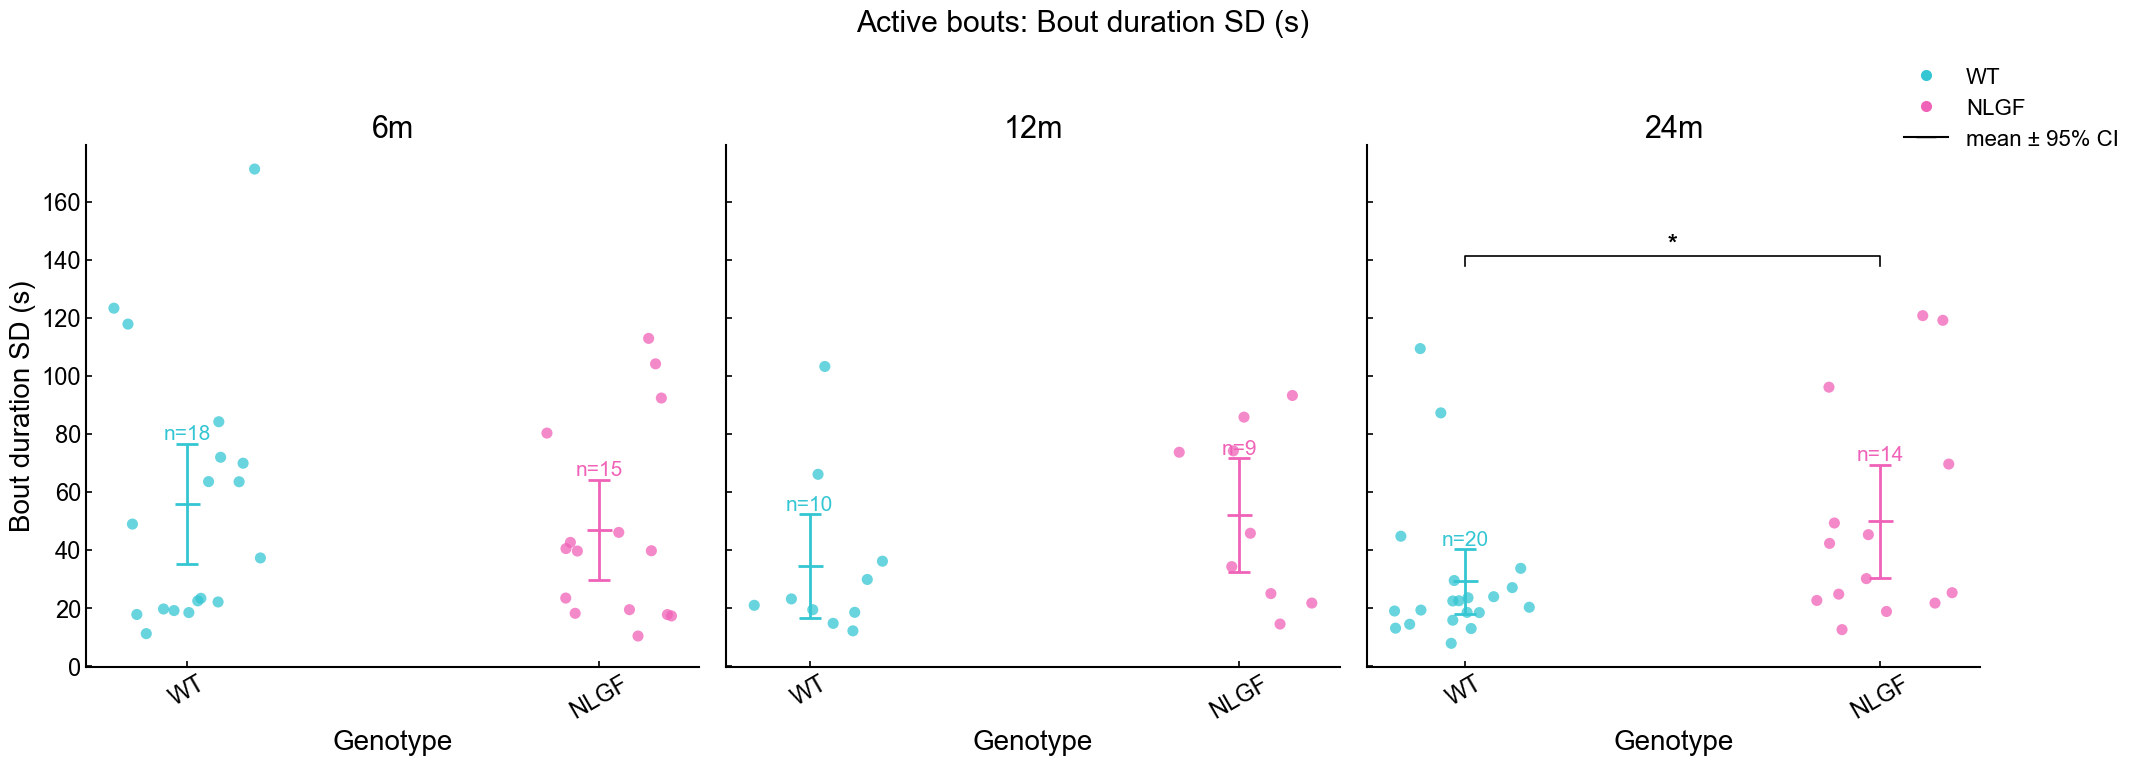

,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Active bouts: Bout duration SD (s),6m,WT,NLGF,18,15,55.877992,46.976724,150.0,0.600106,0.600106,ns,Mann-Whitney U
1,Active bouts: Bout duration SD (s),12m,WT,NLGF,10,9,34.413517,52.004036,27.0,0.153042,0.153042,ns,Mann-Whitney U
2,Active bouts: Bout duration SD (s),24m,WT,NLGF,20,14,29.167497,49.878196,76.0,0.026281,0.026281,*,Mann-Whitney U


In [11]:
def plot_individual_bout_metric_by_type(metric, ylabel=None):
    if ylabel is None:
        ylabel = metric

    for bout_type in individual_bouts_master["bout_type"].dropna().unique():
        sub = individual_bouts_master[
            individual_bouts_master["bout_type"] == bout_type
        ].copy()

        plot_metric_by_age(
            sub,
            metric=metric,
            ylabel=ylabel,
            title=f"{bout_type.capitalize()} bouts: {ylabel}",
            save_name=f"individual_{bout_type}_{metric}.png",
        )

INDIVIDUAL_BOUT_METRICS = {
    "count": "Number of bouts",
    "duration_mean": "Mean bout duration (s)",
    "duration_median": "Median bout duration (s)",
    "duration_std": "Bout duration SD (s)",
}

for metric, label in INDIVIDUAL_BOUT_METRICS.items():
    plot_individual_bout_metric_by_type(metric, label)

## 11. Optional: Daily bout statistics

This section plots daily changes. It is more exploratory, because daily outputs may be noisier.

In [12]:
daily_master["day"] = pd.to_datetime(daily_master["day"], errors="coerce")

daily_master["day_number"] = (
    daily_master
    .groupby("MouseSessionID")["day"]
    .rank(method="dense")
    .astype("Int64")
)

daily_master.head()

,KageID,day,count,duration_mean,duration_median,duration_std,duration_min,duration_max,bout_type,Cohort,Age,MouseSessionID,SourceFile,Genotype,day_number
0,kage1,1970-01-01,21,51.428571,30.0,39.406308,10.0,130.0,rest,2024-05-may-jul_NLGF6m,6m,2024-05-may-jul_NLGF6m_kage1,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,WT,1
1,kage1,1970-01-01,20,20.250000,15.0,15.515273,5.0,65.0,active,2024-05-may-jul_NLGF6m,6m,2024-05-may-jul_NLGF6m_kage1,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,WT,1
2,kage1,1970-01-02,23,47.173913,25.0,42.475289,10.0,160.0,rest,2024-05-may-jul_NLGF6m,6m,2024-05-may-jul_NLGF6m_kage1,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,WT,2
3,kage1,1970-01-02,23,15.869565,10.0,15.929687,5.0,65.0,active,2024-05-may-jul_NLGF6m,6m,2024-05-may-jul_NLGF6m_kage1,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,WT,2
4,kage1,1970-01-03,18,48.888889,32.5,43.540230,10.0,175.0,rest,2024-05-may-jul_NLGF6m,6m,2024-05-may-jul_NLGF6m_kage1,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/mo...,WT,3


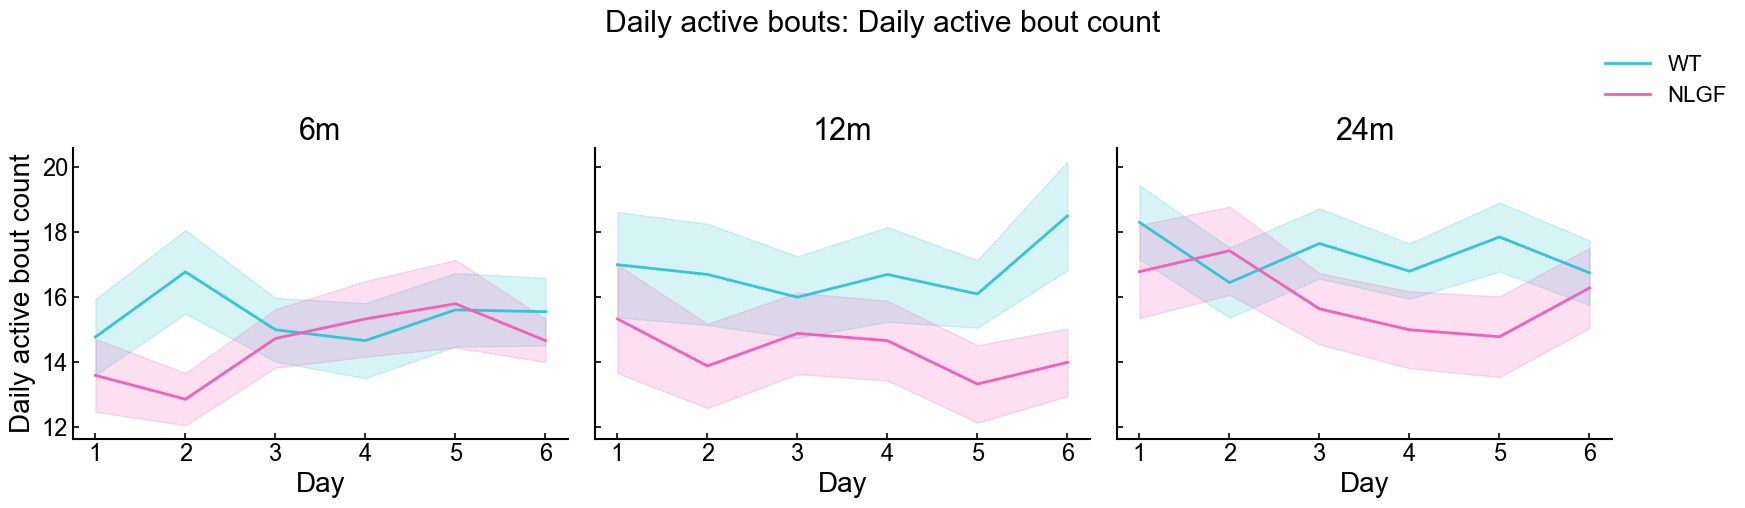

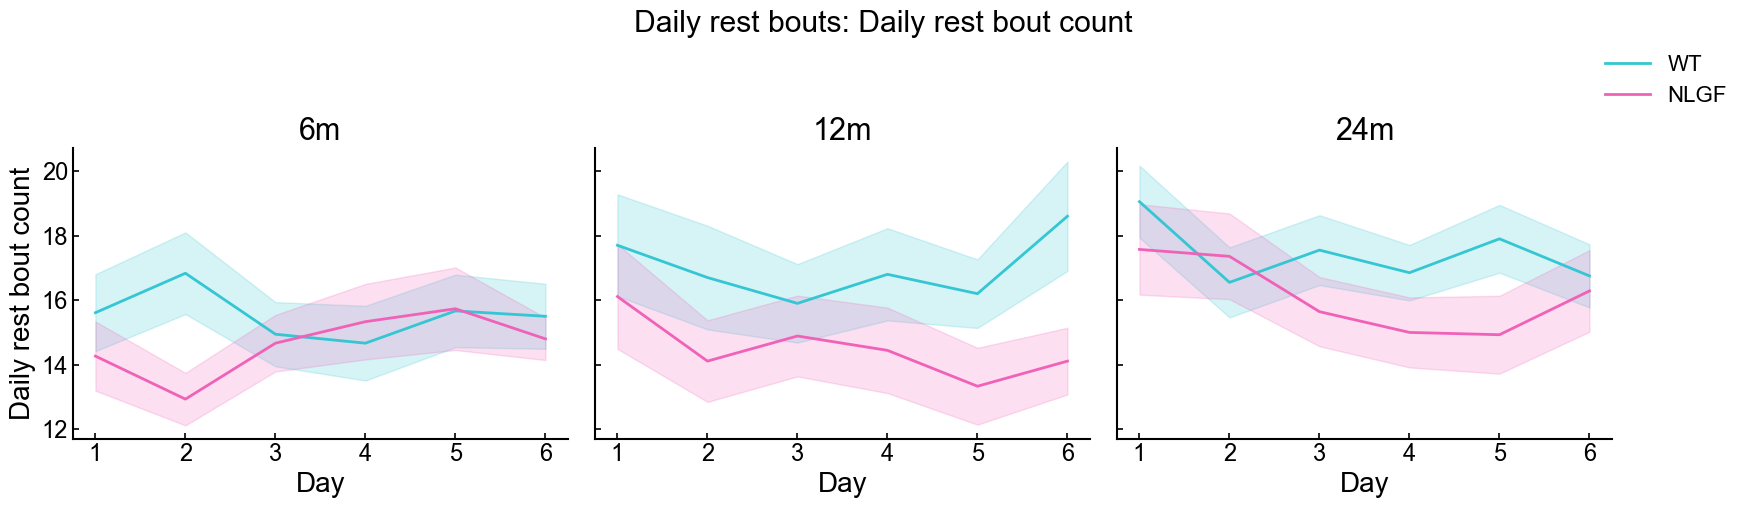

In [13]:
def plot_daily_bout_metric(metric, bout_type="active", ylabel=None):
    df = daily_master[daily_master["bout_type"] == bout_type].copy()

    if metric not in df.columns:
        print(f"Metric {metric} not found")
        return

    if ylabel is None:
        ylabel = metric

    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric, "day_number", "Age", "Genotype"])

    # keep only the best week
    df = df[df["day_number"] < 7].copy()

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(18, 5), sharey=True)

    for ax, age in zip(axes, AGE_ORDER):
        sub = df[df["Age"] == age].copy()

        summary = (
            sub
            .groupby(["Genotype", "day_number"], as_index=False)
            .agg(
                mean_value=(metric, "mean"),
                sem_value=(metric, sem),
                n=(metric, "count")
            )
        )

        for genotype in GENO_ORDER:
            temp = summary[summary["Genotype"] == genotype].sort_values("day_number")
            if temp.empty:
                continue

            ax.plot(
                temp["day_number"],
                temp["mean_value"],
                color=GENO_COLORS[genotype],
                label=genotype,
                linewidth=2,
            )
            ax.fill_between(
                temp["day_number"],
                temp["mean_value"] - temp["sem_value"].fillna(0),
                temp["mean_value"] + temp["sem_value"].fillna(0),
                color=GENO_COLORS[genotype],
                alpha=0.2,
            )

        format_axes(ax)
        ax.set_title(age)
        ax.set_xlabel("Day")
        ax.set_ylabel(ylabel if age == AGE_ORDER[0] else "")

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(f"Daily {bout_type} bouts: {ylabel}", y=1.03)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    plt.show()

# Example daily plots
plot_daily_bout_metric("count", bout_type="active", ylabel="Daily active bout count")
plot_daily_bout_metric("count", bout_type="rest", ylabel="Daily rest bout count")

## 12. Age comparisons within each genotype

The previous plots compare **genotypes within each age group**.

This section asks the complementary question:

> Does each genotype change across age?

For each metric, the figure is split by genotype:
- WT: 6m vs 12m vs 24m
- NLGF: 6m vs 12m vs 24m
- APP1-em1BDS: 6m vs 12m vs 24m

Statistics:
- Pairwise Welch t-tests compare age groups within each genotype.
- Significant comparisons are marked on the figure with `*`, `**`, `***`, or `****`.


In [14]:

# ---------------------------------------------------------------------
# Age-comparison statistics helpers
# ---------------------------------------------------------------------

AGE_STATS_RESULTS = []


def pairwise_age_stats(data, metric, metric_label=None):
    """
    Pairwise Welch t-tests comparing age groups within each genotype.
    Holm correction is applied separately within each genotype.
    """
    df = data.copy()
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric, "Age", "Genotype"])
    df = df[df["Age"].isin(AGE_ORDER)].copy()
    df = df[df["Genotype"].isin(GENO_ORDER)].copy()

    rows = []

    for genotype in GENO_ORDER:
        sub_geno = df[df["Genotype"] == genotype].copy()

        genotype_rows = []

        for i, a1 in enumerate(AGE_ORDER):
            for a2 in AGE_ORDER[i + 1:]:

                x = sub_geno[sub_geno["Age"] == a1][metric].dropna().values
                y = sub_geno[sub_geno["Age"] == a2][metric].dropna().values

                if len(x) >= 2 and len(y) >= 2:
                    test = stats.ttest_ind(
                        x,
                        y,
                        equal_var=False,
                        nan_policy="omit"
                    )
                    p_raw = test.pvalue
                    statistic = test.statistic
                    test_name = "Welch t-test"
                else:
                    p_raw = np.nan
                    statistic = np.nan
                    test_name = "Welch t-test"

                genotype_rows.append({
                    "Metric": metric_label if metric_label is not None else metric,
                    "Genotype": genotype,
                    "Group 1": a1,
                    "Group 2": a2,
                    "n1": len(x),
                    "n2": len(y),
                    "mean1": np.nanmean(x) if len(x) else np.nan,
                    "mean2": np.nanmean(y) if len(y) else np.nan,
                    "statistic": statistic,
                    "p_raw": p_raw,
                    "test": test_name,
                })

        if genotype_rows:
            temp = pd.DataFrame(genotype_rows)
            temp["p_holm"] = holm_correction(temp["p_raw"].values)
            temp["stars"] = temp["p_holm"].apply(p_to_stars)
            rows.append(temp)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def add_age_sig_bars(ax, stats_df, genotype, y_values, only_significant=True):
    """Add significance bars to a genotype-specific age-comparison plot."""
    if stats_df is None or stats_df.empty:
        return

    sub_stats = stats_df[stats_df["Genotype"] == genotype].copy()

    if only_significant:
        sub_stats = sub_stats[sub_stats["p_holm"] < 0.05].copy()

    if sub_stats.empty:
        return

    y_values = pd.to_numeric(pd.Series(y_values), errors="coerce").dropna()

    if len(y_values) == 0:
        return

    ymin = float(y_values.min())
    ymax = float(y_values.max())
    yrange = ymax - ymin

    if yrange == 0:
        yrange = abs(ymax) if ymax != 0 else 1

    current_y = ymax + yrange * 0.15
    step = yrange * 0.13

    for _, row in sub_stats.iterrows():

        a1 = row["Group 1"]
        a2 = row["Group 2"]

        if a1 not in AGE_ORDER or a2 not in AGE_ORDER:
            continue

        x1 = AGE_ORDER.index(a1)
        x2 = AGE_ORDER.index(a2)

        if x1 == x2:
            continue

        star = row["stars"]

        if star == "" or (only_significant and star == "ns"):
            continue

        h = step * 0.25

        ax.plot(
            [x1, x1, x2, x2],
            [current_y, current_y + h, current_y + h, current_y],
            color="black",
            linewidth=1.2,
            clip_on=False,
        )

        ax.text(
            (x1 + x2) / 2,
            current_y + h,
            star,
            ha="center",
            va="bottom",
            fontsize=13,
            color="black",
            clip_on=False,
        )

        current_y += step

    low, high = ax.get_ylim()
    ax.set_ylim(low, max(high, current_y + step * 0.4))


def plot_metric_by_genotype_age(
    data,
    metric,
    ylabel=None,
    title=None,
    save_name=None,
    y_lim=None,
    show_points=True,
    ci_multiplier=1.96,
    add_stats=True,
    only_significant=True,
    show_stats_table=True,
):
    """
    Plot one metric comparing age groups within each genotype.

    Layout:
    - columns = genotype
    - x-axis = age group
    - points = individual mice
    - error bar = mean ± 95% CI

    Statistics:
    - Pairwise Welch t-tests compare ages within each genotype.
    - Holm correction is applied within each genotype.
    - Significant comparisons are added as figure stars.
    """
    df = data.copy()

    if metric not in df.columns:
        print(f"Metric '{metric}' not found. Available columns:")
        print(df.columns.tolist())
        return None

    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric, "Age", "Genotype"])
    df = df[df["Age"].isin(AGE_ORDER)].copy()
    df = df[df["Genotype"].isin(GENO_ORDER)].copy()

    if ylabel is None:
        ylabel = metric
    if title is None:
        title = metric

    stats_df = None
    if add_stats:
        stats_df = pairwise_age_stats(
            df,
            metric=metric,
            metric_label=title,
        )

        if stats_df is not None and not stats_df.empty:
            AGE_STATS_RESULTS.append(stats_df.copy())

    fig, axes = plt.subplots(
        1,
        len(GENO_ORDER),
        figsize=(20, 6),
        sharey=True
    )

    if len(GENO_ORDER) == 1:
        axes = [axes]

    for ax, genotype in zip(axes, GENO_ORDER):
        sub = df[df["Genotype"] == genotype].copy()

        if sub.empty:
            ax.axis("off")
            ax.set_title(genotype)
            continue

        if show_points:
            sns.stripplot(
                data=sub,
                x="Age",
                y=metric,
                order=AGE_ORDER,
                color=GENO_COLORS.get(genotype, "black"),
                jitter=0.18,
                size=8,
                alpha=0.75,
                ax=ax,
            )

        summary = (
            sub
            .groupby("Age", as_index=False)
            .agg(
                mean_value=(metric, "mean"),
                sem_value=(metric, lambda x: x.sem()),
                n=(metric, "count"),
            )
        )

        for i, age in enumerate(AGE_ORDER):
            row = summary[summary["Age"] == age]
            if row.empty:
                continue

            mean_value = row["mean_value"].iloc[0]
            sem_value = row["sem_value"].iloc[0]
            n = int(row["n"].iloc[0])

            if pd.isna(sem_value):
                ci_value = 0
            else:
                ci_value = ci_multiplier * sem_value

            ax.errorbar(
                i,
                mean_value,
                yerr=ci_value,
                fmt="_",
                markersize=18,
                markeredgewidth=2,
                color=GENO_COLORS.get(genotype, "black"),
                elinewidth=2,
                capsize=8,
                capthick=2,
                zorder=10,
            )

            if n > 0:
                ax.text(
                    i,
                    mean_value + ci_value,
                    f"n={n}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    color=GENO_COLORS.get(genotype, "black"),
                )

        if add_stats:
            add_age_sig_bars(
                ax=ax,
                stats_df=stats_df,
                genotype=genotype,
                y_values=sub[metric],
                only_significant=only_significant,
            )

        format_axes(ax)
        ax.set_title(genotype)
        ax.set_xlabel("Age")
        ax.tick_params(axis="x", rotation=0)
        ax.set_ylabel(ylabel if genotype == GENO_ORDER[0] else "")

        if y_lim is not None:
            ax.set_ylim(*y_lim)

    handles = [
        mpl.lines.Line2D(
            [], [],
            color=GENO_COLORS[g],
            marker="o",
            linestyle="None",
            markersize=7,
            label=g,
        )
        for g in GENO_ORDER
    ]
    handles.append(
        mpl.lines.Line2D(
            [], [],
            color="black",
            marker="_",
            linestyle="-",
            markersize=14,
            label="mean ± 95% CI",
        )
    )

    fig.legend(
        handles=handles,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
    )

    fig.suptitle(f"{title}: age comparison within genotype", y=1.03)
    plt.tight_layout(rect=[0, 0, 0.92, 1])

    if save_name:
        out_path = FIG_OUTPUT / save_name
        fig.savefig(out_path, dpi=300)
        print("Saved:", out_path)

    plt.show()

    if show_stats_table and stats_df is not None and not stats_df.empty:
        display(
            stats_df[
                [
                    "Metric", "Genotype", "Group 1", "Group 2",
                    "n1", "n2", "mean1", "mean2",
                    "statistic", "p_raw", "p_holm", "stars", "test"
                ]
            ]
        )

    return stats_df


### 12.1 Run age-comparison plots

These are the same movement metrics as above, but rearranged to compare age groups within each genotype.


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_DI_age_comparison_within_genotype.png


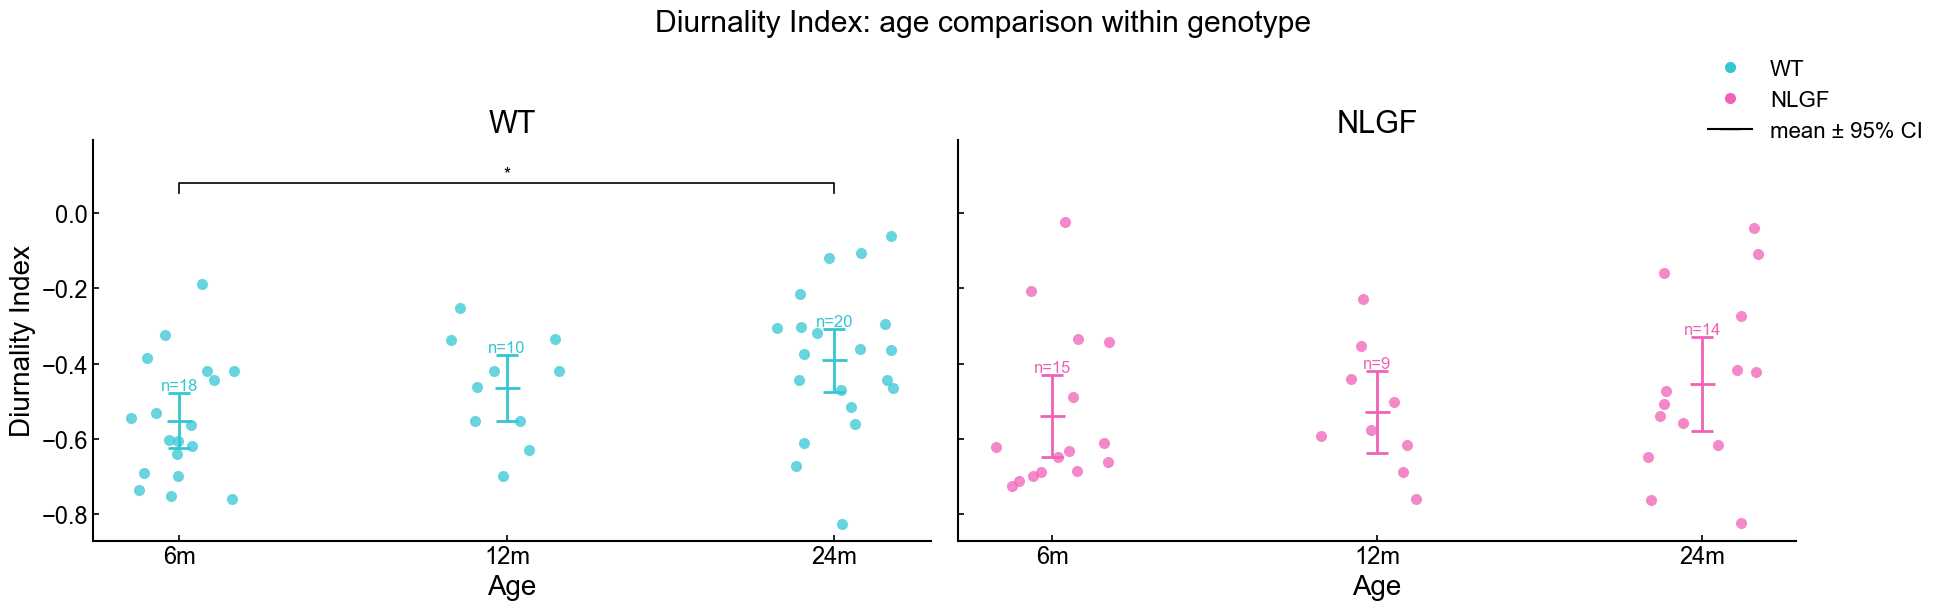

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Diurnality Index,WT,6m,12m,18,10,-0.551389,-0.465302,-1.472577,0.155861,0.311722,ns,Welch t-test
1,Diurnality Index,WT,6m,24m,18,20,-0.551389,-0.391192,-2.801191,0.008161,0.024483,*,Welch t-test
2,Diurnality Index,WT,12m,24m,10,20,-0.465302,-0.391192,-1.194134,0.244218,0.311722,ns,Welch t-test
3,Diurnality Index,NLGF,6m,12m,15,9,-0.538580,-0.528445,-0.129223,0.898454,0.965370,ns,Welch t-test
4,Diurnality Index,NLGF,6m,24m,15,14,-0.538580,-0.453689,-1.009869,0.321790,0.965370,ns,Welch t-test
5,Diurnality Index,NLGF,12m,24m,9,14,-0.528445,-0.453689,-0.886364,0.385586,0.965370,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_IV_age_comparison_within_genotype.png


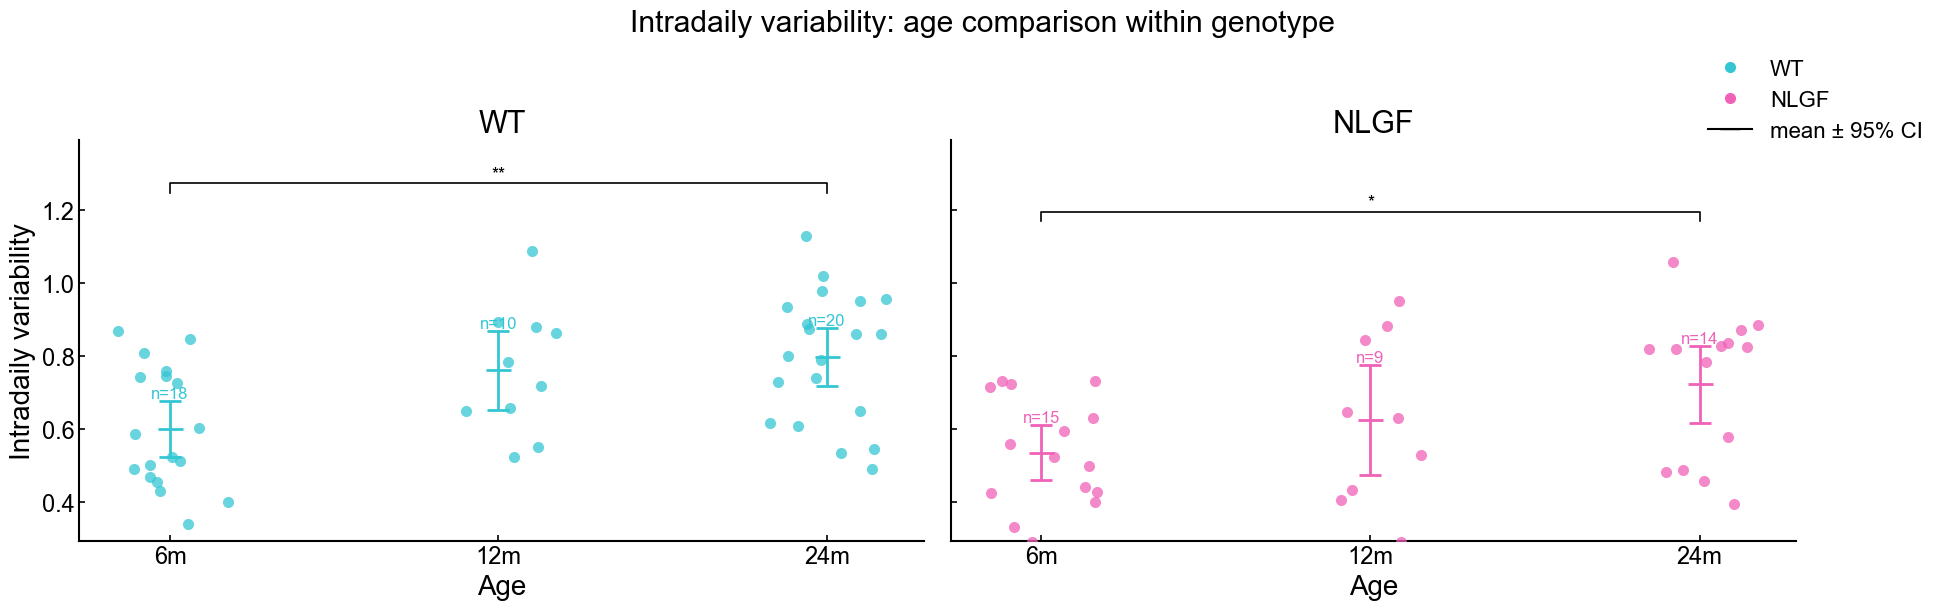

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Intradaily variability,WT,6m,12m,18,10,0.599590,0.759691,-2.362734,0.029685,0.059371,ns,Welch t-test
1,Intradaily variability,WT,6m,24m,18,20,0.599590,0.796767,-3.524084,0.001178,0.003534,**,Welch t-test
2,Intradaily variability,WT,12m,24m,10,20,0.759691,0.796767,-0.542983,0.593632,0.593632,ns,Welch t-test
3,Intradaily variability,NLGF,6m,12m,15,9,0.534048,0.623052,-1.032510,0.322088,0.614875,ns,Welch t-test
4,Intradaily variability,NLGF,6m,24m,15,14,0.534048,0.722353,-2.841707,0.009035,0.027104,*,Welch t-test
5,Intradaily variability,NLGF,12m,24m,9,14,0.623052,0.722353,-1.055448,0.307437,0.614875,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_IS_age_comparison_within_genotype.png


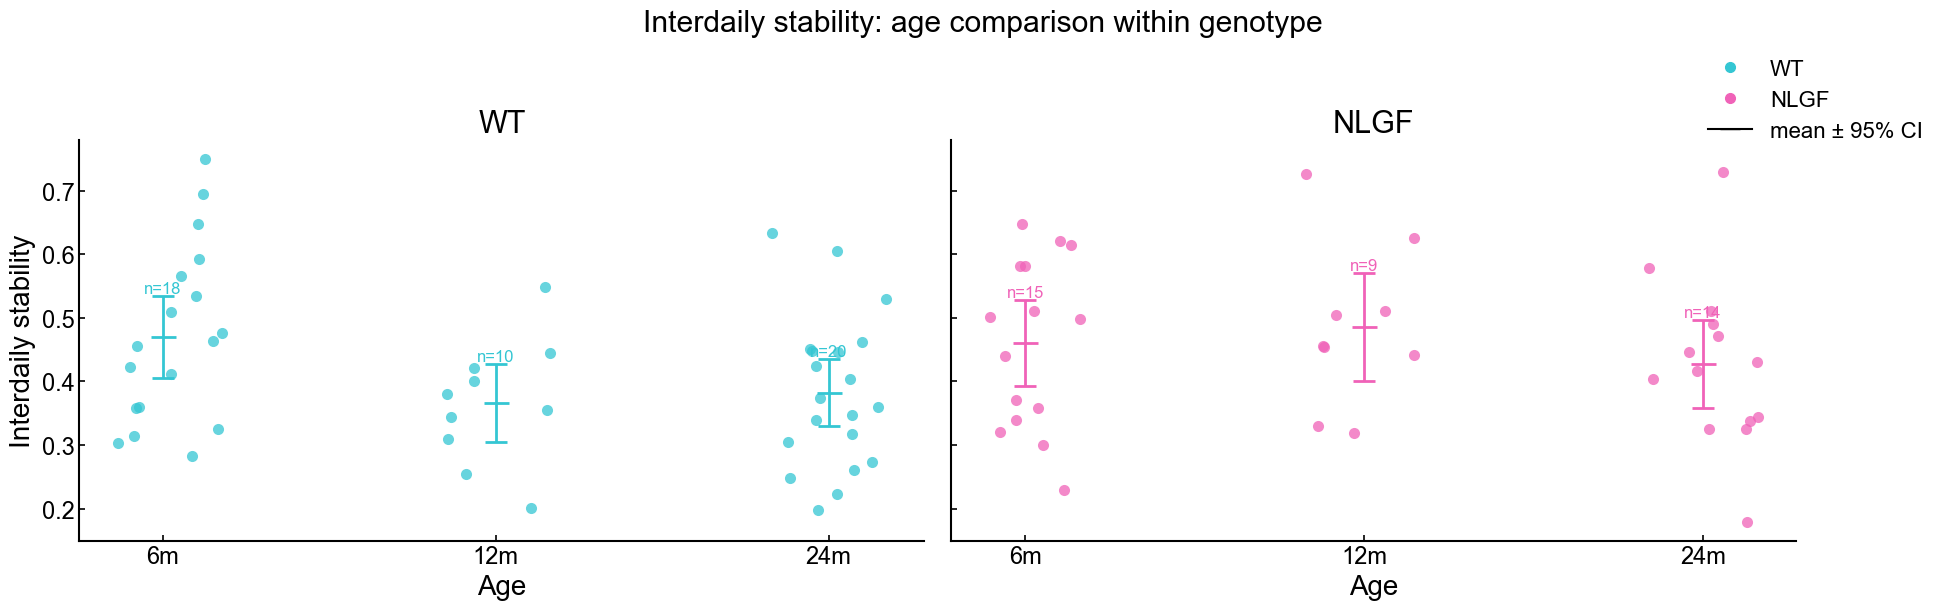

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Interdaily stability,WT,6m,12m,18,10,0.470227,0.365833,2.308712,0.029794,0.089382,ns,Welch t-test
1,Interdaily stability,WT,6m,24m,18,20,0.470227,0.382466,2.070491,0.046102,0.092204,ns,Welch t-test
2,Interdaily stability,WT,12m,24m,10,20,0.365833,0.382466,-0.404282,0.689964,0.689964,ns,Welch t-test
3,Interdaily stability,NLGF,6m,12m,15,9,0.460838,0.485450,-0.444615,0.662062,1.000000,ns,Welch t-test
4,Interdaily stability,NLGF,6m,24m,15,14,0.460838,0.427815,0.669076,0.509144,1.000000,ns,Welch t-test
5,Interdaily stability,NLGF,12m,24m,9,14,0.485450,0.427815,1.034355,0.315118,0.945354,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_RA_age_comparison_within_genotype.png


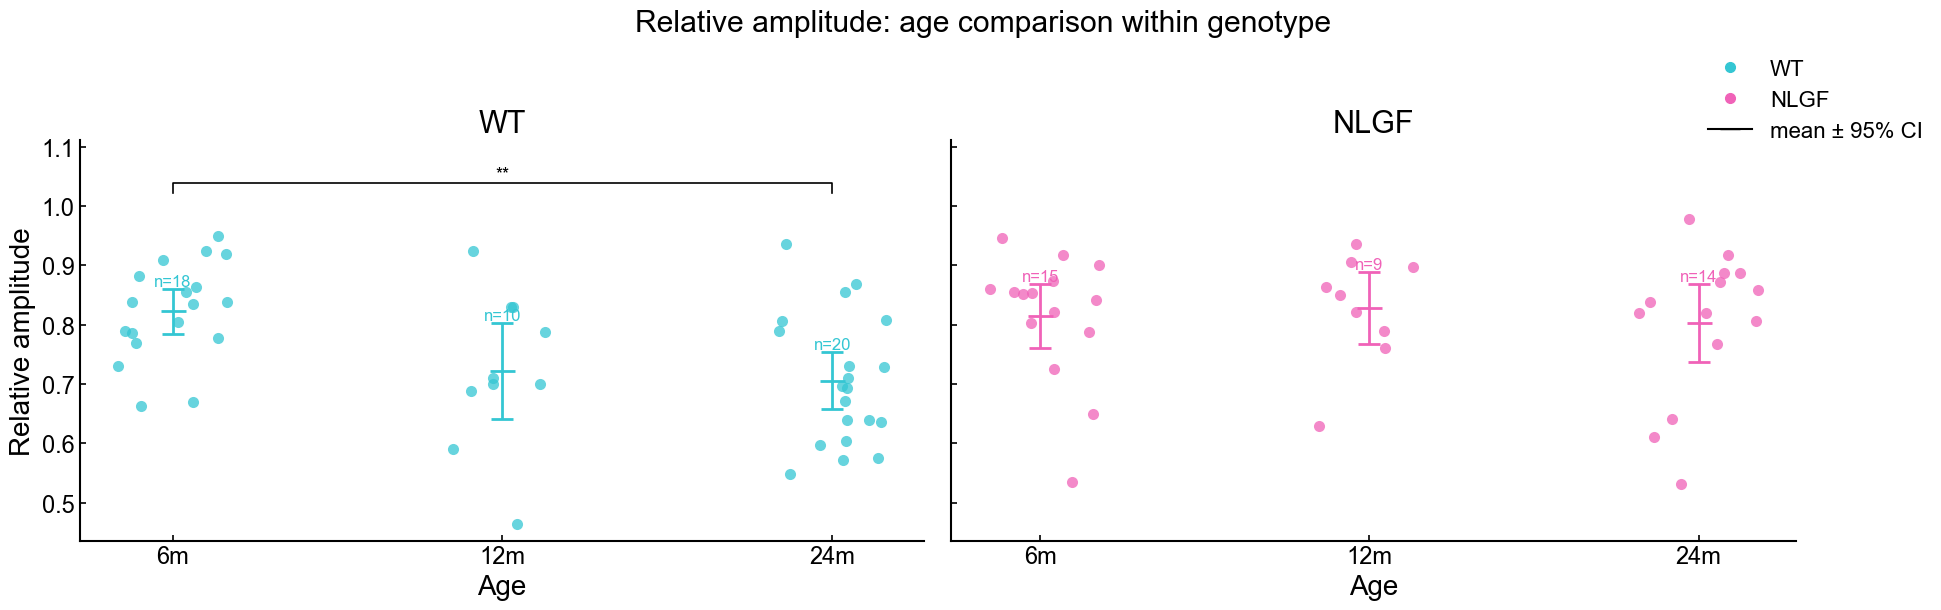

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Relative amplitude,WT,6m,12m,18,10,0.822382,0.722228,2.190696,0.047164,0.094328,ns,Welch t-test
1,Relative amplitude,WT,6m,24m,18,20,0.822382,0.705070,3.748793,0.000642,0.001925,**,Welch t-test
2,Relative amplitude,WT,12m,24m,10,20,0.722228,0.705070,0.356901,0.725973,0.725973,ns,Welch t-test
3,Relative amplitude,NLGF,6m,12m,15,9,0.814651,0.827956,-0.319649,0.752745,1.000000,ns,Welch t-test
4,Relative amplitude,NLGF,6m,24m,15,14,0.814651,0.802586,0.277134,0.783900,1.000000,ns,Welch t-test
5,Relative amplitude,NLGF,12m,24m,9,14,0.827956,0.802586,0.553562,0.585884,1.000000,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_M10_age_comparison_within_genotype.png


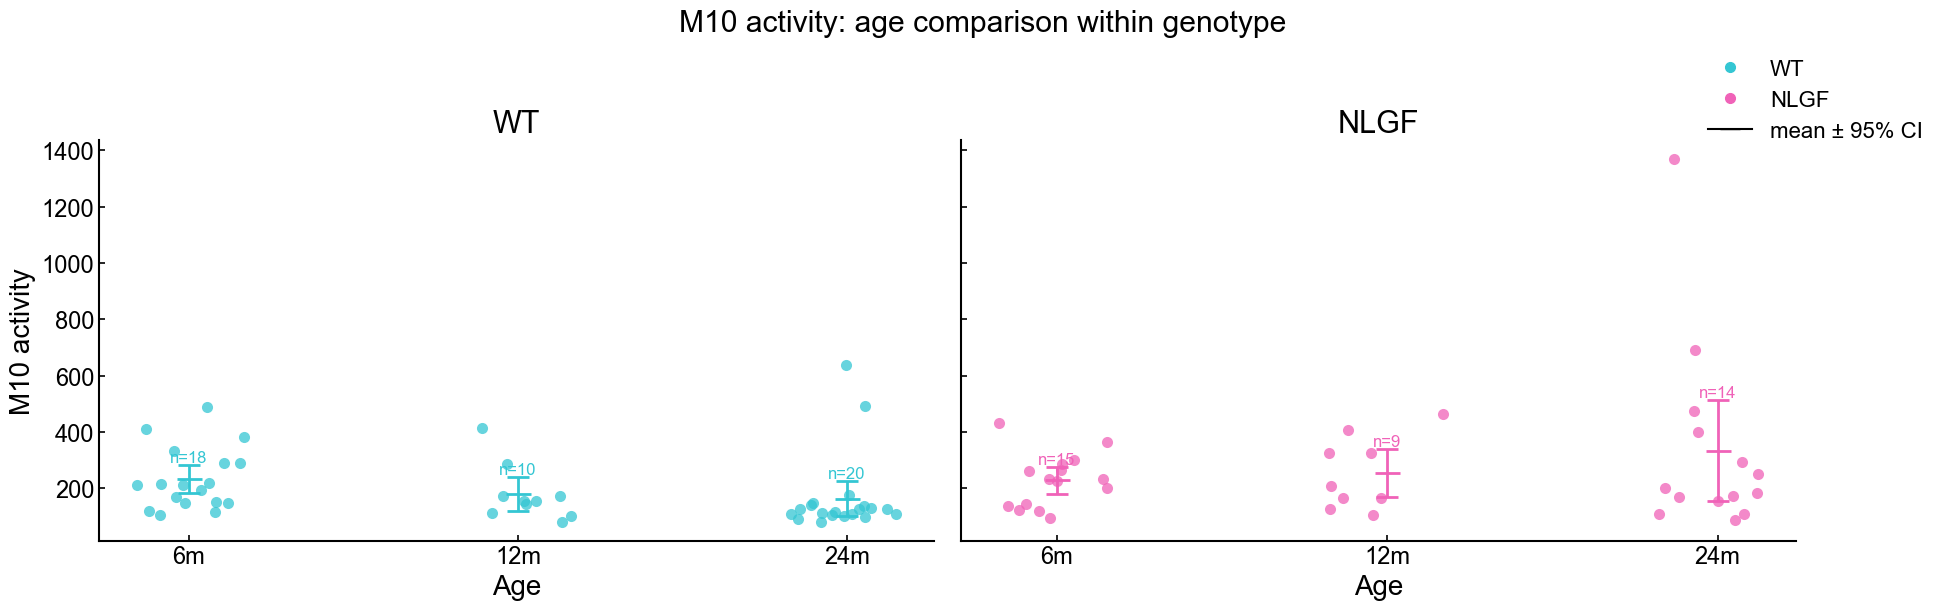

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,M10 activity,WT,6m,12m,18,10,233.650066,180.162723,1.315120,0.203051,0.406102,ns,Welch t-test
1,M10 activity,WT,6m,24m,18,20,233.650066,164.157826,1.704723,0.097028,0.291084,ns,Welch t-test
2,M10 activity,WT,12m,24m,10,20,180.162723,164.157826,0.360049,0.721896,0.721896,ns,Welch t-test
3,M10 activity,NLGF,6m,12m,15,9,228.886358,255.110385,-0.528957,0.605588,0.893038,ns,Welch t-test
4,M10 activity,NLGF,6m,24m,15,14,228.886358,333.723322,-1.108175,0.285386,0.856157,ns,Welch t-test
5,M10 activity,NLGF,12m,24m,9,14,255.110385,333.723322,-0.778294,0.446519,0.893038,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/circadian_L5_age_comparison_within_genotype.png


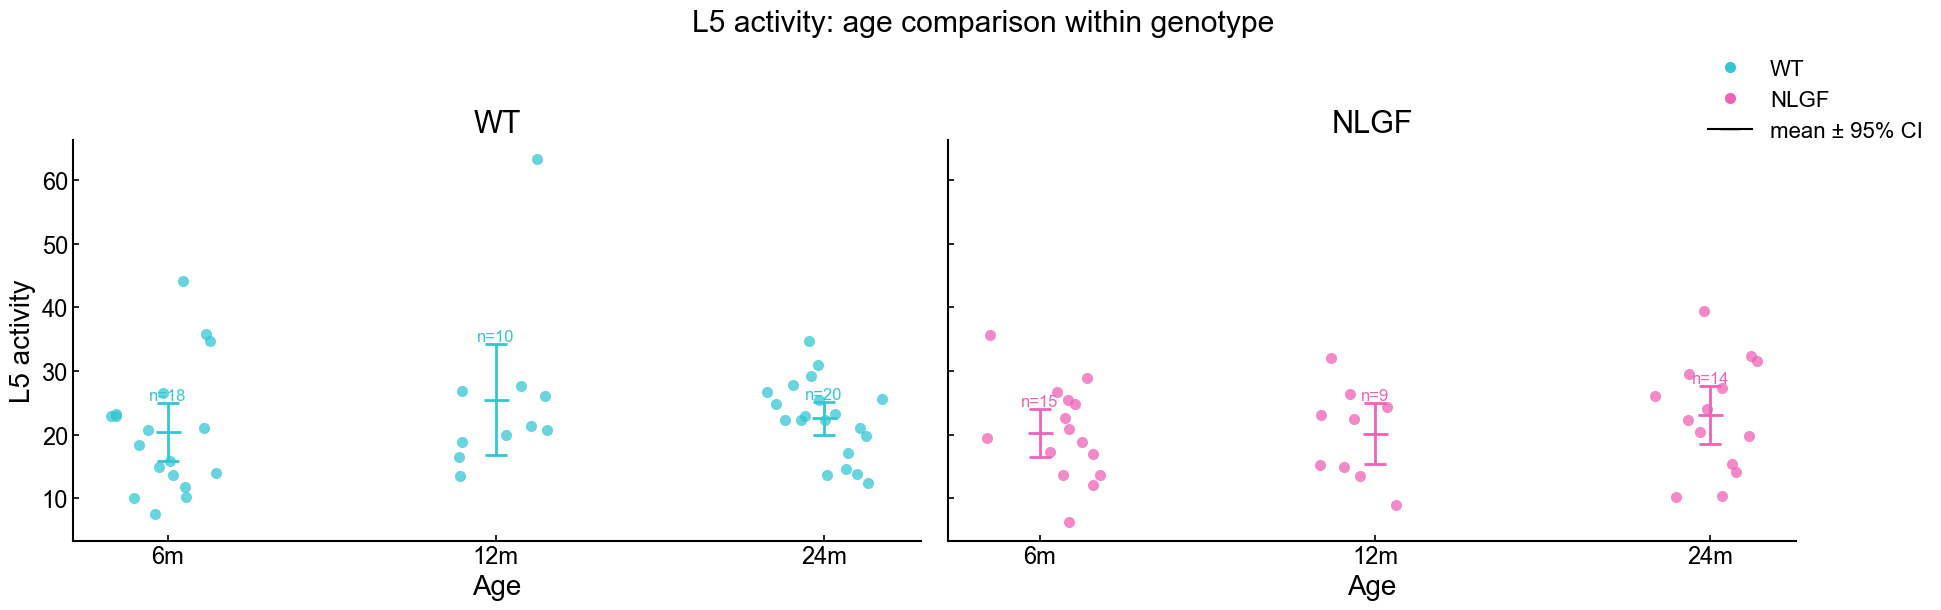

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,L5 activity,WT,6m,12m,18,10,20.464021,25.471612,-0.997542,0.335366,1.0,ns,Welch t-test
1,L5 activity,WT,6m,24m,18,20,20.464021,22.535857,-0.769841,0.447948,1.0,ns,Welch t-test
2,L5 activity,WT,12m,24m,10,20,25.471612,22.535857,0.631775,0.540811,1.0,ns,Welch t-test
3,L5 activity,NLGF,6m,12m,15,9,20.206083,20.112601,0.030059,0.976365,1.0,ns,Welch t-test
4,L5 activity,NLGF,6m,24m,15,14,20.206083,23.053880,-0.942923,0.354491,1.0,ns,Welch t-test
5,L5 activity,NLGF,12m,24m,9,14,20.112601,23.053880,-0.872694,0.393548,1.0,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_count_age_comparison_within_genotype.png


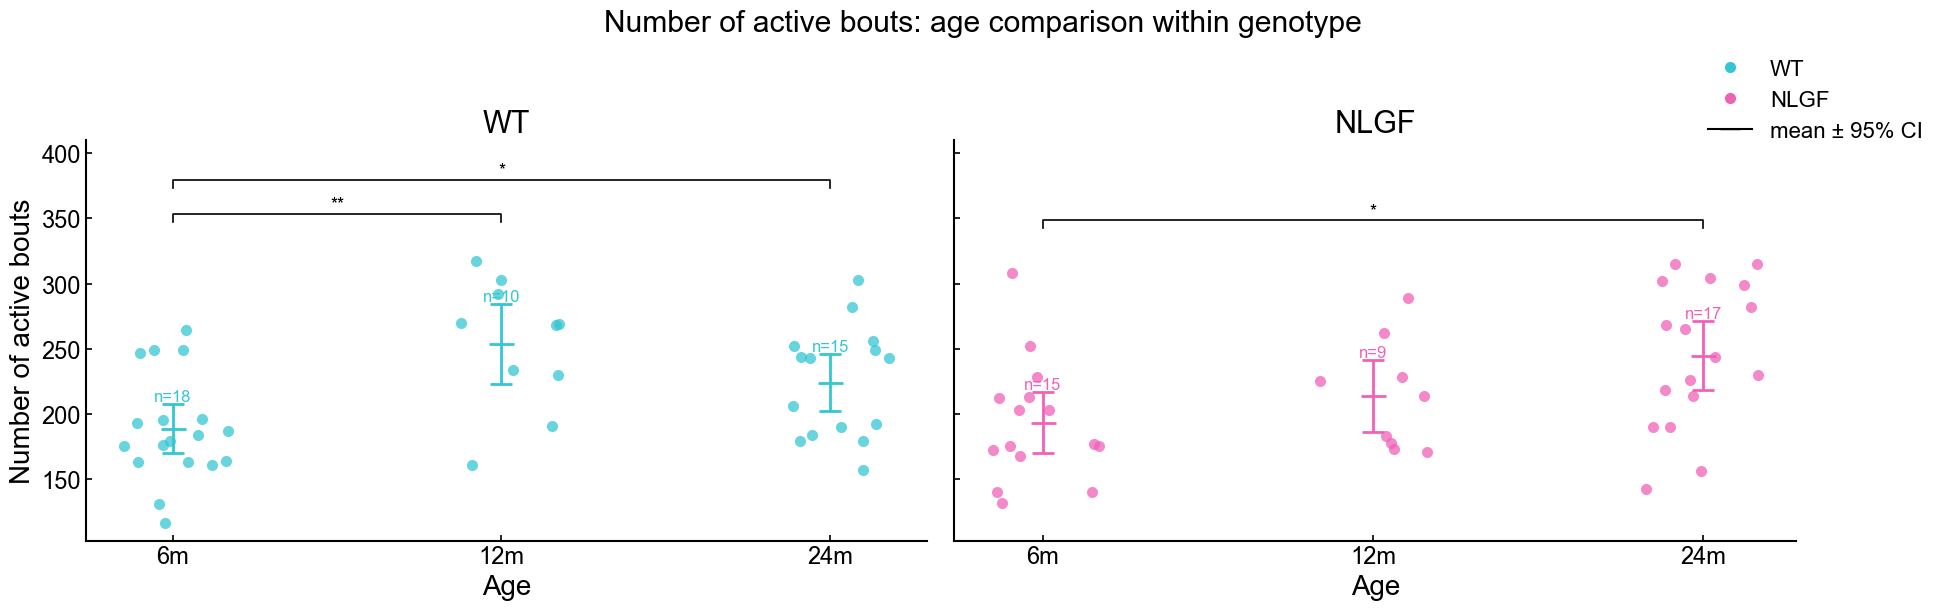

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Number of active bouts,WT,6m,12m,18,10,188.444444,253.500000,-3.540526,0.002754,0.008261,**,Welch t-test
1,Number of active bouts,WT,6m,24m,18,15,188.444444,223.933333,-2.419568,0.021965,0.043930,*,Welch t-test
2,Number of active bouts,WT,12m,24m,10,15,253.500000,223.933333,1.540783,0.141301,0.141301,ns,Welch t-test
3,Number of active bouts,NLGF,6m,12m,15,9,193.200000,213.666667,-1.112088,0.280398,0.280398,ns,Welch t-test
4,Number of active bouts,NLGF,6m,24m,15,17,193.200000,244.705882,-2.868146,0.007494,0.022483,*,Welch t-test
5,Number of active bouts,NLGF,12m,24m,9,17,213.666667,244.705882,-1.605937,0.123439,0.246879,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_total_age_comparison_within_genotype.png


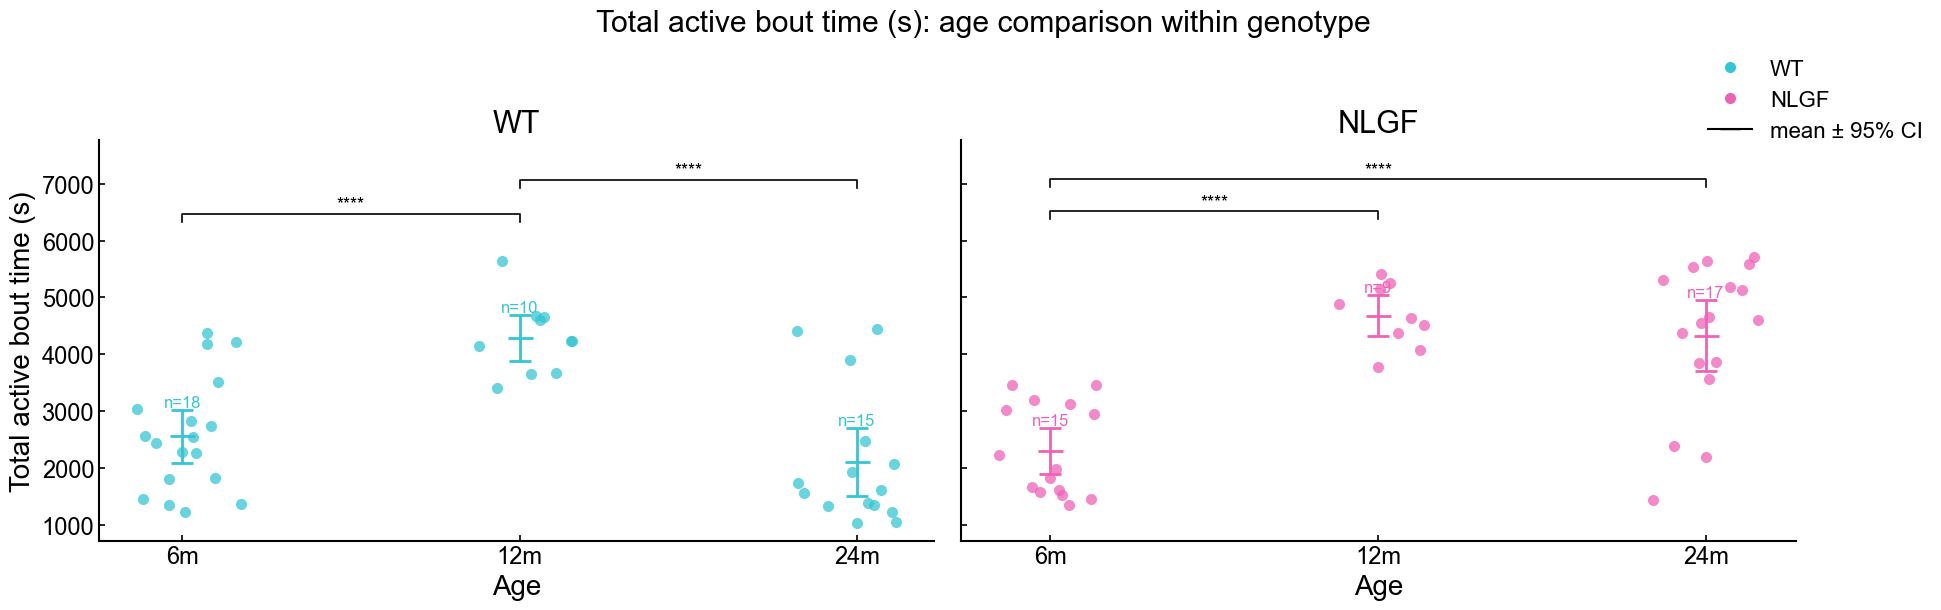

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Total active bout time (s),WT,6m,12m,18,10,2557.944444,4291.200000,-5.535415,9.088177e-06,1.817635e-05,****,Welch t-test
1,Total active bout time (s),WT,6m,24m,18,15,2557.944444,2099.866667,1.184985,2.461114e-01,2.461114e-01,ns,Welch t-test
2,Total active bout time (s),WT,12m,24m,10,15,4291.200000,2099.866667,5.954806,5.048615e-06,1.514584e-05,****,Welch t-test
3,Total active bout time (s),NLGF,6m,12m,15,9,2295.466667,4674.666667,-8.573246,2.257965e-08,6.773896e-08,****,Welch t-test
4,Total active bout time (s),NLGF,6m,24m,15,17,2295.466667,4329.823529,-5.393788,1.050754e-05,2.101508e-05,****,Welch t-test
5,Total active bout time (s),NLGF,12m,24m,9,17,4674.666667,4329.823529,0.944849,3.544083e-01,3.544083e-01,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_mean_age_comparison_within_genotype.png


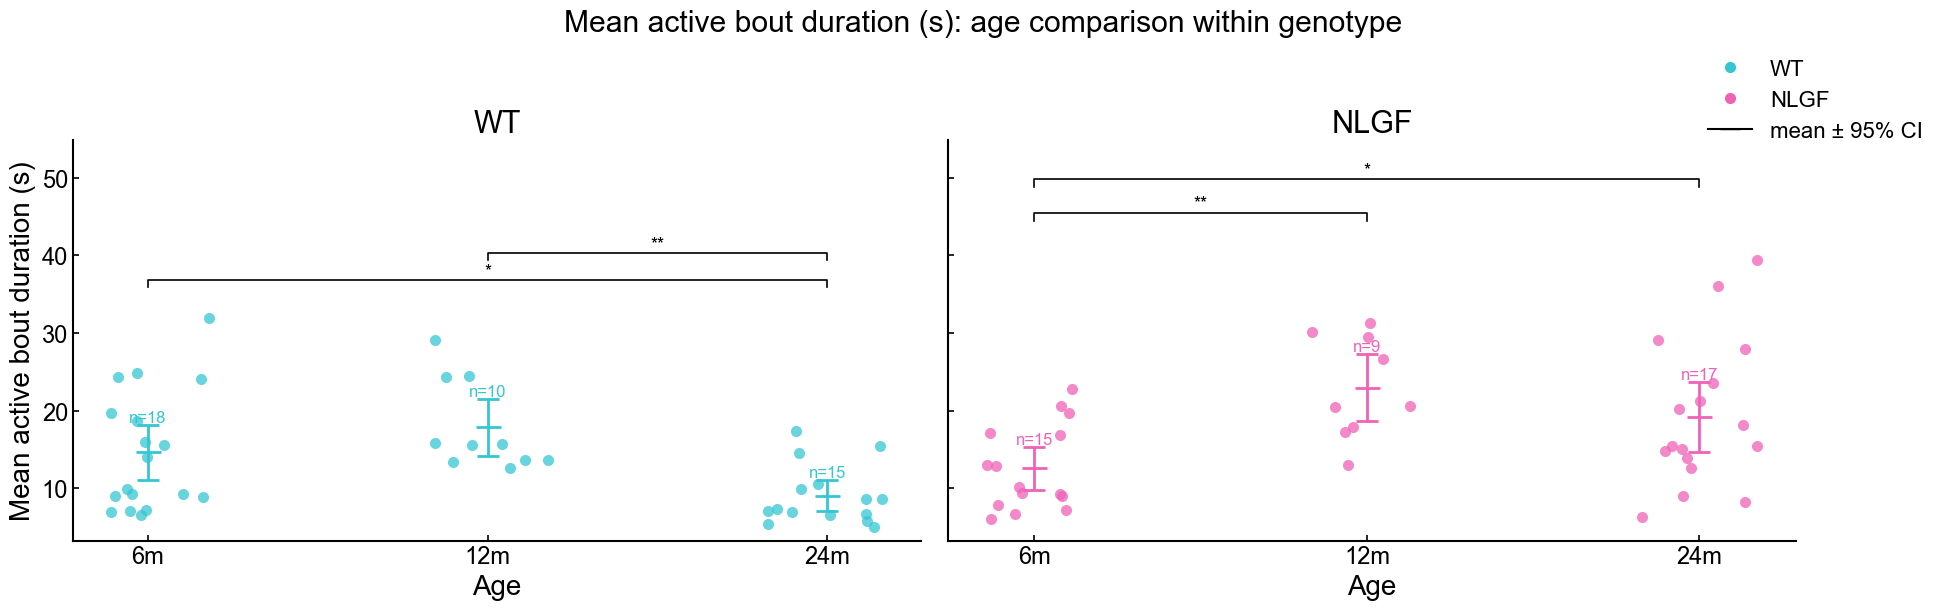

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Mean active bout duration (s),WT,6m,12m,18,10,14.627958,17.838017,-1.237316,0.228305,0.228305,ns,Welch t-test
1,Mean active bout duration (s),WT,6m,24m,18,15,14.627958,9.076732,2.680839,0.012620,0.025240,*,Welch t-test
2,Mean active bout duration (s),WT,12m,24m,10,15,17.838017,9.076732,4.174239,0.000916,0.002748,**,Welch t-test
3,Mean active bout duration (s),NLGF,6m,12m,15,9,12.578271,22.978837,-3.974306,0.001265,0.003796,**,Welch t-test
4,Mean active bout duration (s),NLGF,6m,24m,15,17,12.578271,19.213575,-2.462588,0.020639,0.041277,*,Welch t-test
5,Mean active bout duration (s),NLGF,12m,24m,9,17,22.978837,19.213575,1.188858,0.247230,0.247230,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/active_bouts_median_age_comparison_within_genotype.png


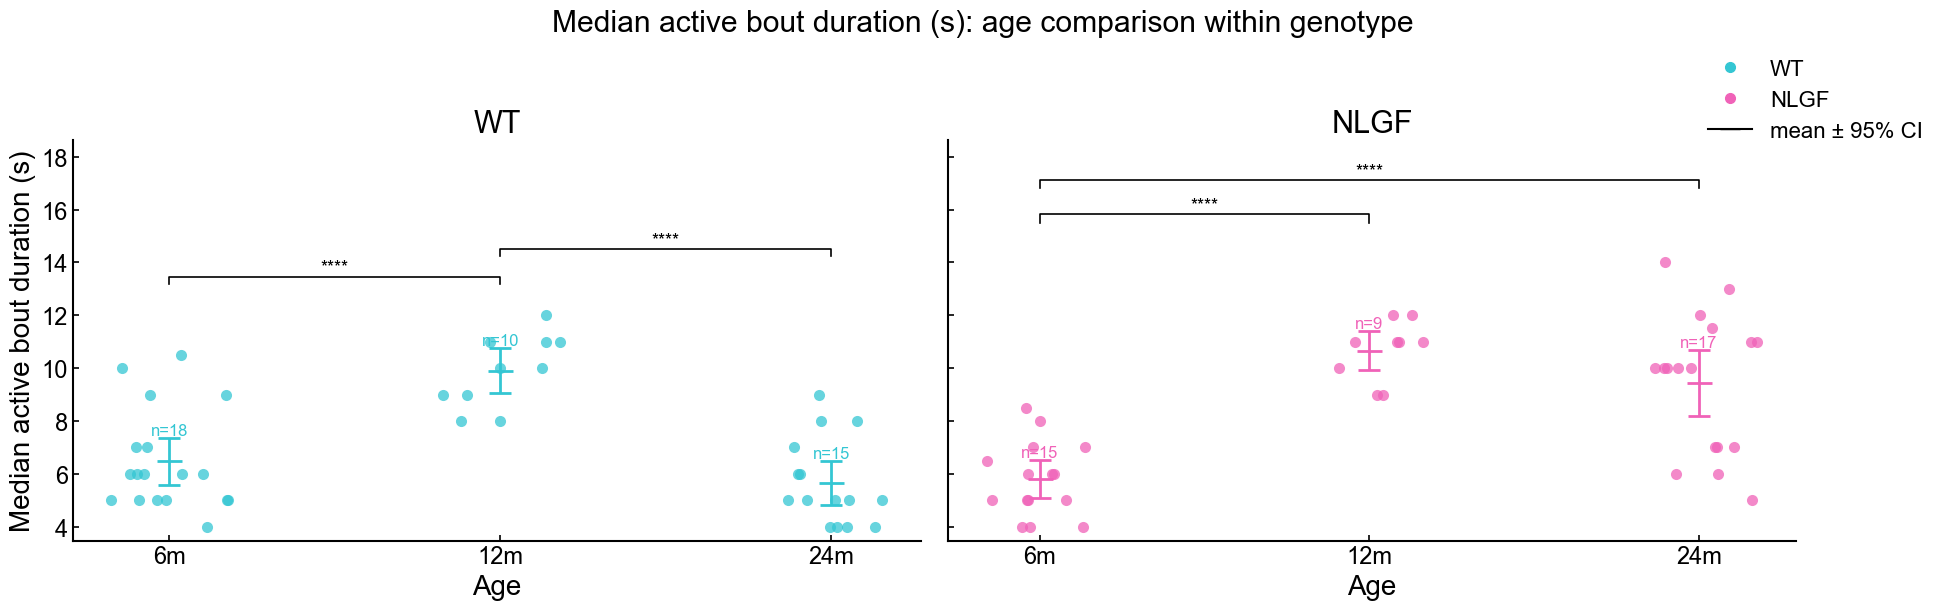

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Median active bout duration (s),WT,6m,12m,18,10,6.472222,9.900000,-5.480666,1.221691e-05,2.443383e-05,****,Welch t-test
1,Median active bout duration (s),WT,6m,24m,18,15,6.472222,5.666667,1.304787,2.015771e-01,2.015771e-01,ns,Welch t-test
2,Median active bout duration (s),WT,12m,24m,10,15,9.900000,5.666667,7.001737,5.496637e-07,1.648991e-06,****,Welch t-test
3,Median active bout duration (s),NLGF,6m,12m,15,9,5.800000,10.666667,-9.335767,9.439087e-09,2.831726e-08,****,Welch t-test
4,Median active bout duration (s),NLGF,6m,24m,15,17,5.800000,9.441176,-4.934924,4.402665e-05,8.805329e-05,****,Welch t-test
5,Median active bout duration (s),NLGF,12m,24m,9,17,10.666667,9.441176,1.651794,1.119847e-01,1.119847e-01,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_count_age_comparison_within_genotype.png


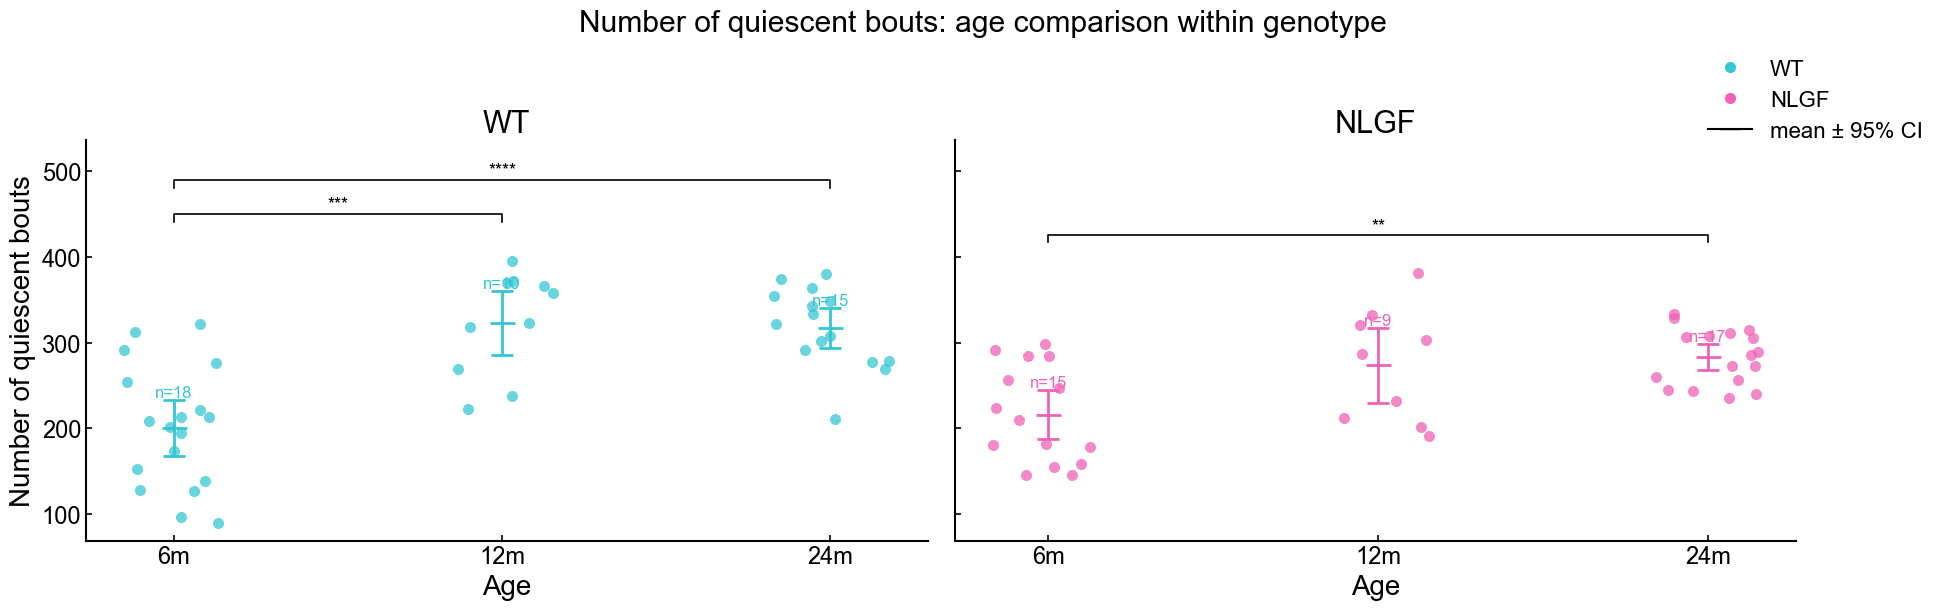

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Number of quiescent bouts,WT,6m,12m,18,10,200.777778,323.200000,-4.807631,0.000090,0.000180,***,Welch t-test
1,Number of quiescent bouts,WT,6m,24m,18,15,200.777778,317.266667,-5.640397,0.000004,0.000012,****,Welch t-test
2,Number of quiescent bouts,WT,12m,24m,10,15,323.200000,317.266667,0.262171,0.796551,0.796551,ns,Welch t-test
3,Number of quiescent bouts,NLGF,6m,12m,15,9,216.000000,273.555556,-2.151719,0.048292,0.096583,ns,Welch t-test
4,Number of quiescent bouts,NLGF,6m,24m,15,17,216.000000,283.058824,-4.019295,0.000593,0.001778,**,Welch t-test
5,Number of quiescent bouts,NLGF,12m,24m,9,17,273.555556,283.058824,-0.401291,0.696623,0.696623,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_total_age_comparison_within_genotype.png


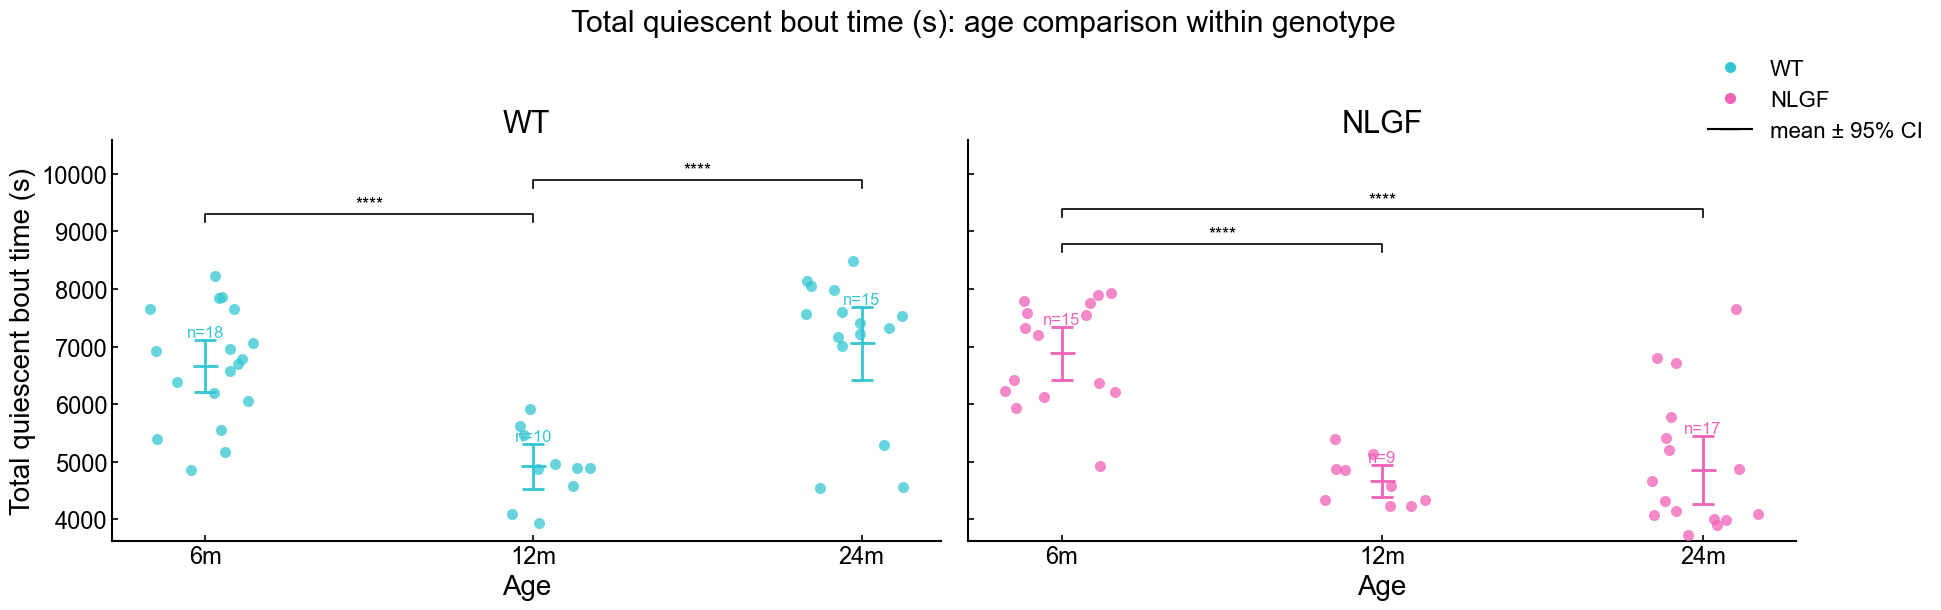

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Total quiescent bout time (s),WT,6m,12m,18,10,6659.055556,4919.400000,5.685299,6.078239e-06,1.823472e-05,****,Welch t-test
1,Total quiescent bout time (s),WT,6m,24m,18,15,6659.055556,7056.866667,-1.000971,3.258974e-01,3.258974e-01,ns,Welch t-test
2,Total quiescent bout time (s),WT,12m,24m,10,15,4919.400000,7056.866667,-5.648184,1.156939e-05,2.313877e-05,****,Welch t-test
3,Total quiescent bout time (s),NLGF,6m,12m,15,9,6885.266667,4666.333333,8.097009,6.528806e-08,1.958642e-07,****,Welch t-test
4,Total quiescent bout time (s),NLGF,6m,24m,15,17,6885.266667,4860.411765,5.310804,1.056889e-05,2.113778e-05,****,Welch t-test
5,Total quiescent bout time (s),NLGF,12m,24m,9,17,4666.333333,4860.411765,-0.585012,5.645669e-01,5.645669e-01,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_mean_age_comparison_within_genotype.png


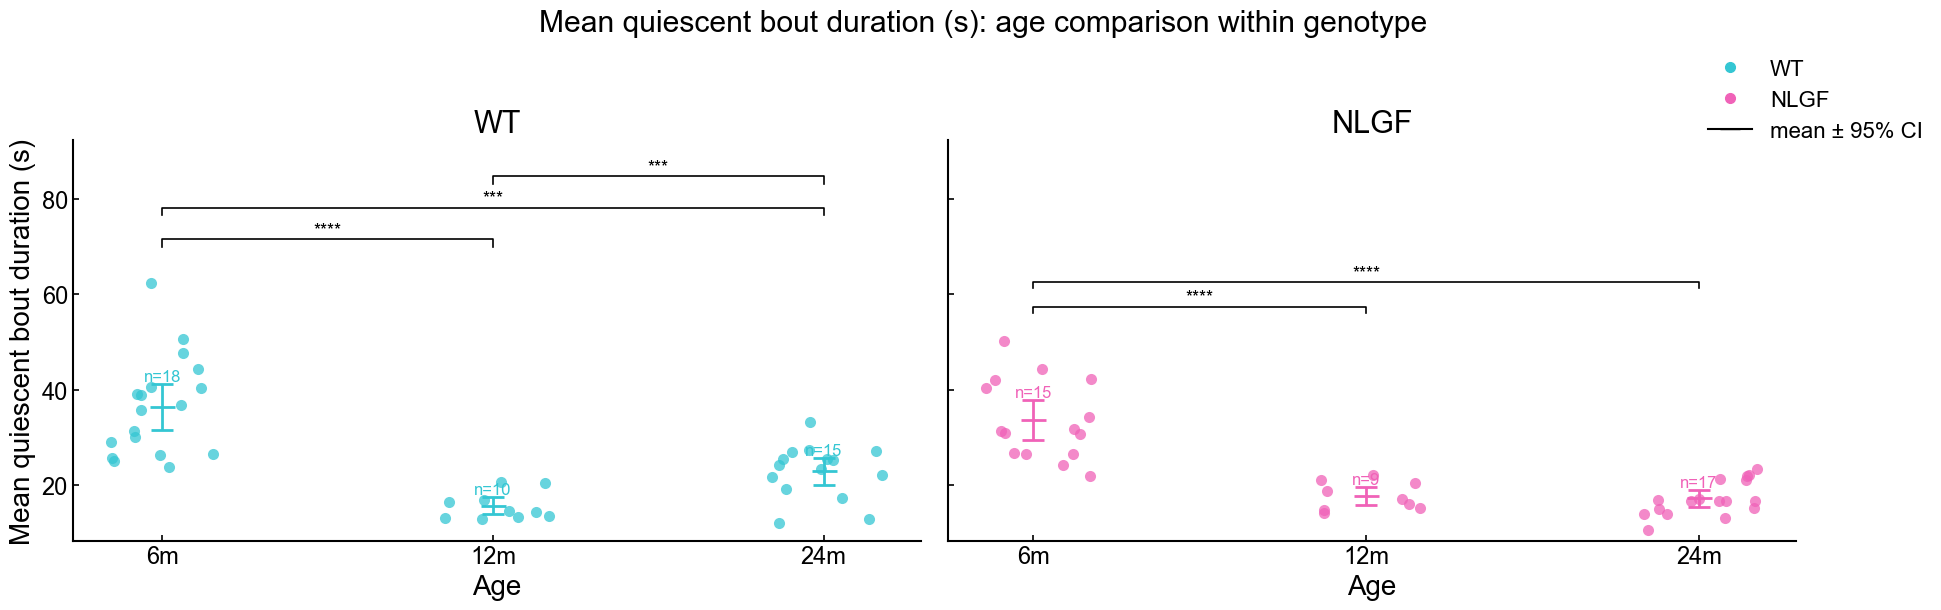

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Mean quiescent bout duration (s),WT,6m,12m,18,10,36.332400,15.601615,7.895324,9.037709e-08,2.711313e-07,****,Welch t-test
1,Mean quiescent bout duration (s),WT,6m,24m,18,15,36.332400,22.863393,4.709297,6.615448e-05,1.323090e-04,***,Welch t-test
2,Mean quiescent bout duration (s),WT,12m,24m,10,15,15.601615,22.863393,-4.192695,3.777516e-04,3.777516e-04,***,Welch t-test
3,Mean quiescent bout duration (s),NLGF,6m,12m,15,9,33.604830,17.685160,6.678381,2.168304e-06,4.336608e-06,****,Welch t-test
4,Mean quiescent bout duration (s),NLGF,6m,24m,15,17,33.604830,17.160416,7.041961,1.238180e-06,3.714539e-06,****,Welch t-test
5,Mean quiescent bout duration (s),NLGF,12m,24m,9,17,17.685160,17.160416,0.396942,6.957625e-01,6.957625e-01,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/figures/quiescent_bouts_median_age_comparison_within_genotype.png


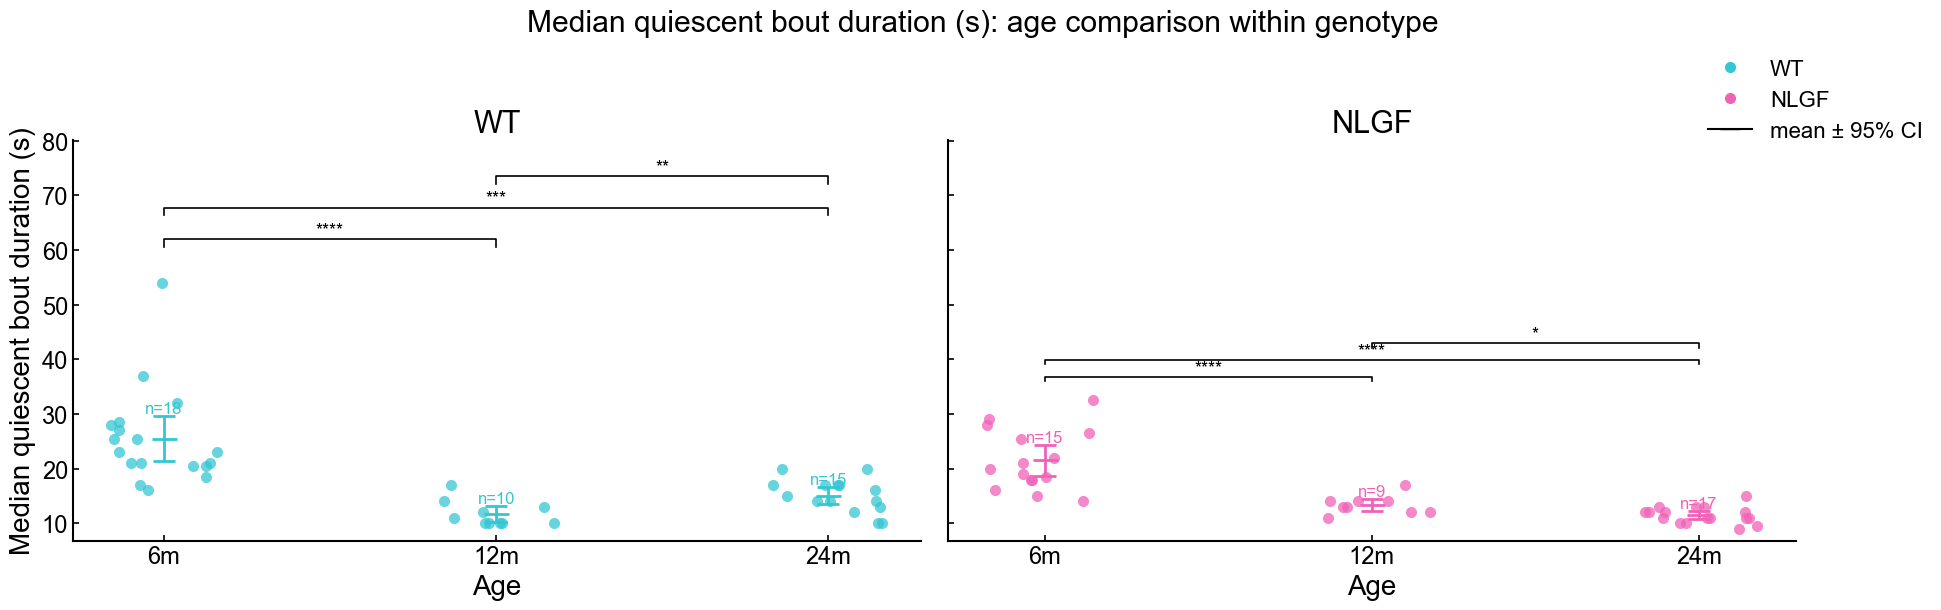

,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Median quiescent bout duration (s),WT,6m,12m,18,10,25.500000,11.700000,6.213642,0.000004,0.000011,****,Welch t-test
1,Median quiescent bout duration (s),WT,6m,24m,18,15,25.500000,15.066667,4.661813,0.000123,0.000247,***,Welch t-test
2,Median quiescent bout duration (s),WT,12m,24m,10,15,11.700000,15.066667,-3.086630,0.005308,0.005308,**,Welch t-test
3,Median quiescent bout duration (s),NLGF,6m,12m,15,9,21.533333,13.333333,5.305020,0.000048,0.000095,****,Welch t-test
4,Median quiescent bout duration (s),NLGF,6m,24m,15,17,21.533333,11.500000,6.782646,0.000005,0.000014,****,Welch t-test
5,Median quiescent bout duration (s),NLGF,12m,24m,9,17,13.333333,11.500000,2.686549,0.017319,0.017319,*,Welch t-test


In [15]:

# Circadian metrics: age comparison within genotype
for metric, label in CIRCADIAN_METRICS.items():
    plot_metric_by_genotype_age(
        circadian_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"circadian_{metric}_age_comparison_within_genotype.png",
    )

# Active bout metrics: age comparison within genotype
for metric, label in ACTIVE_BOUT_METRICS.items():
    plot_metric_by_genotype_age(
        active_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"active_bouts_{metric}_age_comparison_within_genotype.png",
    )

# Quiescent bout metrics: age comparison within genotype
for metric, label in QUIESCENT_BOUT_METRICS.items():
    plot_metric_by_genotype_age(
        quiescent_master,
        metric=metric,
        ylabel=label,
        title=label,
        save_name=f"quiescent_bouts_{metric}_age_comparison_within_genotype.png",
    )


### 12.2 Save age-comparison statistics

In [16]:

if len(AGE_STATS_RESULTS) > 0:
    movement_age_stats_all = pd.concat(AGE_STATS_RESULTS, ignore_index=True)
    movement_age_stats_all.to_csv(
        MASTER_OUTPUT / "movement_age_comparison_statistics_with_stars.csv",
        index=False
    )
    display(movement_age_stats_all.head())
    print("Saved:", MASTER_OUTPUT / "movement_age_comparison_statistics_with_stars.csv")
else:
    print("No age-comparison statistical results collected yet. Run the age-comparison plotting cells first.")


,Metric,Genotype,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,test,p_holm,stars
0,Diurnality Index,WT,6m,12m,18,10,-0.551389,-0.465302,-1.472577,0.155861,Welch t-test,0.311722,ns
1,Diurnality Index,WT,6m,24m,18,20,-0.551389,-0.391192,-2.801191,0.008161,Welch t-test,0.024483,*
2,Diurnality Index,WT,12m,24m,10,20,-0.465302,-0.391192,-1.194134,0.244218,Welch t-test,0.311722,ns
3,Diurnality Index,NLGF,6m,12m,15,9,-0.538580,-0.528445,-0.129223,0.898454,Welch t-test,0.965370,ns
4,Diurnality Index,NLGF,6m,24m,15,14,-0.538580,-0.453689,-1.009869,0.321790,Welch t-test,0.965370,ns


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/movement_age_comparison_statistics_with_stars.csv


## 12. Save statistical results

All pairwise Welch t-test results produced by the plotting functions are combined and saved here. Holm-adjusted p-values and star labels are included.


In [17]:
if len(STATS_RESULTS) > 0:
    movement_stats_all = pd.concat(STATS_RESULTS, ignore_index=True)
    movement_stats_all.to_csv(MASTER_OUTPUT / "movement_pairwise_statistics_with_stars.csv", index=False)
    display(movement_stats_all.head())
    print("Saved:", MASTER_OUTPUT / "movement_pairwise_statistics_with_stars.csv")
else:
    print("No statistical results collected yet. Run the plotting cells first.")


,Metric,Age,Group 1,Group 2,n1,n2,mean1,mean2,statistic,p_raw,p_holm,stars,test
0,Diurnality Index,6m,WT,NLGF,18,15,-0.551389,-0.538580,143.000000,0.786266,0.786266,ns,Mann-Whitney U
1,Diurnality Index,12m,WT,NLGF,10,9,-0.465302,-0.528445,0.884341,0.389767,0.389767,ns,Welch t-test
2,Diurnality Index,24m,WT,NLGF,20,14,-0.391192,-0.453689,0.815952,0.422476,0.422476,ns,Welch t-test
3,Intradaily variability,6m,WT,NLGF,18,15,0.599590,0.534048,1.193720,0.241704,0.241704,ns,Welch t-test
4,Intradaily variability,12m,WT,NLGF,10,9,0.759691,0.623052,1.439698,0.170689,0.170689,ns,Welch t-test


Saved: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/movement_pairwise_statistics_with_stars.csv


## 12. Summary tables

These tables give group-level means and SEMs for export/checking.

In [18]:
def summary_table(data, metrics):
    rows = []
    for metric in metrics:
        if metric not in data.columns:
            continue
        temp = data.copy()
        temp[metric] = pd.to_numeric(temp[metric], errors="coerce")
        out = (
            temp
            .groupby(["Age", "Genotype"], as_index=False)
            .agg(
                mean=(metric, "mean"),
                sem=(metric, sem),
                n=(metric, "count")
            )
        )
        out.insert(0, "Metric", metric)
        rows.append(out)

    return pd.concat(rows, ignore_index=True)

circadian_summary = summary_table(circadian_master, list(CIRCADIAN_METRICS.keys()))
active_summary = summary_table(active_master, list(ACTIVE_BOUT_METRICS.keys()))
quiescent_summary = summary_table(quiescent_master, list(QUIESCENT_BOUT_METRICS.keys()))

circadian_summary.to_csv(MASTER_OUTPUT / "summary_circadian_metrics.csv", index=False)
active_summary.to_csv(MASTER_OUTPUT / "summary_active_bouts.csv", index=False)
quiescent_summary.to_csv(MASTER_OUTPUT / "summary_quiescent_bouts.csv", index=False)

circadian_summary.head()

,Metric,Age,Genotype,mean,sem,n
0,DI,12m,APP1-em1BDS,-0.514000,0.040156,10
1,DI,12m,NLGF,-0.528445,0.055668,9
2,DI,12m,WT,-0.465302,0.044714,10
3,DI,24m,APP1-em1BDS,-0.592096,0.145992,2
4,DI,24m,NLF,-0.295837,0.068979,7


# FINAL statistical analysis 
This section supersedes earlier exploratory statistics. It performs normality checks, chooses parametric/non-parametric tests as appropriate, and reports **raw p-values only**.


In [ ]:
# ==========================================================
# FINAL STATISTICS HELPERS 
# ==========================================================
# IMPORTANT:
# - Independent WT vs NLGF comparisons: Shapiro-Wilk per group ->
#   Welch two-tailed t-test if both groups pass, otherwise Mann-Whitney U.
# - Paired comparisons: Shapiro-Wilk on paired differences ->
#   paired t-test if normal, otherwise Wilcoxon signed-rank.
# - Age x Genotype for one-value-per-mouse outcomes: ordinary two-way ANOVA
#   using a Type III ANOVA table.
# - Repeated observations within the same mouse (period/ITI/phase/side/time):
#   mixed-effects repeated-measures model with mouse as a random intercept.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, ttest_rel, wilcoxon, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

ALPHA_FINAL = 0.05


def _final_clean(x):
    return pd.to_numeric(pd.Series(x), errors='coerce').dropna().to_numpy(dtype=float)


def _final_shapiro(x):
    x = _final_clean(x)
    if len(x) < 3:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': 'Shapiro-Wilk requires at least 3 observations'}
    try:
        W, p = shapiro(x)
        return {'n': len(x), 'W': float(W), 'p_value': float(p),
                'normal': bool(p > ALPHA_FINAL), 'note': ''}
    except Exception as exc:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': str(exc)}


def _final_sig(p):
    if pd.isna(p): return 'NA'
    if p < 0.0001: return '****'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'


def final_independent_test(df, value_col, group_col='Genotype', g1='WT', g2='NLGF', context=None):
    context = {} if context is None else dict(context)
    x = _final_clean(df.loc[df[group_col].eq(g1), value_col])
    y = _final_clean(df.loc[df[group_col].eq(g2), value_col])
    nx = _final_shapiro(x); ny = _final_shapiro(y)
    row = {**context, 'value_col': value_col, 'group_1': g1, 'group_2': g2,
           'n_1': len(x), 'n_2': len(y),
           'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'median_1': np.median(x) if len(x) else np.nan,
           'median_2': np.median(y) if len(y) else np.nan,
           'shapiro_1_W': nx['W'], 'shapiro_1_p': nx['p_value'],
           'shapiro_2_W': ny['W'], 'shapiro_2_p': ny['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(x) < 2 or len(y) < 2:
        row['note'] = 'Fewer than 2 observations in at least one group'
        row['stars'] = 'NA'; return row
    if nx['normal'] is True and ny['normal'] is True:
        stat, p = ttest_ind(x, y, equal_var=False, alternative='two-sided')
        test = 'Welch two-tailed unpaired t-test'
    else:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        test = 'Mann-Whitney U'
    row.update(test=test, statistic=float(stat), p_value=float(p), stars=_final_sig(p), note='')
    return row


def final_paired_test(df, subject_col, condition_col, value_col, c1, c2, context=None):
    context = {} if context is None else dict(context)
    wide = (df[df[condition_col].isin([c1, c2])]
            .pivot_table(index=subject_col, columns=condition_col, values=value_col, aggfunc='mean'))
    if c1 not in wide.columns or c2 not in wide.columns:
        return {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
                'n_pairs': 0, 'test': 'not tested', 'statistic': np.nan,
                'p_value': np.nan, 'stars': 'NA', 'note': 'Required condition missing'}
    wide = wide.dropna(subset=[c1, c2])
    x = pd.to_numeric(wide[c1], errors='coerce').to_numpy(float)
    y = pd.to_numeric(wide[c2], errors='coerce').to_numpy(float)
    d = y - x
    nd = _final_shapiro(d)
    row = {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
           'n_pairs': len(wide), 'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'mean_change_2_minus_1': np.mean(d) if len(d) else np.nan,
           'difference_shapiro_W': nd['W'], 'difference_shapiro_p': nd['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(wide) < 2:
        row['stars']='NA'; row['note']='Fewer than 2 complete pairs'; return row
    if nd['normal'] is True:
        stat, p = ttest_rel(y, x, alternative='two-sided')
        test = 'Paired two-tailed t-test'
    else:
        try:
            stat, p = wilcoxon(y, x, alternative='two-sided', zero_method='wilcox')
            test = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p, test = np.nan, np.nan, 'Wilcoxon unavailable'
    row.update(test=test, statistic=float(stat) if np.isfinite(stat) else np.nan,
               p_value=float(p) if np.isfinite(p) else np.nan,
               stars=_final_sig(p), note='')
    return row


def final_normality_table(df, value_col, group_cols):
    rows=[]
    for keys, sub in df.groupby(group_cols, observed=True, dropna=False):
        if not isinstance(keys, tuple): keys=(keys,)
        r=_final_shapiro(sub[value_col])
        rows.append({**dict(zip(group_cols, keys)), 'value_col': value_col, **r})
    return pd.DataFrame(rows)


def final_two_way_anova(df, value_col, age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    d=df[[value_col, age_col, genotype_col]].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula = f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}'))"
    model = smf.ols(formula, data=d).fit()
    aov = anova_lm(model, typ=3).reset_index().rename(columns={'index':'Effect', 'PR(>F)':'p_value'})
    aov['stars']=aov['p_value'].apply(_final_sig)
    for k,v in context.items(): aov[k]=v
    resid = pd.DataFrame([{**context, 'value_col': value_col, 'analysis':'two-way ANOVA residuals', **_final_shapiro(model.resid)}])
    return aov, resid


def final_mixed_repeated(df, value_col, subject_col, repeated_col,
                         age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    cols=[value_col, subject_col, repeated_col, age_col, genotype_col]
    d=df[cols].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula=(f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}')) * C(Q('{repeated_col}'))")
    try:
        fit=smf.mixedlm(formula, d, groups=d[subject_col]).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
        ci=fit.conf_int()
        terms=[]
        for term,p in fit.pvalues.items():
            if term in ('Group Var','Intercept'): continue
            terms.append({**context, 'value_col':value_col, 'term':term,
                          'coefficient':fit.params.get(term,np.nan),
                          'SE':fit.bse.get(term,np.nan),
                          'CI_low':ci.loc[term,0] if term in ci.index else np.nan,
                          'CI_high':ci.loc[term,1] if term in ci.index else np.nan,
                          'p_value':p, 'stars':_final_sig(p),
                          'model':'Mixed-effects repeated-measures model (random intercept = mouse)'})
        residual=pd.DataFrame([{**context, 'value_col':value_col, 'analysis':'mixed-model residuals', **_final_shapiro(fit.resid)}])
        return pd.DataFrame(terms), residual
    except Exception as exc:
        return pd.DataFrame([{**context,'value_col':value_col,'term':'MODEL_FAILED','p_value':np.nan,'stars':'NA','note':str(exc)}]), pd.DataFrame()

# ==========================================================
# FINAL CIRCADIAN / BOUT STATISTICS
# ==========================================================
FINAL_STATS_DIR = MASTER_OUTPUT / 'FINAL_unadjusted_statistics'
FINAL_STATS_DIR.mkdir(exist_ok=True)

DATASETS = [
    ('circadian', circadian_master, CIRCADIAN_METRICS),
    ('active_bouts', active_master, ACTIVE_BOUT_METRICS),
    ('quiescent_bouts', quiescent_master, QUIESCENT_BOUT_METRICS),
]
normality=[]; pairwise=[]; aovs=[]; residuals=[]
for dataset_name, df, metrics in DATASETS:
    for metric,label in metrics.items():
        if metric not in df.columns: continue
        d=df[df['Genotype'].isin(['WT','NLGF']) & df['Age'].isin(['6m','12m','24m'])].copy()
        normality.append(final_normality_table(d,metric,['Age','Genotype']).assign(Dataset=dataset_name,Metric=metric,MetricLabel=label))
        for age in ['6m','12m','24m']:
            pairwise.append(final_independent_test(d[d['Age'].eq(age)],metric,
                context={'Dataset':dataset_name,'Metric':metric,'MetricLabel':label,'Age':age,'Comparison':'WT vs NLGF'}))
        aov,resid=final_two_way_anova(d,metric,context={'Dataset':dataset_name,'Metric':metric,'MetricLabel':label})
        if not aov.empty: aovs.append(aov)
        if not resid.empty: residuals.append(resid)

normality_df=pd.concat(normality,ignore_index=True) if normality else pd.DataFrame()
pairwise_df=pd.DataFrame(pairwise)
anova_df=pd.concat(aovs,ignore_index=True) if aovs else pd.DataFrame()
residual_df=pd.concat(residuals,ignore_index=True) if residuals else pd.DataFrame()

normality_df.to_csv(FINAL_STATS_DIR/'normality_Shapiro_Wilk.csv',index=False)
pairwise_df.to_csv(FINAL_STATS_DIR/'WT_vs_NLGF_unadjusted.csv',index=False)
anova_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_Age_x_Genotype.csv',index=False)
residual_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_residual_normality.csv',index=False)

print('FINAL RAW-P statistics saved to:', FINAL_STATS_DIR)
display(pairwise_df); display(anova_df)


FINAL RAW-P statistics saved to: /Volumes/Aimi_SmrtKg/MOVEMENT_MASTER/FINAL_unadjusted_statistics


,Dataset,Metric,MetricLabel,Age,Comparison,value_col,group_1,group_2,n_1,n_2,...,median_2,shapiro_1_W,shapiro_1_p,shapiro_2_W,shapiro_2_p,test,statistic,p_value,stars,note
0,circadian,DI,Diurnality Index,6m,WT vs NLGF,DI,WT,NLGF,18,15,...,-0.631845,0.947286,3.840493e-01,0.801715,0.003868,Mann-Whitney U,143.000000,0.786266,ns,
1,circadian,DI,Diurnality Index,12m,WT vs NLGF,DI,WT,NLGF,10,9,...,-0.575886,0.969526,8.864131e-01,0.972308,0.913716,Welch two-tailed unpaired t-test,0.884341,0.389767,ns,
2,circadian,DI,Diurnality Index,24m,WT vs NLGF,DI,WT,NLGF,20,14,...,-0.490221,0.978573,9.143633e-01,0.961178,0.742453,Welch two-tailed unpaired t-test,0.815952,0.422476,ns,
3,circadian,IV,Intradaily variability,6m,WT vs NLGF,IV,WT,NLGF,18,15,...,0.523554,0.928803,1.849919e-01,0.928833,0.262115,Welch two-tailed unpaired t-test,1.193720,0.241704,ns,
4,circadian,IV,Intradaily variability,12m,WT vs NLGF,IV,WT,NLGF,10,9,...,0.628422,0.958863,7.728309e-01,0.946600,0.652807,Welch two-tailed unpaired t-test,1.439698,0.170689,ns,
5,circadian,IV,Intradaily variability,24m,WT vs NLGF,IV,WT,NLGF,20,14,...,0.818956,0.965582,6.602149e-01,0.878801,0.055876,Welch two-tailed unpaired t-test,1.108448,0.277859,ns,
6,circadian,IS,Interdaily stability,6m,WT vs NLGF,IS,WT,NLGF,18,15,...,0.497790,0.951903,4.556393e-01,0.935739,0.331798,Welch two-tailed unpaired t-test,0.196970,0.845166,ns,
7,circadian,IS,Interdaily stability,12m,WT vs NLGF,IS,WT,NLGF,10,9,...,0.456344,0.987584,9.929143e-01,0.933980,0.520141,Welch two-tailed unpaired t-test,-2.245827,0.040318,*,
8,circadian,IS,Interdaily stability,24m,WT vs NLGF,IS,WT,NLGF,20,14,...,0.423346,0.963717,6.204702e-01,0.960402,0.729714,Welch two-tailed unpaired t-test,-1.024145,0.315048,ns,
9,circadian,RA,Relative amplitude,6m,WT vs NLGF,RA,WT,NLGF,18,15,...,0.851767,0.959540,5.927770e-01,0.859865,0.024025,Mann-Whitney U,132.000000,0.927979,ns,


,Effect,sum_sq,df,F,p_value,stars,Dataset,Metric,MetricLabel
0,Intercept,2.513290,1.0,69.036149,2.005121e-12,****,circadian,DI,Diurnality Index
1,C(Q('Age')),0.058720,2.0,0.806476,4.500245e-01,ns,circadian,DI,Diurnality Index
2,C(Q('Genotype')),0.018886,1.0,0.518780,4.734619e-01,ns,circadian,DI,Diurnality Index
3,C(Q('Age')):C(Q('Genotype')),0.028633,2.0,0.393250,6.761575e-01,ns,circadian,DI,Diurnality Index
4,Residual,2.912434,80.0,NaN,NaN,NA,circadian,DI,Diurnality Index
...,...,...,...,...,...,...,...,...,...
65,Intercept,1600.000000,1.0,61.973416,1.662434e-11,****,quiescent_bouts,median,Median quiescent bout duration (s)
66,C(Q('Age')),860.047154,2.0,16.656269,9.472622e-07,****,quiescent_bouts,median,Median quiescent bout duration (s)
67,C(Q('Genotype')),12.636842,1.0,0.489468,4.862461e-01,ns,quiescent_bouts,median,Median quiescent bout duration (s)
68,C(Q('Age')):C(Q('Genotype')),107.552368,2.0,2.082934,1.314387e-01,ns,quiescent_bouts,median,Median quiescent bout duration (s)
